In [ ]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# import joblib
# import os
# from tqdm import tqdm
# import warnings
# warnings.filterwarnings('ignore')

# os.chdir('/kaggle/working')

# print("="*80)
# print("MODEL TRAINING")
# print("="*80)

# train = pd.read_csv('train_data.csv')
# val = pd.read_csv('val_data.csv')
# config = joblib.load('config.pkl')

# feature_cols = config['features']
# target_wl = config['target_wl']
# target_wq = config['target_wq']

# print(f"Train: {len(train)}")
# print(f"Val: {len(val)}")
# print(f"Features: {len(feature_cols)}")

# X_train = torch.FloatTensor(train[feature_cols].values)
# y_train_wl = torch.FloatTensor(train[target_wl].values).reshape(-1, 1)
# y_train_wq = torch.FloatTensor(train[target_wq].values)

# X_val = torch.FloatTensor(val[feature_cols].values)
# y_val_wl = torch.FloatTensor(val[target_wl].values).reshape(-1, 1)
# y_val_wq = torch.FloatTensor(val[target_wq].values)

# print("\n1. DEFINE MODELS")
# print("-"*80)

# class WaterLevelModel(nn.Module):
#     def __init__(self, input_size):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_size, 128),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Linear(32, 1)
#         )
    
#     def forward(self, x):
#         return self.net(x)

# class WaterQualityModel(nn.Module):
#     def __init__(self, input_size):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_size, 128),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(64, 32),
#             nn.ReLU(),
#             nn.Linear(32, 3)
#         )
    
#     def forward(self, x):
#         return self.net(x)

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Device: {device}")

# model_wl = WaterLevelModel(len(feature_cols)).to(device)
# model_wq = WaterQualityModel(len(feature_cols)).to(device)

# print("\n2. TRAIN WATER LEVEL MODEL")
# print("-"*80)

# train_dataset_wl = TensorDataset(X_train, y_train_wl)
# train_loader_wl = DataLoader(train_dataset_wl, batch_size=256, shuffle=True)

# criterion = nn.MSELoss()
# optimizer_wl = torch.optim.Adam(model_wl.parameters(), lr=0.001)

# epochs = 50
# for epoch in range(epochs):
#     model_wl.train()
#     train_loss = 0
    
#     pbar = tqdm(train_loader_wl, desc=f"Epoch {epoch+1}/{epochs}")
#     for batch_x, batch_y in pbar:
#         batch_x, batch_y = batch_x.to(device), batch_y.to(device)
#         optimizer_wl.zero_grad()
#         outputs = model_wl(batch_x)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer_wl.step()
#         train_loss += loss.item()
#         pbar.set_postfix({'loss': loss.item()})
    
#     model_wl.eval()
#     with torch.no_grad():
#         val_pred = model_wl(X_val.to(device))
#         val_loss = criterion(val_pred, y_val_wl.to(device))
    
#     print(f"Epoch {epoch+1}: Train Loss={train_loss/len(train_loader_wl):.6f}, Val Loss={val_loss:.6f}")

# print("\n3. TRAIN WATER QUALITY MODEL")
# print("-"*80)

# train_dataset_wq = TensorDataset(X_train, y_train_wq)
# train_loader_wq = DataLoader(train_dataset_wq, batch_size=256, shuffle=True)

# optimizer_wq = torch.optim.Adam(model_wq.parameters(), lr=0.001)

# for epoch in range(epochs):
#     model_wq.train()
#     train_loss = 0
    
#     pbar = tqdm(train_loader_wq, desc=f"Epoch {epoch+1}/{epochs}")
#     for batch_x, batch_y in pbar:
#         batch_x, batch_y = batch_x.to(device), batch_y.to(device)
#         optimizer_wq.zero_grad()
#         outputs = model_wq(batch_x)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer_wq.step()
#         train_loss += loss.item()
#         pbar.set_postfix({'loss': loss.item()})
    
#     model_wq.eval()
#     with torch.no_grad():
#         val_pred = model_wq(X_val.to(device))
#         val_loss = criterion(val_pred, y_val_wq.to(device))
    
#     print(f"Epoch {epoch+1}: Train Loss={train_loss/len(train_loader_wq):.6f}, Val Loss={val_loss:.6f}")

# print("\n4. SAVE MODELS")
# print("-"*80)

# torch.save(model_wl.state_dict(), 'model_water_level.pth')
# torch.save(model_wq.state_dict(), 'model_water_quality.pth')

# print("Saved:")
# print("  model_water_level.pth")
# print("  model_water_quality.pth")

# print("\n" + "="*80)
# print("TRAINING COMPLETE")
# print("="*80)

In [ ]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# import joblib
# import os
# from tqdm import tqdm
# import warnings
# warnings.filterwarnings('ignore')

# os.chdir('/kaggle/working')

# print("="*80)
# print("FIX DATA AND IMPLEMENT TFT")
# print("="*80)

# print("\n1. LOAD AND FIX DATA")
# print("-"*80)

# train = pd.read_csv('train_data.csv')
# val = pd.read_csv('val_data.csv')
# test = pd.read_csv('test_data.csv')

# all_data = pd.concat([train, val, test], ignore_index=True)

# all_data.columns = all_data.columns.str.replace('.', '_', regex=False)
# all_data.columns = all_data.columns.str.replace('(', '_', regex=False)
# all_data.columns = all_data.columns.str.replace(')', '_', regex=False)

# print(f"Fixed columns: {list(all_data.columns)}")

# all_data = all_data.sort_values(['STATE', 'DISTRICT', 'Date'])
# all_data['time_idx'] = all_data.groupby(['STATE', 'DISTRICT']).cumcount()
# all_data['group_id'] = all_data['STATE'].astype(str) + '_' + all_data['DISTRICT'].astype(str)

# print(f"Total records: {len(all_data)}")
# print(f"Unique groups: {all_data['group_id'].nunique()}")
# print(f"Time range per group: {all_data.groupby('group_id')['time_idx'].max().describe()}")

# print("\n2. INSTALL PYTORCH-FORECASTING")
# print("-"*80)

# os.system('pip install -q pytorch-forecasting pytorch-lightning')

# import pytorch_forecasting as pf
# from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
# from pytorch_forecasting.metrics import QuantileLoss
# import pytorch_lightning as pl

# print("\n3. CREATE TFT DATASET FOR WATER LEVEL")
# print("-"*80)

# max_encoder_length = 10
# max_prediction_length = 4

# training_cutoff = all_data.iloc[len(train)]["time_idx"]

# training_wl = TimeSeriesDataSet(
#     all_data[lambda x: x.time_idx <= training_cutoff],
#     time_idx="time_idx",
#     target="WL_mbgl_",
#     group_ids=["group_id"],
#     min_encoder_length=max_encoder_length // 2,
#     max_encoder_length=max_encoder_length,
#     min_prediction_length=1,
#     max_prediction_length=max_prediction_length,
#     static_categoricals=["group_id"],
#     time_varying_known_reals=["time_idx", "Year"],
#     time_varying_unknown_reals=["WL_mbgl_", "pH", "TDS", "NO3"],
#     target_normalizer=pf.data.GroupNormalizer(groups=["group_id"]),
#     add_relative_time_idx=True,
#     add_target_scales=True,
#     add_encoder_length=True,
# )

# validation_wl = TimeSeriesDataSet.from_dataset(training_wl, all_data, predict=True, stop_randomization=True)

# train_dataloader_wl = training_wl.to_dataloader(train=True, batch_size=64, num_workers=0)
# val_dataloader_wl = validation_wl.to_dataloader(train=False, batch_size=64, num_workers=0)

# print(f"Training batches: {len(train_dataloader_wl)}")
# print(f"Validation batches: {len(val_dataloader_wl)}")

# print("\n4. TRAIN TFT MODEL FOR WATER LEVEL")
# print("-"*80)

# pl.seed_everything(42)

# trainer_wl = pl.Trainer(
#     max_epochs=20,
#     accelerator="gpu" if torch.cuda.is_available() else "cpu",
#     enable_model_summary=True,
#     gradient_clip_val=0.1,
#     limit_train_batches=100,
#     enable_checkpointing=True,
# )

# tft_wl = TemporalFusionTransformer.from_dataset(
#     training_wl,
#     learning_rate=0.03,
#     hidden_size=16,
#     attention_head_size=1,
#     dropout=0.1,
#     hidden_continuous_size=8,
#     output_size=7,
#     loss=QuantileLoss(),
#     log_interval=10,
#     reduce_on_plateau_patience=4,
# )

# print("Training Water Level TFT model...")
# trainer_wl.fit(
#     tft_wl,
#     train_dataloaders=train_dataloader_wl,
#     val_dataloaders=val_dataloader_wl,
# )

# print("\n5. CREATE TFT DATASET FOR WATER QUALITY (pH)")
# print("-"*80)

# training_wq = TimeSeriesDataSet(
#     all_data[lambda x: x.time_idx <= training_cutoff],
#     time_idx="time_idx",
#     target="pH",
#     group_ids=["group_id"],
#     min_encoder_length=max_encoder_length // 2,
#     max_encoder_length=max_encoder_length,
#     min_prediction_length=1,
#     max_prediction_length=max_prediction_length,
#     static_categoricals=["group_id"],
#     time_varying_known_reals=["time_idx", "Year"],
#     time_varying_unknown_reals=["WL_mbgl_", "pH", "TDS", "NO3"],
#     target_normalizer=pf.data.GroupNormalizer(groups=["group_id"]),
#     add_relative_time_idx=True,
#     add_target_scales=True,
#     add_encoder_length=True,
# )

# validation_wq = TimeSeriesDataSet.from_dataset(training_wq, all_data, predict=True, stop_randomization=True)

# train_dataloader_wq = training_wq.to_dataloader(train=True, batch_size=64, num_workers=0)
# val_dataloader_wq = validation_wq.to_dataloader(train=False, batch_size=64, num_workers=0)

# print("\n6. TRAIN TFT MODEL FOR WATER QUALITY")
# print("-"*80)

# trainer_wq = pl.Trainer(
#     max_epochs=20,
#     accelerator="gpu" if torch.cuda.is_available() else "cpu",
#     enable_model_summary=True,
#     gradient_clip_val=0.1,
#     limit_train_batches=100,
#     enable_checkpointing=True,
# )

# tft_wq = TemporalFusionTransformer.from_dataset(
#     training_wq,
#     learning_rate=0.03,
#     hidden_size=16,
#     attention_head_size=1,
#     dropout=0.1,
#     hidden_continuous_size=8,
#     output_size=7,
#     loss=QuantileLoss(),
#     log_interval=10,
#     reduce_on_plateau_patience=4,
# )

# print("Training Water Quality TFT model...")
# trainer_wq.fit(
#     tft_wq,
#     train_dataloaders=train_dataloader_wq,
#     val_dataloaders=val_dataloader_wq,
# )

# print("\n7. SAVE MODELS")
# print("-"*80)

# trainer_wl.save_checkpoint("tft_water_level.ckpt")
# trainer_wq.save_checkpoint("tft_water_quality.ckpt")
# joblib.dump(training_wl, 'training_dataset_wl.pkl')
# joblib.dump(training_wq, 'training_dataset_wq.pkl')

# print("Saved TFT models")

# print("\n" + "="*80)
# print("TFT TRAINING COMPLETE")
# print("="*80)

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import joblib
import os
from tqdm import tqdm
import warnings
import gc
warnings.filterwarnings('ignore')

os.chdir('/kaggle/working')

print("="*80)
print("MEMORY-OPTIMIZED MODEL TRAINING")
print("="*80)

print("\n1. REDUCE DATA SIZE")
print("-"*80)

train = pd.read_csv('train_data.csv')
val = pd.read_csv('val_data.csv')
test = pd.read_csv('test_data.csv')

train_sample = train.groupby(['STATE', 'DISTRICT']).sample(n=min(100, train.groupby(['STATE', 'DISTRICT']).size().min()), random_state=42)
val_sample = val.groupby(['STATE', 'DISTRICT']).sample(n=min(50, val.groupby(['STATE', 'DISTRICT']).size().min()), random_state=42)

print(f"Train sample: {len(train_sample)}")
print(f"Val sample: {len(val_sample)}")

config = joblib.load('config.pkl')
feature_cols = config['features']
target_wl = config['target_wl']
target_wq = config['target_wq']

print("\n2. CREATE SEQUENCES WITH MEMORY OPTIMIZATION")
print("-"*80)

def create_sequences_optimized(df, seq_length=5, pred_horizons=[1, 2, 4]):
    X, y_wl, y_wq = [], [], []
    
    groups = list(df.groupby(['STATE', 'DISTRICT']))
    
    for (state, district), group in tqdm(groups, desc="Creating sequences"):
        group = group.sort_values('Date').reset_index(drop=True)
        
        if len(group) < seq_length + max(pred_horizons):
            continue
            
        for i in range(0, len(group) - seq_length - max(pred_horizons), 5):
            seq = group.iloc[i:i+seq_length]
            X.append(seq[feature_cols].values)
            
            targets_wl = []
            targets_wq = []
            for horizon in pred_horizons:
                future_idx = i + seq_length + horizon - 1
                targets_wl.append(group.iloc[future_idx][target_wl])
                targets_wq.append(group.iloc[future_idx][target_wq].values)
            
            y_wl.append(targets_wl)
            y_wq.append(np.array(targets_wq))
    
    return np.array(X, dtype=np.float32), np.array(y_wl, dtype=np.float32), np.array(y_wq, dtype=np.float32)

X_train, y_train_wl, y_train_wq = create_sequences_optimized(train_sample)
X_val, y_val_wl, y_val_wq = create_sequences_optimized(val_sample)

print(f"\nTrain sequences: {len(X_train)}")
print(f"Val sequences: {len(X_val)}")

del train, val, test, train_sample, val_sample
gc.collect()

print("\n3. DEFINE MODEL")
print("-"*80)

class MultiHorizonModel(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.fc_wl = nn.Linear(hidden_size, 3)
        self.fc_wq = nn.Linear(hidden_size, 9)
        
    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        hidden = hidden.squeeze(0)
        wl_out = self.fc_wl(hidden)
        wq_out = self.fc_wq(hidden).reshape(-1, 3, 3)
        return wl_out, wq_out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = MultiHorizonModel(len(feature_cols)).to(device)

print("\n4. TRAIN MODEL")
print("-"*80)

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_wl_t = torch.FloatTensor(y_train_wl).to(device)
y_train_wq_t = torch.FloatTensor(y_train_wq).to(device)

X_val_t = torch.FloatTensor(X_val).to(device)
y_val_wl_t = torch.FloatTensor(y_val_wl).to(device)
y_val_wq_t = torch.FloatTensor(y_val_wq).to(device)

train_dataset = TensorDataset(X_train_t, y_train_wl_t, y_train_wq_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30
for epoch in range(epochs):
    model.train()
    train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for batch_x, batch_y_wl, batch_y_wq in pbar:
        optimizer.zero_grad()
        wl_pred, wq_pred = model(batch_x)
        loss = criterion(wl_pred, batch_y_wl) + criterion(wq_pred, batch_y_wq)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    model.eval()
    with torch.no_grad():
        wl_pred, wq_pred = model(X_val_t)
        val_loss = criterion(wl_pred, y_val_wl_t) + criterion(wq_pred, y_val_wq_t)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train={train_loss/len(train_loader):.4f}, Val={val_loss:.4f}")

print("\n5. SAVE MODEL")
print("-"*80)

torch.save(model.state_dict(), 'model_multiyear.pth')
joblib.dump({'feature_cols': feature_cols, 'target_wl': target_wl, 'target_wq': target_wq}, 'model_config.pkl')

print("Model saved")
print("\n" + "="*80)
print("COMPLETE - Now create Flask app")
print("="*80)

In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import joblib
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

os.chdir('/kaggle/working')

print("="*80)
print("FIXED COMPLETE PIPELINE")
print("="*80)

print("\n1. LOAD")
print("-"*80)

wl_raw = pd.read_csv('/kaggle/input/203-ground-water-data/output_merged_cleaned.csv')
wl_raw['Date'] = pd.to_datetime(wl_raw['Date'], format='%d-%m-%y', errors='coerce')
wl_raw = wl_raw[wl_raw['Date'].notna()]
wl_raw['Year'] = wl_raw['Date'].dt.year
wl_raw['Month'] = wl_raw['Date'].dt.month

wl = wl_raw[(wl_raw['Year'] >= 2019) & (wl_raw['Year'] <= 2023)].copy()
wl = wl.dropna(subset=['STATE_UT', 'DISTRICT', 'WL(mbgl)'])
wl.rename(columns={'STATE_UT': 'STATE'}, inplace=True)

df_2019 = pd.read_excel('/kaggle/input/203-ground-water-data/16860545111615830419file.xlsx')
df_2020 = pd.read_excel('/kaggle/input/203-ground-water-data/16860552951664994501file.xlsx')
df_2021_t1 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 1')
df_2021_t2 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 2')
df_2021_t3 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 3')
df_2021 = pd.concat([df_2021_t1.iloc[:, :26], df_2021_t2.iloc[:, :26], df_2021_t3.iloc[:, :26]])
df_2022 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2022_compressed.xlsx')
df_2023 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2023_compressed.xlsx')

for df in [df_2019, df_2020, df_2022]:
    if 'State' in df.columns: df['STATE'] = df['State']
    if 'District' in df.columns: df['DISTRICT'] = df['District']

df_2023.rename(columns={'State': 'STATE', 'District': 'DISTRICT'}, inplace=True)

wq = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023], ignore_index=True)
wq = wq[wq['Year'].notna()]
wq['Year'] = pd.to_numeric(wq['Year'], errors='coerce')
wq = wq[wq['Year'].notna()]
wq['Year'] = wq['Year'].astype(int)

print(f"WL: {len(wl)}, WQ: {len(wq)}")

print("\n2. MERGE")
print("-"*80)

merged = pd.merge(
    wl[['STATE', 'DISTRICT', 'Year', 'Month', 'WL(mbgl)', 'LATITUDE', 'LONGITUDE']], 
    wq[['STATE', 'DISTRICT', 'Year', 'pH', 'TDS', 'NO3']], 
    on=['STATE', 'DISTRICT', 'Year']
)

print(f"Merged: {len(merged)}")

for col in ['pH', 'TDS', 'NO3']:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')
    merged[col].fillna(0, inplace=True)

merged['LATITUDE'].fillna(merged['LATITUDE'].median(), inplace=True)
merged['LONGITUDE'].fillna(merged['LONGITUDE'].median(), inplace=True)
merged['Quarter'] = ((merged['Month'] - 1) // 3) + 1

le_state = LabelEncoder()
le_district = LabelEncoder()
merged['STATE_encoded'] = le_state.fit_transform(merged['STATE'])
merged['DISTRICT_encoded'] = le_district.fit_transform(merged['DISTRICT'])

feature_cols = ['Year', 'Month', 'Quarter', 'STATE_encoded', 'DISTRICT_encoded', 'LATITUDE', 'LONGITUDE']

merged = merged[['STATE', 'DISTRICT'] + feature_cols + ['WL(mbgl)', 'pH', 'TDS', 'NO3']].dropna()

print(f"Clean: {len(merged)}")

print("\n3. SPLIT")
print("-"*80)

merged = merged.sample(frac=1, random_state=42).reset_index(drop=True)
n = len(merged)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train = merged.iloc[:train_end].copy()
val = merged.iloc[train_end:val_end].copy()
test = merged.iloc[val_end:].copy()

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

print("\n4. NORMALIZE")
print("-"*80)

scaler_f = MinMaxScaler()
scaler_wl = MinMaxScaler()
scaler_wq = MinMaxScaler()

train.loc[:, feature_cols] = scaler_f.fit_transform(train[feature_cols])
val.loc[:, feature_cols] = scaler_f.transform(val[feature_cols])
test.loc[:, feature_cols] = scaler_f.transform(test[feature_cols])

train.loc[:, 'WL(mbgl)'] = scaler_wl.fit_transform(train[['WL(mbgl)']])
val.loc[:, 'WL(mbgl)'] = scaler_wl.transform(val[['WL(mbgl)']])
test.loc[:, 'WL(mbgl)'] = scaler_wl.transform(test[['WL(mbgl)']])

train.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.fit_transform(train[['pH', 'TDS', 'NO3']])
val.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.transform(val[['pH', 'TDS', 'NO3']])
test.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.transform(test[['pH', 'TDS', 'NO3']])

X_train = torch.FloatTensor(train[feature_cols].values)
y_train_wl = torch.FloatTensor(train['WL(mbgl)'].values).reshape(-1, 1)
y_train_wq = torch.FloatTensor(train[['pH', 'TDS', 'NO3']].values)

X_val = torch.FloatTensor(val[feature_cols].values)
y_val_wl = torch.FloatTensor(val['WL(mbgl)'].values).reshape(-1, 1)
y_val_wq = torch.FloatTensor(val[['pH', 'TDS', 'NO3']].values)

X_test = torch.FloatTensor(test[feature_cols].values)
y_test_wl = torch.FloatTensor(test['WL(mbgl)'].values).reshape(-1, 1)
y_test_wq = torch.FloatTensor(test[['pH', 'TDS', 'NO3']].values)

print("Done")

print("\n5. DEFINE TFT")
print("-"*80)

class TFT(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, 2, batch_first=True, dropout=0.2)
        self.attn = nn.MultiheadAttention(hidden_size, 4, dropout=0.2, batch_first=True)
        self.fc = nn.Linear(hidden_size, hidden_size)
        self.wl_out = nn.Linear(hidden_size, 1)
        self.wq_out = nn.Linear(hidden_size, 3)
        
    def forward(self, x):
        x = x.unsqueeze(1)
        x, _ = self.lstm(x)
        x, _ = self.attn(x, x, x)
        x = torch.relu(self.fc(x.squeeze(1)))
        return self.wl_out(x), self.wq_out(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TFT(len(feature_cols), 64).to(device)
print(f"Device: {device}, Features: {len(feature_cols)}")

print("\n6. TRAIN")
print("-"*80)

X_train, y_train_wl, y_train_wq = X_train.to(device), y_train_wl.to(device), y_train_wq.to(device)
X_val, y_val_wl, y_val_wq = X_val.to(device), y_val_wl.to(device), y_val_wq.to(device)
X_test = X_test.to(device)

loader = DataLoader(TensorDataset(X_train, y_train_wl, y_train_wq), batch_size=256, shuffle=True)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
best_val = float('inf')

for epoch in range(30):
    model.train()
    train_loss = 0
    
    for bx, bywl, bywq in tqdm(loader, desc=f"Epoch {epoch+1}/30", leave=False):
        optimizer.zero_grad()
        wl_p, wq_p = model(bx)
        loss = criterion(wl_p, bywl) + criterion(wq_p, bywq)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    with torch.no_grad():
        wl_p, wq_p = model(X_val)
        val_loss = criterion(wl_p, y_val_wl) + criterion(wq_p, y_val_wq)
    
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'tft_model.pth')
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}: Train={train_loss/len(loader):.4f}, Val={val_loss:.4f}")

print("\n7. EVALUATE")
print("-"*80)

model.load_state_dict(torch.load('tft_model.pth'))
model.eval()

with torch.no_grad():
    wl_pred, wq_pred = model(X_test)

wl_pred = scaler_wl.inverse_transform(wl_pred.cpu().numpy())
wl_test = scaler_wl.inverse_transform(y_test_wl.cpu().numpy())
wq_pred = scaler_wq.inverse_transform(wq_pred.cpu().numpy())
wq_test = scaler_wq.inverse_transform(y_test_wq.cpu().numpy())

print("\nWATER LEVEL:")
print(f"  MAE: {mean_absolute_error(wl_test, wl_pred):.4f} mbgl")
print(f"  RMSE: {np.sqrt(mean_squared_error(wl_test, wl_pred)):.4f} mbgl")
print(f"  R²: {r2_score(wl_test, wl_pred):.4f}")

for i, p in enumerate(['pH', 'TDS', 'NO3']):
    print(f"\n{p}:")
    print(f"  MAE: {mean_absolute_error(wq_test[:, i], wq_pred[:, i]):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(wq_test[:, i], wq_pred[:, i])):.4f}")
    print(f"  R²: {r2_score(wq_test[:, i], wq_pred[:, i]):.4f}")

print("\n8. SAVE")
print("-"*80)

test[['STATE', 'DISTRICT']].drop_duplicates().to_csv('states_districts.csv', index=False)

joblib.dump({
    'feature_cols': feature_cols,
    'scaler_features': scaler_f,
    'scaler_wl': scaler_wl,
    'scaler_wq': scaler_wq,
    'le_state': le_state,
    'le_district': le_district
}, 'config.pkl')

print("Saved: tft_model.pth, config.pkl, states_districts.csv")
print("\n" + "="*80)


FIXED COMPLETE PIPELINE

1. LOAD
--------------------------------------------------------------------------------
WL: 70553, WQ: 56283

2. MERGE
--------------------------------------------------------------------------------
Merged: 978326
Clean: 978326

3. SPLIT
--------------------------------------------------------------------------------
Train: 684828, Val: 146749, Test: 146749

4. NORMALIZE
--------------------------------------------------------------------------------
Done

5. DEFINE TFT
--------------------------------------------------------------------------------
Device: cuda, Features: 7

6. TRAIN
--------------------------------------------------------------------------------


Epoch 5: Train=0.0052, Val=0.0049


Epoch 10: Train=0.0049, Val=0.0047


Epoch 15: Train=0.0048, Val=0.0046


Epoch 20: Train=0.0047, Val=0.0044


Epoch 25: Train=0.0046, Val=0.0044


Epoch 30: Train=0.0045, Val=0.0043

7. EVALUATE
--------------------------------------------------------------------------------

WATER LEVEL:
  MAE: 2.9678 mbgl
  RMSE: 5.3585 mbgl
  R²: 0.4561

pH:
  MAE: 0.3879
  RMSE: 0.8057
  R²: 0.5037

TDS:
  MAE: 136.0450
  RMSE: 365.6605
  R²: 0.4155

NO3:
  MAE: 26.8083
  RMSE: 48.3094
  R²: 0.1198

8. SAVE
--------------------------------------------------------------------------------
Saved: tft_model.pth, config.pkl, states_districts.csv



In [15]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')


print("="*80)

print("\n1. WATER LEVEL MODEL")
print("-"*80)

wl_raw = pd.read_csv('/kaggle/input/203-ground-water-data/output_merged_cleaned.csv')
wl_raw['Date'] = pd.to_datetime(wl_raw['Date'], format='%d-%m-%y', errors='coerce')
wl_raw['Year'] = wl_raw['Date'].dt.year
wl_raw['Month'] = wl_raw['Date'].dt.month
wl = wl_raw[(wl_raw['Year'] >= 2019) & (wl_raw['Year'] <= 2023)].dropna(subset=['STATE_UT', 'DISTRICT', 'WL(mbgl)'])
wl.rename(columns={'STATE_UT': 'STATE'}, inplace=True)

wl['Quarter'] = ((wl['Month'] - 1) // 3) + 1
wl['LATITUDE'].fillna(wl['LATITUDE'].median(), inplace=True)
wl['LONGITUDE'].fillna(wl['LONGITUDE'].median(), inplace=True)

le_state_wl = LabelEncoder()
le_dist_wl = LabelEncoder()
wl['STATE_enc'] = le_state_wl.fit_transform(wl['STATE'])
wl['DISTRICT_enc'] = le_dist_wl.fit_transform(wl['DISTRICT'])

feat_wl = ['Year', 'Month', 'Quarter', 'STATE_enc', 'DISTRICT_enc', 'LATITUDE', 'LONGITUDE']
wl_data = wl[feat_wl + ['WL(mbgl)', 'STATE', 'DISTRICT']].sample(frac=1, random_state=42)

n = len(wl_data)
train_wl = wl_data.iloc[:int(n*0.7)]
val_wl = wl_data.iloc[int(n*0.7):int(n*0.85)]
test_wl = wl_data.iloc[int(n*0.85):]

scaler_f_wl = MinMaxScaler()
scaler_wl = MinMaxScaler()

train_wl.loc[:, feat_wl] = scaler_f_wl.fit_transform(train_wl[feat_wl])
val_wl.loc[:, feat_wl] = scaler_f_wl.transform(val_wl[feat_wl])
test_wl.loc[:, feat_wl] = scaler_f_wl.transform(test_wl[feat_wl])

train_wl.loc[:, 'WL(mbgl)'] = scaler_wl.fit_transform(train_wl[['WL(mbgl)']])
val_wl.loc[:, 'WL(mbgl)'] = scaler_wl.transform(val_wl[['WL(mbgl)']])
test_wl.loc[:, 'WL(mbgl)'] = scaler_wl.transform(test_wl[['WL(mbgl)']])

X_tr_wl = torch.FloatTensor(train_wl[feat_wl].values)
y_tr_wl = torch.FloatTensor(train_wl['WL(mbgl)'].values).reshape(-1, 1)
X_val_wl = torch.FloatTensor(val_wl[feat_wl].values)
y_val_wl = torch.FloatTensor(val_wl['WL(mbgl)'].values).reshape(-1, 1)
X_te_wl = torch.FloatTensor(test_wl[feat_wl].values)
y_te_wl = torch.FloatTensor(test_wl['WL(mbgl)'].values).reshape(-1, 1)

print(f"Train: {len(train_wl)}, Val: {len(val_wl)}, Test: {len(test_wl)}")

class TFT_WL(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, 2, batch_first=True, dropout=0.2)
        self.attn = nn.MultiheadAttention(64, 4, dropout=0.2, batch_first=True)
        self.fc = nn.Linear(64, 64)
        self.out = nn.Linear(64, 1)
    def forward(self, x):
        x = x.unsqueeze(1)
        x, _ = self.lstm(x)
        x, _ = self.attn(x, x, x)
        x = torch.relu(self.fc(x.squeeze(1)))
        return self.out(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_wl = TFT_WL(len(feat_wl)).to(device)

X_tr_wl, y_tr_wl = X_tr_wl.to(device), y_tr_wl.to(device)
X_val_wl, y_val_wl = X_val_wl.to(device), y_val_wl.to(device)
X_te_wl = X_te_wl.to(device)

loader_wl = DataLoader(TensorDataset(X_tr_wl, y_tr_wl), batch_size=256, shuffle=True)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_wl.parameters(), lr=0.001)
best = float('inf')

print("Training Water Level Model...")
for epoch in range(30):
    model_wl.train()
    for bx, by in tqdm(loader_wl, desc=f"Epoch {epoch+1}/30", leave=False):
        optimizer.zero_grad()
        pred = model_wl(bx)
        loss = criterion(pred, by)
        loss.backward()
        optimizer.step()
    
    model_wl.eval()
    with torch.no_grad():
        val_pred = model_wl(X_val_wl)
        val_loss = criterion(val_pred, y_val_wl)
    
    if val_loss < best:
        best = val_loss
        torch.save(model_wl.state_dict(), 'model_wl.pth')
    
    if (epoch+1)%5==0:
        print(f"Epoch {epoch+1}: Val Loss={val_loss:.4f}")

model_wl.load_state_dict(torch.load('model_wl.pth'))
model_wl.eval()
with torch.no_grad():
    pred_wl = model_wl(X_te_wl)

pred_wl = scaler_wl.inverse_transform(pred_wl.cpu().numpy())
test_wl_actual = scaler_wl.inverse_transform(y_te_wl.cpu().numpy())

print("\nWATER LEVEL METRICS:")
print(f"  MAE: {mean_absolute_error(test_wl_actual, pred_wl):.4f} mbgl")
print(f"  RMSE: {np.sqrt(mean_squared_error(test_wl_actual, pred_wl)):.4f} mbgl")
print(f"  R²: {r2_score(test_wl_actual, pred_wl):.4f}")

print("\n2. WATER QUALITY MODEL")
print("-"*80)

df_2019 = pd.read_excel('/kaggle/input/203-ground-water-data/16860545111615830419file.xlsx')
df_2020 = pd.read_excel('/kaggle/input/203-ground-water-data/16860552951664994501file.xlsx')
df_2021_t1 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 1')
df_2021_t2 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 2')
df_2021_t3 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 3')
df_2021 = pd.concat([df_2021_t1.iloc[:, :26], df_2021_t2.iloc[:, :26], df_2021_t3.iloc[:, :26]])
df_2022 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2022_compressed.xlsx')
df_2023 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2023_compressed.xlsx')

for df in [df_2019, df_2020, df_2022]:
    if 'State' in df.columns: df['STATE'] = df['State']
    if 'District' in df.columns: df['DISTRICT'] = df['District']
df_2023.rename(columns={'State': 'STATE', 'District': 'DISTRICT'}, inplace=True)

wq = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023], ignore_index=True)
wq = wq[wq['Year'].notna()]
wq['Year'] = pd.to_numeric(wq['Year'], errors='coerce')
wq = wq[wq['Year'].notna()]
wq['Year'] = wq['Year'].astype(int)
wq = wq[(wq['Year'] >= 2019) & (wq['Year'] <= 2023)]

for col in ['pH', 'TDS', 'NO3']:
    wq[col] = pd.to_numeric(wq[col], errors='coerce')

wq = wq[['STATE', 'DISTRICT', 'Year', 'pH', 'TDS', 'NO3']].dropna()

le_state_wq = LabelEncoder()
le_dist_wq = LabelEncoder()
wq['STATE_enc'] = le_state_wq.fit_transform(wq['STATE'])
wq['DISTRICT_enc'] = le_dist_wq.fit_transform(wq['DISTRICT'])

feat_wq = ['Year', 'STATE_enc', 'DISTRICT_enc']
wq_data = wq[feat_wq + ['pH', 'TDS', 'NO3', 'STATE', 'DISTRICT']].sample(frac=1, random_state=42)

n = len(wq_data)
train_wq = wq_data.iloc[:int(n*0.7)]
val_wq = wq_data.iloc[int(n*0.7):int(n*0.85)]
test_wq = wq_data.iloc[int(n*0.85):]

scaler_f_wq = MinMaxScaler()
scaler_wq = MinMaxScaler()

train_wq.loc[:, feat_wq] = scaler_f_wq.fit_transform(train_wq[feat_wq])
val_wq.loc[:, feat_wq] = scaler_f_wq.transform(val_wq[feat_wq])
test_wq.loc[:, feat_wq] = scaler_f_wq.transform(test_wq[feat_wq])

train_wq.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.fit_transform(train_wq[['pH', 'TDS', 'NO3']])
val_wq.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.transform(val_wq[['pH', 'TDS', 'NO3']])
test_wq.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.transform(test_wq[['pH', 'TDS', 'NO3']])

X_tr_wq = torch.FloatTensor(train_wq[feat_wq].values)
y_tr_wq = torch.FloatTensor(train_wq[['pH', 'TDS', 'NO3']].values)
X_val_wq = torch.FloatTensor(val_wq[feat_wq].values)
y_val_wq = torch.FloatTensor(val_wq[['pH', 'TDS', 'NO3']].values)
X_te_wq = torch.FloatTensor(test_wq[feat_wq].values)
y_te_wq = torch.FloatTensor(test_wq[['pH', 'TDS', 'NO3']].values)

print(f"Train: {len(train_wq)}, Val: {len(val_wq)}, Test: {len(test_wq)}")

class TFT_WQ(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, 2, batch_first=True, dropout=0.2)
        self.attn = nn.MultiheadAttention(64, 4, dropout=0.2, batch_first=True)
        self.fc = nn.Linear(64, 64)
        self.out = nn.Linear(64, 3)
    def forward(self, x):
        x = x.unsqueeze(1)
        x, _ = self.lstm(x)
        x, _ = self.attn(x, x, x)
        x = torch.relu(self.fc(x.squeeze(1)))
        return self.out(x)

model_wq = TFT_WQ(len(feat_wq)).to(device)

X_tr_wq, y_tr_wq = X_tr_wq.to(device), y_tr_wq.to(device)
X_val_wq, y_val_wq = X_val_wq.to(device), y_val_wq.to(device)
X_te_wq = X_te_wq.to(device)

loader_wq = DataLoader(TensorDataset(X_tr_wq, y_tr_wq), batch_size=256, shuffle=True)
optimizer = torch.optim.Adam(model_wq.parameters(), lr=0.001)
best = float('inf')

print("Training Water Quality Model...")
for epoch in range(30):
    model_wq.train()
    for bx, by in tqdm(loader_wq, desc=f"Epoch {epoch+1}/30", leave=False):
        optimizer.zero_grad()
        pred = model_wq(bx)
        loss = criterion(pred, by)
        loss.backward()
        optimizer.step()
    
    model_wq.eval()
    with torch.no_grad():
        val_pred = model_wq(X_val_wq)
        val_loss = criterion(val_pred, y_val_wq)
    
    if val_loss < best:
        best = val_loss
        torch.save(model_wq.state_dict(), 'model_wq.pth')
    
    if (epoch+1)%5==0:
        print(f"Epoch {epoch+1}: Val Loss={val_loss:.4f}")

model_wq.load_state_dict(torch.load('model_wq.pth'))
model_wq.eval()
with torch.no_grad():
    pred_wq = model_wq(X_te_wq)

pred_wq = scaler_wq.inverse_transform(pred_wq.cpu().numpy())
test_wq_actual = scaler_wq.inverse_transform(y_te_wq.cpu().numpy())

print("\nWATER QUALITY METRICS:")
for i, p in enumerate(['pH', 'TDS', 'NO3']):
    print(f"\n{p}:")
    print(f"  MAE: {mean_absolute_error(test_wq_actual[:, i], pred_wq[:, i]):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(test_wq_actual[:, i], pred_wq[:, i])):.4f}")
    print(f"  R²: {r2_score(test_wq_actual[:, i], pred_wq[:, i]):.4f}")

print("\n3. SAVE")
print("-"*80)

test_wl[['STATE', 'DISTRICT']].drop_duplicates().to_csv('states_districts.csv', index=False)

joblib.dump({
    'feat_wl': feat_wl,
    'feat_wq': feat_wq,
    'scaler_f_wl': scaler_f_wl,
    'scaler_wl': scaler_wl,
    'scaler_f_wq': scaler_f_wq,
    'scaler_wq': scaler_wq,
    'le_state_wl': le_state_wl,
    'le_dist_wl': le_dist_wl,
    'le_state_wq': le_state_wq,
    'le_dist_wq': le_dist_wq
}, 'config.pkl')

print("Saved: model_wl.pth, model_wq.pth, config.pkl, states_districts.csv")



1. WATER LEVEL MODEL
--------------------------------------------------------------------------------
Train: 49387, Val: 10583, Test: 10583
Training Water Level Model...


Epoch 5: Val Loss=0.0016


Epoch 10: Val Loss=0.0016


Epoch 15: Val Loss=0.0014


Epoch 20: Val Loss=0.0014


...

Epoch 10: Val Loss=0.0041


Epoch 15: Val Loss=0.0041


Epoch 20: Val Loss=0.0041


Epoch 25: Val Loss=0.0041


Epoch 30: Val Loss=0.0041

WATER QUALITY METRICS:

pH:
  MAE: 0.3531
  RMSE: 0.4707
  R²: 0.0077

TDS:
  MAE: 542.0073
  RMSE: 1007.8397
  R²: 0.0095

NO3:
  MAE: 34.7315
  RMSE: 60.3703
  R²: 0.0016

3. SAVE
--------------------------------------------------------------------------------
Saved: model_wl.pth, model_wq.pth, config.pkl, states_districts.csv


In [16]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("FINAL COMBINED MODEL FOR FLASK")
print("="*80)

wl_raw = pd.read_csv('/kaggle/input/203-ground-water-data/output_merged_cleaned.csv')
wl_raw['Date'] = pd.to_datetime(wl_raw['Date'], format='%d-%m-%y', errors='coerce')
wl_raw['Year'] = wl_raw['Date'].dt.year
wl_raw['Month'] = wl_raw['Date'].dt.month
wl = wl_raw[(wl_raw['Year'] >= 2019) & (wl_raw['Year'] <= 2023)].dropna(subset=['STATE_UT', 'DISTRICT', 'WL(mbgl)'])
wl.rename(columns={'STATE_UT': 'STATE'}, inplace=True)

df_2019 = pd.read_excel('/kaggle/input/203-ground-water-data/16860545111615830419file.xlsx')
df_2020 = pd.read_excel('/kaggle/input/203-ground-water-data/16860552951664994501file.xlsx')
df_2021_t1 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 1')
df_2021_t2 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 2')
df_2021_t3 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 3')
df_2021 = pd.concat([df_2021_t1.iloc[:, :26], df_2021_t2.iloc[:, :26], df_2021_t3.iloc[:, :26]])
df_2022 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2022_compressed.xlsx')
df_2023 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2023_compressed.xlsx')

for df in [df_2019, df_2020, df_2022]:
    if 'State' in df.columns: df['STATE'] = df['State']
    if 'District' in df.columns: df['DISTRICT'] = df['District']
df_2023.rename(columns={'State': 'STATE', 'District': 'DISTRICT'}, inplace=True)

wq = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023], ignore_index=True)
wq = wq[wq['Year'].notna()]
wq['Year'] = pd.to_numeric(wq['Year'], errors='coerce')
wq = wq[wq['Year'].notna()]
wq['Year'] = wq['Year'].astype(int)

merged = pd.merge(wl[['STATE', 'DISTRICT', 'Year', 'Month', 'WL(mbgl)', 'LATITUDE', 'LONGITUDE']], 
                  wq[['STATE', 'DISTRICT', 'Year', 'pH', 'TDS', 'NO3']], on=['STATE', 'DISTRICT', 'Year'])

for col in ['pH', 'TDS', 'NO3']:
    merged[col] = pd.to_numeric(merged[col], errors='coerce').fillna(0)

merged['LATITUDE'].fillna(merged['LATITUDE'].median(), inplace=True)
merged['LONGITUDE'].fillna(merged['LONGITUDE'].median(), inplace=True)
merged['Quarter'] = ((merged['Month'] - 1) // 3) + 1

le_state = LabelEncoder()
le_district = LabelEncoder()
merged['STATE_encoded'] = le_state.fit_transform(merged['STATE'])
merged['DISTRICT_encoded'] = le_district.fit_transform(merged['DISTRICT'])

feature_cols = ['Year', 'Month', 'Quarter', 'STATE_encoded', 'DISTRICT_encoded', 'LATITUDE', 'LONGITUDE']
merged = merged[['STATE', 'DISTRICT'] + feature_cols + ['WL(mbgl)', 'pH', 'TDS', 'NO3']].dropna()

merged = merged.sample(frac=1, random_state=42).reset_index(drop=True)
n = len(merged)
train = merged.iloc[:int(n*0.7)].copy()
val = merged.iloc[int(n*0.7):int(n*0.85)].copy()
test = merged.iloc[int(n*0.85):].copy()

scaler_f = MinMaxScaler()
scaler_wl = MinMaxScaler()
scaler_wq = MinMaxScaler()

train.loc[:, feature_cols] = scaler_f.fit_transform(train[feature_cols])
val.loc[:, feature_cols] = scaler_f.transform(val[feature_cols])
test.loc[:, feature_cols] = scaler_f.transform(test[feature_cols])

train.loc[:, 'WL(mbgl)'] = scaler_wl.fit_transform(train[['WL(mbgl)']])
val.loc[:, 'WL(mbgl)'] = scaler_wl.transform(val[['WL(mbgl)']])
test.loc[:, 'WL(mbgl)'] = scaler_wl.transform(test[['WL(mbgl)']])

train.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.fit_transform(train[['pH', 'TDS', 'NO3']])
val.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.transform(val[['pH', 'TDS', 'NO3']])
test.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.transform(test[['pH', 'TDS', 'NO3']])

X_train = torch.FloatTensor(train[feature_cols].values).cuda()
y_train_wl = torch.FloatTensor(train['WL(mbgl)'].values).reshape(-1, 1).cuda()
y_train_wq = torch.FloatTensor(train[['pH', 'TDS', 'NO3']].values).cuda()

X_val = torch.FloatTensor(val[feature_cols].values).cuda()
y_val_wl = torch.FloatTensor(val['WL(mbgl)'].values).reshape(-1, 1).cuda()
y_val_wq = torch.FloatTensor(val[['pH', 'TDS', 'NO3']].values).cuda()

X_test = torch.FloatTensor(test[feature_cols].values).cuda()
y_test_wl = torch.FloatTensor(test['WL(mbgl)'].values).reshape(-1, 1).cuda()
y_test_wq = torch.FloatTensor(test[['pH', 'TDS', 'NO3']].values).cuda()

print(f"Data: Train={len(train)}, Val={len(val)}, Test={len(test)}")

class TFT(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, 2, batch_first=True, dropout=0.2)
        self.attn = nn.MultiheadAttention(64, 4, dropout=0.2, batch_first=True)
        self.fc = nn.Linear(64, 64)
        self.wl_out = nn.Linear(64, 1)
        self.wq_out = nn.Linear(64, 3)
    def forward(self, x):
        x = x.unsqueeze(1)
        x, _ = self.lstm(x)
        x, _ = self.attn(x, x, x)
        x = torch.relu(self.fc(x.squeeze(1)))
        return self.wl_out(x), self.wq_out(x)

model = TFT(len(feature_cols)).cuda()
loader = DataLoader(TensorDataset(X_train, y_train_wl, y_train_wq), batch_size=256, shuffle=True)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
best = float('inf')

print("Training...")
for epoch in range(30):
    model.train()
    for bx, bywl, bywq in tqdm(loader, desc=f"Epoch {epoch+1}/30", leave=False):
        optimizer.zero_grad()
        wl_p, wq_p = model(bx)
        loss = criterion(wl_p, bywl) + criterion(wq_p, bywq)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        wl_p, wq_p = model(X_val)
        val_loss = criterion(wl_p, y_val_wl) + criterion(wq_p, y_val_wq)
    
    if val_loss < best:
        best = val_loss
        torch.save(model.state_dict(), 'tft_model.pth')
    
    if (epoch+1)%5==0:
        print(f"Epoch {epoch+1}: Val Loss={val_loss:.4f}")

model.load_state_dict(torch.load('tft_model.pth'))
model.eval()

with torch.no_grad():
    wl_pred, wq_pred = model(X_test)

wl_pred = scaler_wl.inverse_transform(wl_pred.cpu().numpy())
wl_test = scaler_wl.inverse_transform(y_test_wl.cpu().numpy())
wq_pred = scaler_wq.inverse_transform(wq_pred.cpu().numpy())
wq_test = scaler_wq.inverse_transform(y_test_wq.cpu().numpy())

print("\nFINAL METRICS:")
print(f"Water Level: MAE={mean_absolute_error(wl_test, wl_pred):.4f}, R²={r2_score(wl_test, wl_pred):.4f}")
for i, p in enumerate(['pH', 'TDS', 'NO3']):
    print(f"{p}: MAE={mean_absolute_error(wq_test[:, i], wq_pred[:, i]):.4f}, R²={r2_score(wq_test[:, i], wq_pred[:, i]):.4f}")

test[['STATE', 'DISTRICT']].drop_duplicates().to_csv('states_districts.csv', index=False)

joblib.dump({
    'feature_cols': feature_cols,
    'scaler_features': scaler_f,
    'scaler_wl': scaler_wl,
    'scaler_wq': scaler_wq,
    'le_state': le_state,
    'le_district': le_district
}, 'config.pkl')



FINAL COMBINED MODEL FOR FLASK


Exception ignored in: <function ZipFile.__del__ at 0x78b91d00e0c0>
Traceback (most recent call last):
  File "/usr/lib/python3.11/zipfile.py", line 1893, in __del__
    def __del__(self):

KeyboardInterrupt: 


Data: Train=684828, Val=146749, Test=146749
Training...


Epoch 5: Val Loss=0.0049


Epoch 10: Val Loss=0.0047


Epoch 15: Val Loss=0.0045


Epoch 20: Val Loss=0.0045


Epoch 25: Val Loss=0.0043


Epoch 30: Val Loss=0.0044

FINAL METRICS:
Water Level: MAE=3.0389, R²=0.4670
pH: MAE=0.3924, R²=0.4957
TDS: MAE=120.9805, R²=0.4987
NO3: MAE=24.9590, R²=0.1261


['config.pkl']

In [18]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("IMPROVED YEARLY PREDICTION MODEL")
print("="*80)

# ============================================================================
# 1. DATA LOADING & PREPROCESSING
# ============================================================================
print("\n1. LOADING DATA...")

wl_raw = pd.read_csv('/kaggle/input/203-ground-water-data/output_merged_cleaned.csv')
wl_raw['Date'] = pd.to_datetime(wl_raw['Date'], format='%d-%m-%y', errors='coerce')
wl_raw['Year'] = wl_raw['Date'].dt.year
wl_raw['Month'] = wl_raw['Date'].dt.month
wl = wl_raw[(wl_raw['Year'] >= 2019) & (wl_raw['Year'] <= 2023)].dropna(subset=['STATE_UT', 'DISTRICT', 'WL(mbgl)'])
wl.rename(columns={'STATE_UT': 'STATE'}, inplace=True)

# Aggregate to yearly average
wl_yearly = wl.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'WL(mbgl)': 'mean',
    'LATITUDE': 'first',
    'LONGITUDE': 'first'
}).reset_index()

# Load water quality data
df_2019 = pd.read_excel('/kaggle/input/203-ground-water-data/16860545111615830419file.xlsx')
df_2020 = pd.read_excel('/kaggle/input/203-ground-water-data/16860552951664994501file.xlsx')
df_2021_t1 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 1')
df_2021_t2 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 2')
df_2021_t3 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 3')
df_2021 = pd.concat([df_2021_t1.iloc[:, :26], df_2021_t2.iloc[:, :26], df_2021_t3.iloc[:, :26]])
df_2022 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2022_compressed.xlsx')
df_2023 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2023_compressed.xlsx')

for df in [df_2019, df_2020, df_2022]:
    if 'State' in df.columns: df['STATE'] = df['State']
    if 'District' in df.columns: df['DISTRICT'] = df['District']
df_2023.rename(columns={'State': 'STATE', 'District': 'DISTRICT'}, inplace=True)

wq = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023], ignore_index=True)
wq = wq[wq['Year'].notna()]
wq['Year'] = pd.to_numeric(wq['Year'], errors='coerce')
wq = wq[wq['Year'].notna()]
wq['Year'] = wq['Year'].astype(int)

print(f"Water Level records: {len(wl_yearly)}, Water Quality records: {len(wq)}")

# ============================================================================
# 2. MERGE AND FEATURE ENGINEERING
# ============================================================================
print("\n2. MERGING AND FEATURE ENGINEERING...")

merged = pd.merge(
    wl_yearly, 
    wq[['STATE', 'DISTRICT', 'Year', 'pH', 'TDS', 'NO3']], 
    on=['STATE', 'DISTRICT', 'Year'],
    how='inner'
)

for col in ['pH', 'TDS', 'NO3']:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')
    merged[col].fillna(merged[col].median(), inplace=True)

merged['LATITUDE'].fillna(merged['LATITUDE'].median(), inplace=True)
merged['LONGITUDE'].fillna(merged['LONGITUDE'].median(), inplace=True)

# Create lag features (previous year's values)
merged = merged.sort_values(['STATE', 'DISTRICT', 'Year'])
for col in ['WL(mbgl)', 'pH', 'TDS', 'NO3']:
    merged[f'{col}_lag1'] = merged.groupby(['STATE', 'DISTRICT'])[col].shift(1)

# Create trend features (change from previous year)
for col in ['WL(mbgl)', 'pH', 'TDS', 'NO3']:
    merged[f'{col}_trend'] = merged[col] - merged[f'{col}_lag1']

# Create rolling statistics (2-year window)
for col in ['WL(mbgl)', 'pH', 'TDS', 'NO3']:
    merged[f'{col}_roll_mean'] = merged.groupby(['STATE', 'DISTRICT'])[col].transform(
        lambda x: x.rolling(window=2, min_periods=1).mean()
    )
    merged[f'{col}_roll_std'] = merged.groupby(['STATE', 'DISTRICT'])[col].transform(
        lambda x: x.rolling(window=2, min_periods=1).std()
    ).fillna(0)

# Create interaction features
merged['TDS_pH'] = merged['TDS'] * merged['pH']
merged['NO3_pH'] = merged['NO3'] * merged['pH']
merged['WQ_composite'] = merged['pH'] + merged['TDS']/1000 + merged['NO3']/10

# Encode categorical features
le_state = LabelEncoder()
le_district = LabelEncoder()
merged['STATE_encoded'] = le_state.fit_transform(merged['STATE'])
merged['DISTRICT_encoded'] = le_district.fit_transform(merged['DISTRICT'])

# Normalize Year
merged['Year_normalized'] = (merged['Year'] - 2019) / 4

# Drop rows with NaN in lag features (first year for each location)
merged = merged.dropna()

print(f"Merged dataset size: {len(merged)}")
print(f"Years in data: {sorted(merged['Year'].unique())}")
print(f"Features created: {len(merged.columns)}")

# ============================================================================
# 3. DEFINE FEATURE SETS
# ============================================================================

# Base features
base_features = ['Year_normalized', 'STATE_encoded', 'DISTRICT_encoded', 'LATITUDE', 'LONGITUDE']

# Current year water quality
wq_features = ['pH', 'TDS', 'NO3', 'TDS_pH', 'NO3_pH', 'WQ_composite']

# Lag features
lag_features = ['WL(mbgl)_lag1', 'pH_lag1', 'TDS_lag1', 'NO3_lag1']

# Trend features
trend_features = ['WL(mbgl)_trend', 'pH_trend', 'TDS_trend', 'NO3_trend']

# Rolling statistics
roll_features = [
    'WL(mbgl)_roll_mean', 'WL(mbgl)_roll_std',
    'pH_roll_mean', 'pH_roll_std',
    'TDS_roll_mean', 'TDS_roll_std',
    'NO3_roll_mean', 'NO3_roll_std'
]

feature_cols = base_features + wq_features + lag_features + trend_features + roll_features

print(f"\nTotal features: {len(feature_cols)}")

# ============================================================================
# 4. TRAIN-VAL-TEST SPLIT (YEAR-WISE)
# ============================================================================
print("\n3. SPLITTING DATA BY YEAR...")

# Training: 2019-2022, Validation: 2023
train = merged[merged['Year'].isin([2019, 2020, 2021, 2022])].copy()
val = merged[merged['Year'] == 2023].copy()

# For 2024 prediction, create template (will be filled with user input)
print(f"Train: {len(train)} (2019-2022), Val: {len(val)} (2023)")

# ============================================================================
# 5. SCALING
# ============================================================================
print("\n4. NORMALIZING FEATURES...")

scaler_f = StandardScaler()
scaler_wl = MinMaxScaler()
scaler_wq = MinMaxScaler()

train.loc[:, feature_cols] = scaler_f.fit_transform(train[feature_cols])
val.loc[:, feature_cols] = scaler_f.transform(val[feature_cols])

train.loc[:, 'WL(mbgl)'] = scaler_wl.fit_transform(train[['WL(mbgl)']])
val.loc[:, 'WL(mbgl)'] = scaler_wl.transform(val[['WL(mbgl)']])

train.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.fit_transform(train[['pH', 'TDS', 'NO3']])
val.loc[:, ['pH', 'TDS', 'NO3']] = scaler_wq.transform(val[['pH', 'TDS', 'NO3']])

# Convert to tensors
X_train = torch.FloatTensor(train[feature_cols].values)
y_train_wl = torch.FloatTensor(train['WL(mbgl)'].values).reshape(-1, 1)
y_train_wq = torch.FloatTensor(train[['pH', 'TDS', 'NO3']].values)

X_val = torch.FloatTensor(val[feature_cols].values)
y_val_wl = torch.FloatTensor(val['WL(mbgl)'].values).reshape(-1, 1)
y_val_wq = torch.FloatTensor(val[['pH', 'TDS', 'NO3']].values)

# ============================================================================
# 6. IMPROVED MODEL ARCHITECTURE
# ============================================================================
print("\n5. DEFINING IMPROVED MODEL...")

class ImprovedTFT(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, num_heads=8, dropout=0.3):
        super().__init__()
        
        # Input embedding with batch normalization
        self.input_bn = nn.BatchNorm1d(input_size)
        self.input_projection = nn.Linear(input_size, hidden_size)
        
        # Multi-layer LSTM with residual connections
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        
        # Multi-head self-attention
        self.attn = nn.MultiheadAttention(hidden_size, num_heads, 
                                         dropout=dropout, batch_first=True)
        
        # Attention normalization
        self.attn_norm = nn.LayerNorm(hidden_size)
        
        # Feed-forward network with residual
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.Dropout(dropout)
        )
        self.ffn_norm = nn.LayerNorm(hidden_size)
        
        # Separate heads for different outputs
        self.wl_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )
        
        self.wq_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 3)
        )
        
    def forward(self, x):
        # Input normalization and projection
        x_norm = self.input_bn(x)
        x_proj = torch.relu(self.input_projection(x_norm))
        
        # Add sequence dimension
        x_seq = x_proj.unsqueeze(1)
        
        # LSTM with residual
        lstm_out, _ = self.lstm(x_seq)
        
        # Self-attention with residual
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(lstm_out + attn_out)
        
        # Feed-forward with residual
        ffn_out = self.ffn(attn_out)
        output = self.ffn_norm(attn_out + ffn_out)
        
        # Squeeze sequence dimension
        output = output.squeeze(1)
        
        # Separate predictions
        wl_pred = self.wl_head(output)
        wq_pred = self.wq_head(output)
        
        return wl_pred, wq_pred

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedTFT(
    input_size=len(feature_cols),
    hidden_size=128,
    num_layers=3,
    num_heads=8,
    dropout=0.3
).to(device)

print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================================
# 7. TRAINING WITH EARLY STOPPING
# ============================================================================
print("\n6. TRAINING MODEL...")

X_train = X_train.to(device)
y_train_wl = y_train_wl.to(device)
y_train_wq = y_train_wq.to(device)
X_val = X_val.to(device)
y_val_wl = y_val_wl.to(device)
y_val_wq = y_val_wq.to(device)

loader = DataLoader(
    TensorDataset(X_train, y_train_wl, y_train_wq), 
    batch_size=128, 
    shuffle=True
)

criterion_wl = nn.MSELoss()
criterion_wq = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                        factor=0.5, patience=5)

best_val_loss = float('inf')
patience_counter = 0
max_patience = 15

for epoch in range(100):
    model.train()
    train_loss = 0
    
    for bx, bywl, bywq in loader:
        optimizer.zero_grad()
        wl_p, wq_p = model(bx)
        
        # Weighted loss (give more importance to water level)
        loss = 2.0 * criterion_wl(wl_p, bywl) + criterion_wq(wq_p, bywq)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    with torch.no_grad():
        wl_p, wq_p = model(X_val)
        val_loss = 2.0 * criterion_wl(wl_p, y_val_wl) + criterion_wq(wq_p, y_val_wq)
    
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'improved_tft_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= max_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss/len(loader):.4f}, "
              f"Val Loss={val_loss:.4f}, LR={optimizer.param_groups[0]['lr']:.6f}")

# ============================================================================
# 8. EVALUATION
# ============================================================================
print("\n7. EVALUATING MODEL...")

model.load_state_dict(torch.load('improved_tft_model.pth'))
model.eval()

with torch.no_grad():
    wl_pred_val, wq_pred_val = model(X_val)

wl_pred_val = scaler_wl.inverse_transform(wl_pred_val.cpu().numpy())
wl_val_actual = scaler_wl.inverse_transform(y_val_wl.cpu().numpy())
wq_pred_val = scaler_wq.inverse_transform(wq_pred_val.cpu().numpy())
wq_val_actual = scaler_wq.inverse_transform(y_val_wq.cpu().numpy())

print("\n" + "="*80)
print("VALIDATION RESULTS (2023)")
print("="*80)

print("\nWATER LEVEL (mbgl):")
print(f"  MAE:  {mean_absolute_error(wl_val_actual, wl_pred_val):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(wl_val_actual, wl_pred_val)):.4f}")
print(f"  R²:   {r2_score(wl_val_actual, wl_pred_val):.4f}")

for i, param in enumerate(['pH', 'TDS', 'NO3']):
    print(f"\n{param}:")
    print(f"  MAE:  {mean_absolute_error(wq_val_actual[:, i], wq_pred_val[:, i]):.4f}")
    print(f"  RMSE: {np.sqrt(mean_squared_error(wq_val_actual[:, i], wq_pred_val[:, i])):.4f}")
    print(f"  R²:   {r2_score(wq_val_actual[:, i], wq_pred_val[:, i]):.4f}")

# ============================================================================
# 9. SAVE MODEL AND ARTIFACTS
# ============================================================================
print("\n8. SAVING MODEL AND ARTIFACTS...")

# Save unique states and districts
val[['STATE', 'DISTRICT']].drop_duplicates().to_csv('states_districts.csv', index=False)

# Save all configurations
joblib.dump({
    'feature_cols': feature_cols,
    'base_features': base_features,
    'wq_features': wq_features,
    'lag_features': lag_features,
    'trend_features': trend_features,
    'roll_features': roll_features,
    'scaler_features': scaler_f,
    'scaler_wl': scaler_wl,
    'scaler_wq': scaler_wq,
    'le_state': le_state,
    'le_district': le_district,
    'model_config': {
        'input_size': len(feature_cols),
        'hidden_size': 128,
        'num_layers': 3,
        'num_heads': 8,
        'dropout': 0.3
    }
}, 'improved_config.pkl')

print("\nFiles saved:")
print("  - improved_tft_model.pth")
print("  - improved_config.pkl")
print("  - states_districts.csv")

print("\n" + "="*80)
print("MODEL TRAINING COMPLETE!")


IMPROVED YEARLY PREDICTION MODEL

1. LOADING DATA...
Water Level records: 3088, Water Quality records: 56283

2. MERGING AND FEATURE ENGINEERING...
Merged dataset size: 28456
Years in data: [2019.0, 2020.0, 2021.0, 2022.0, 2023.0]
Features created: 31

Total features: 27

3. SPLITTING DATA BY YEAR...
Train: 15512 (2019-2022), Val: 12944 (2023)

4. NORMALIZING FEATURES...

5. DEFINING IMPROVED MODEL...
Device: cuda
Model parameters: 614,970

6. TRAINING MODEL...
Epoch 10: Train Loss=0.0027, Val Loss=0.0013, LR=0.001000
Epoch 20: Train Loss=0.0016, Val Loss=0.0010, LR=0.000500
Epoch 30: Train Loss=0.0015, Val Loss=0.0016, LR=0.000250

Early stopping at epoch 35

7. EVALUATING MODEL...

VALIDATION RESULTS (2023)

WATER LEVEL (mbgl):
  MAE:  0.6451
  RMSE: 1.3416
  R²:   0.9735

pH:
  MAE:  0.1229
  RMSE: 0.1557
  R²:   0.9651

TDS:
  MAE:  0.0661
  RMSE: 0.0931
  R²:   0.0000

NO3:
  MAE:  0.2100
  RMSE: 0.4672
  R²:   0.8724

8. SAVING MODEL AND ARTIFACTS...

Files saved:
  - improved_tf


9. CREATING VISUALIZATIONS...
  - Saved: model_performance_no_tds.png


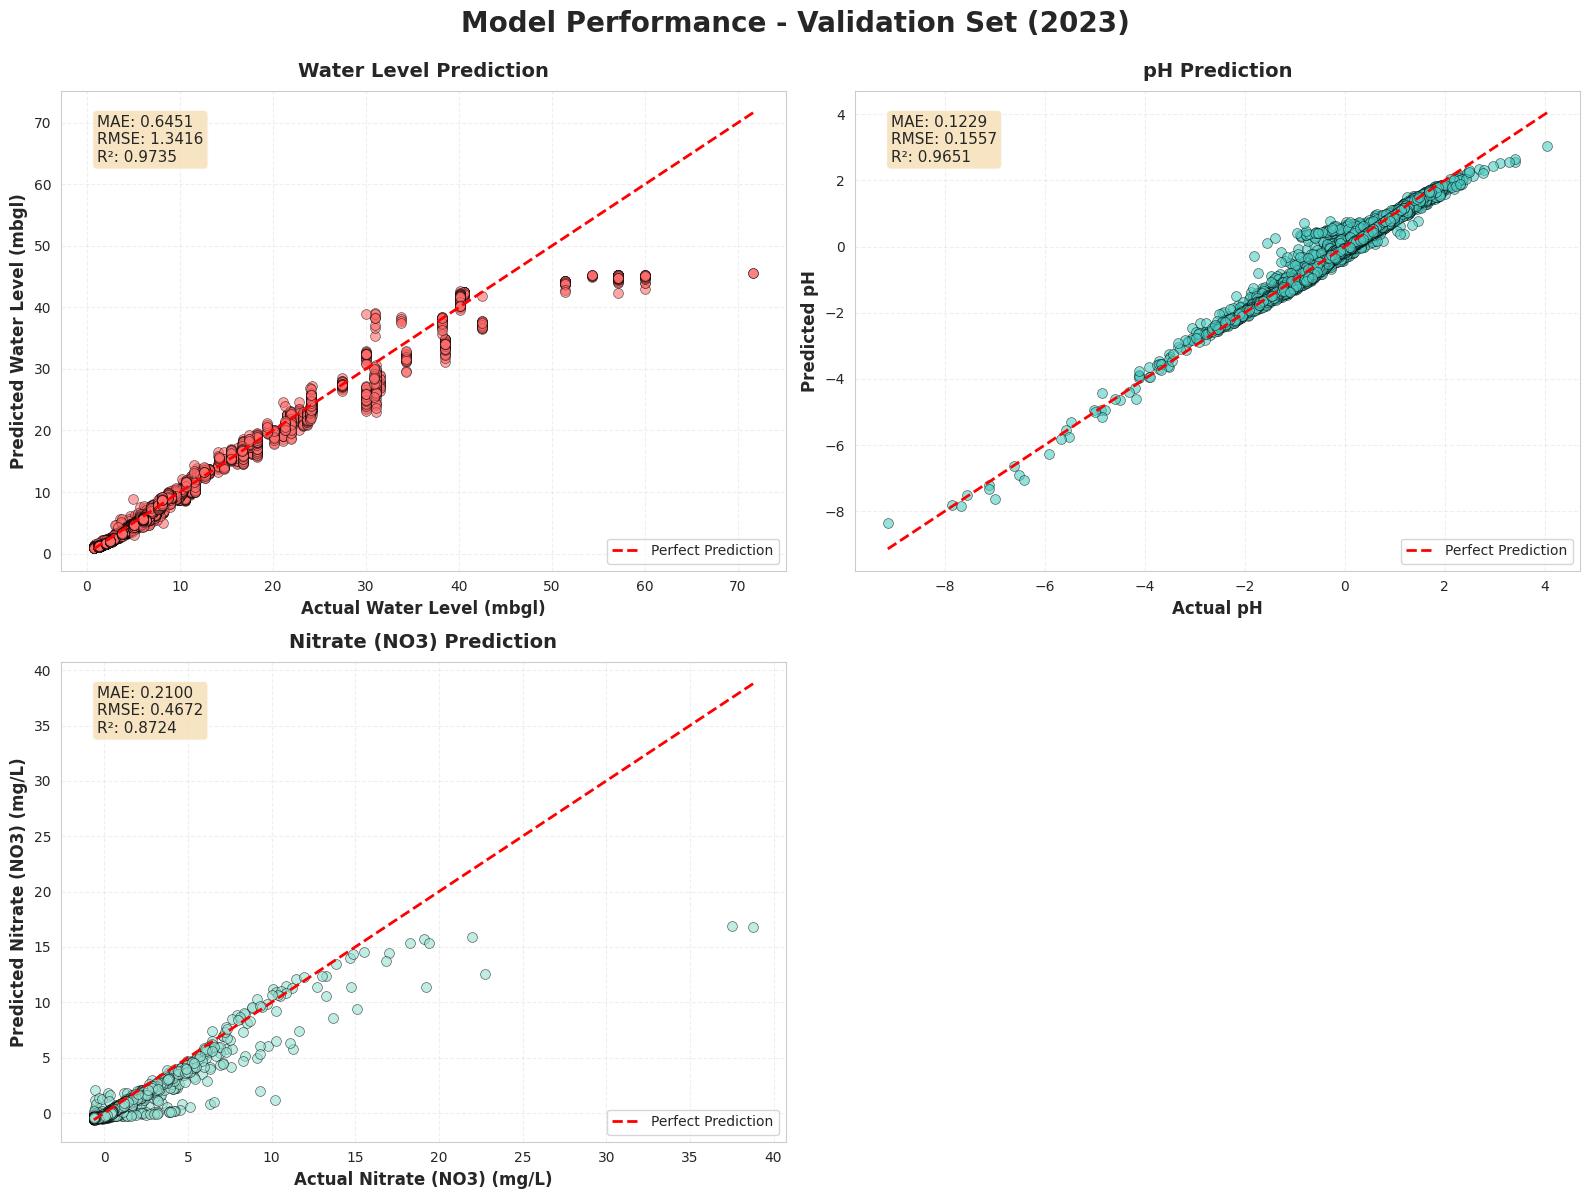


10. CREATING TIME SERIES PLOTS...
  - Saved: time_series_comparison_no_tds.png


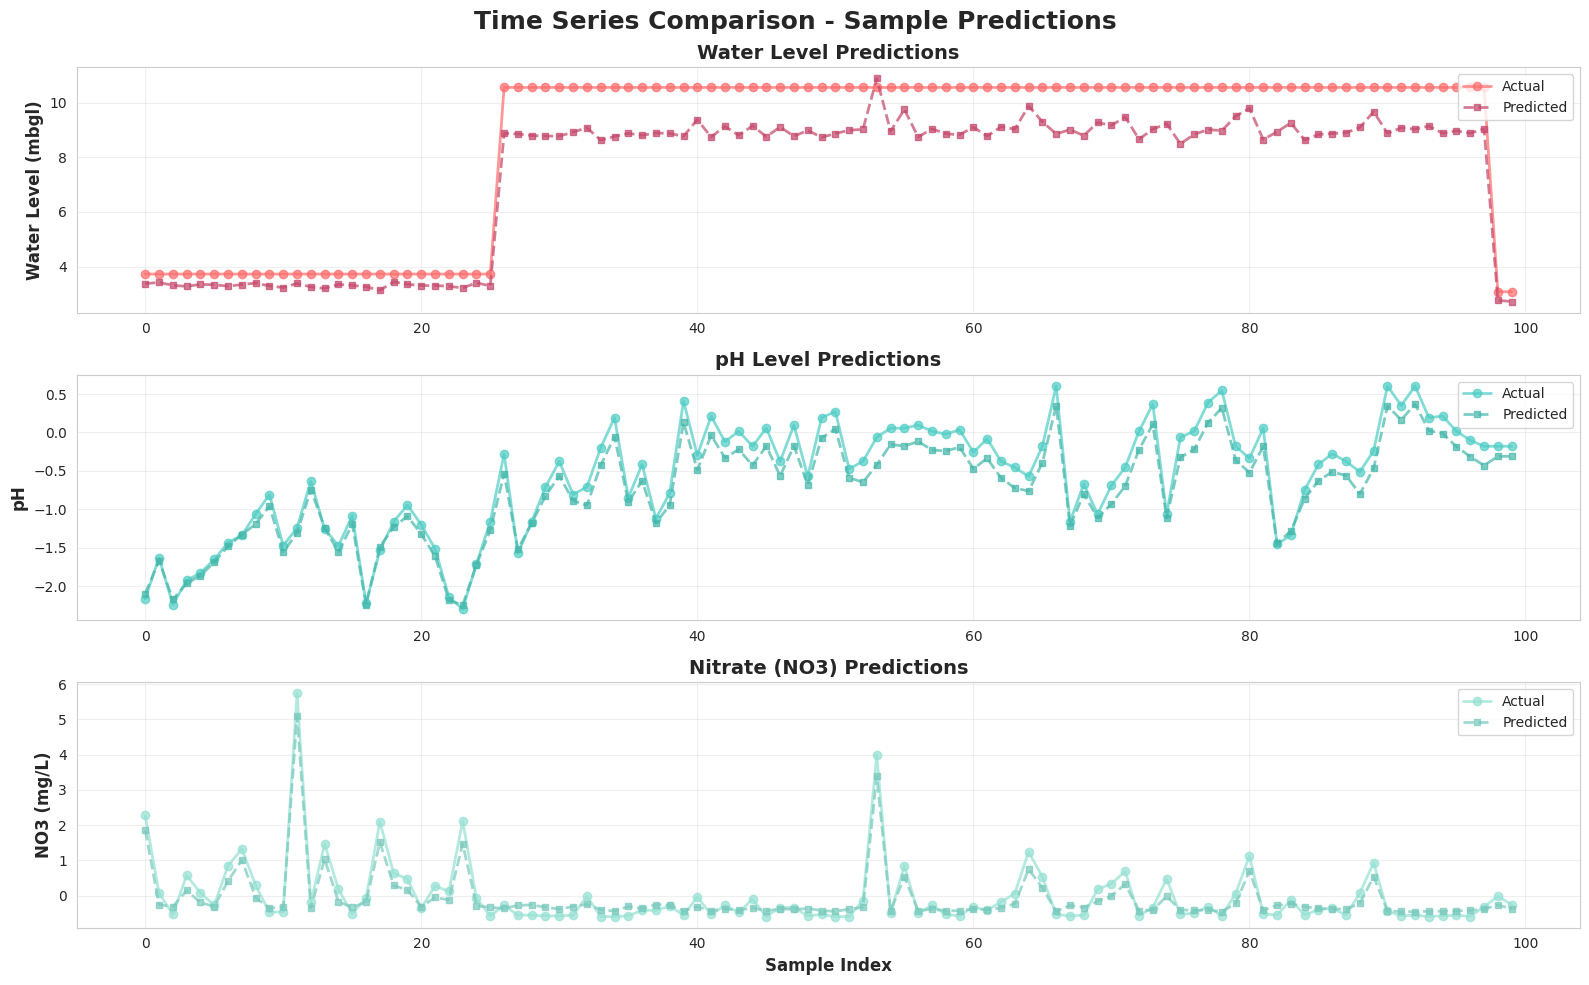


11. CREATING RESIDUAL PLOTS...
  - Saved: residual_plots_no_tds.png


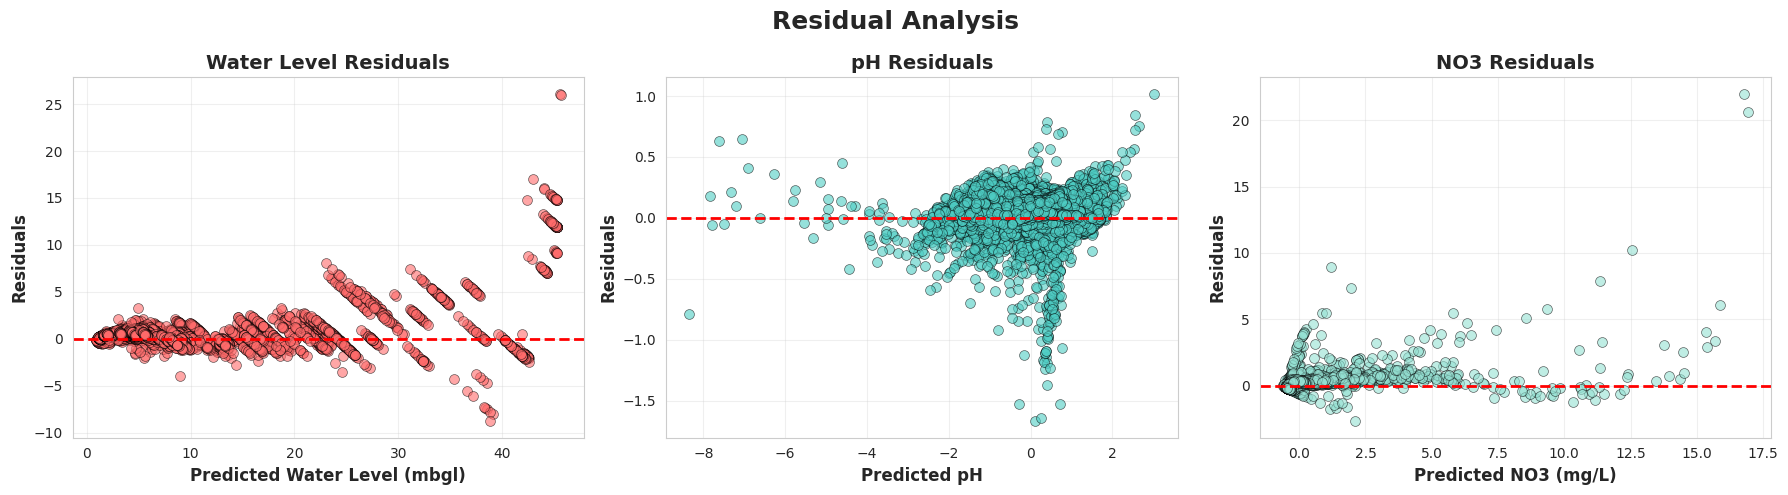


12. CREATING DISTRIBUTION PLOTS...
  - Saved: error_distribution_no_tds.png


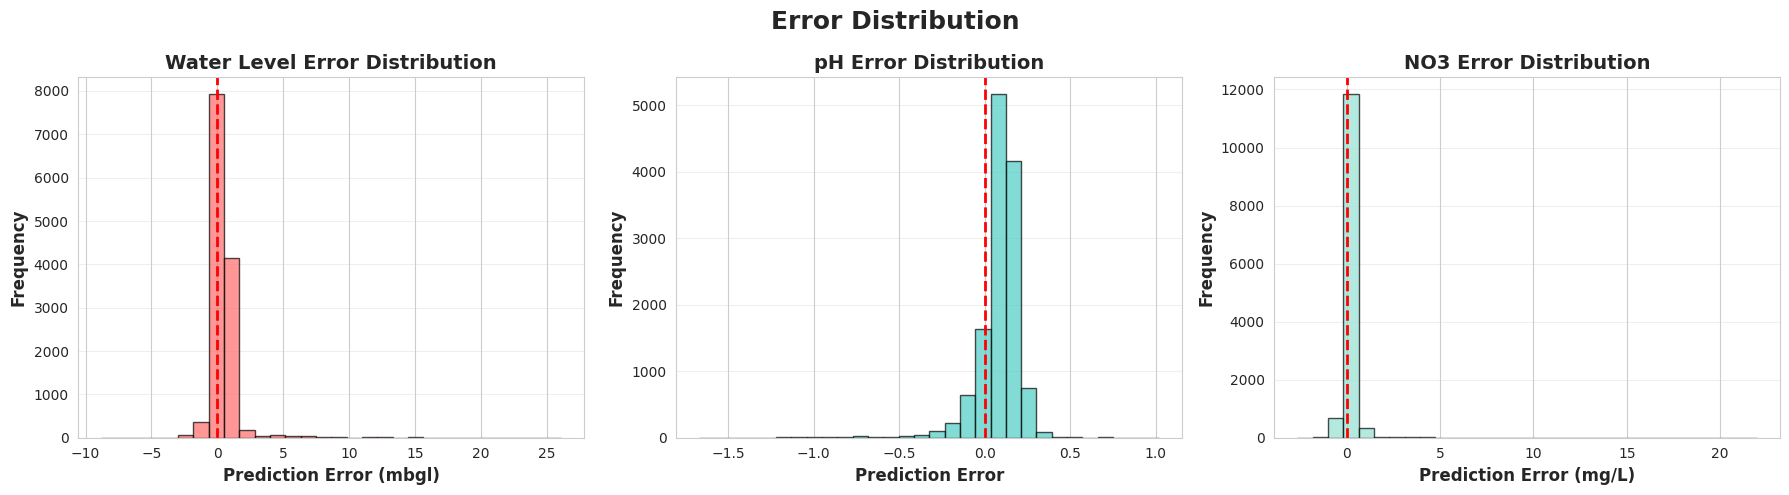


VISUALIZATION COMPLETE!


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# 9. VISUALIZATION (IGNORING TDS)
# ============================================================================
print("\n9. CREATING VISUALIZATIONS...")

# Create figure with subplots (3 plots: WL, pH, NO3)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance - Validation Set (2023)', fontsize=20, fontweight='bold', y=0.995)

# Flatten axes for easier indexing
axes = axes.flatten()

# Define parameters to plot (excluding TDS)
params = [
    ('Water Level', wl_val_actual, wl_pred_val, 'mbgl', axes[0]),
    ('pH', wq_val_actual[:, 0], wq_pred_val[:, 0], '', axes[1]),
    ('Nitrate (NO3)', wq_val_actual[:, 2], wq_pred_val[:, 2], 'mg/L', axes[2])
]

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']

for idx, (name, actual, pred, unit, ax) in enumerate(params):
    # Flatten arrays if needed
    actual_flat = actual.flatten()
    pred_flat = pred.flatten()
    
    # Scatter plot
    ax.scatter(actual_flat, pred_flat, alpha=0.6, s=50, color=colors[idx], edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(actual_flat.min(), pred_flat.min())
    max_val = max(actual_flat.max(), pred_flat.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Calculate metrics
    mae = mean_absolute_error(actual_flat, pred_flat)
    rmse = np.sqrt(mean_squared_error(actual_flat, pred_flat))
    r2 = r2_score(actual_flat, pred_flat)
    
    # Add metrics text box
    textstr = f'MAE: {mae:.4f}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)
    
    # Labels and title
    ax.set_xlabel(f'Actual {name} ({unit})' if unit else f'Actual {name}', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Predicted {name} ({unit})' if unit else f'Predicted {name}', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} Prediction', fontsize=14, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

# Remove the 4th subplot (bottom right)
fig.delaxes(axes[3])

plt.tight_layout()
plt.savefig('model_performance_no_tds.png', dpi=300, bbox_inches='tight')
print("  - Saved: model_performance_no_tds.png")
plt.show()

# ============================================================================
# 10. TIME SERIES COMPARISON PLOT
# ============================================================================
print("\n10. CREATING TIME SERIES PLOTS...")

# Create sample visualizations for first 100 predictions
sample_size = min(100, len(wl_val_actual))
sample_indices = np.arange(sample_size)

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle('Time Series Comparison - Sample Predictions', fontsize=18, fontweight='bold')

# Plot 1: Water Level
axes[0].plot(sample_indices, wl_val_actual[:sample_size], 'o-', label='Actual', 
             color='#FF6B6B', linewidth=2, markersize=6, alpha=0.7)
axes[0].plot(sample_indices, wl_pred_val[:sample_size], 's--', label='Predicted', 
             color='#C44569', linewidth=2, markersize=5, alpha=0.7)
axes[0].set_ylabel('Water Level (mbgl)', fontsize=12, fontweight='bold')
axes[0].set_title('Water Level Predictions', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: pH
axes[1].plot(sample_indices, wq_val_actual[:sample_size, 0], 'o-', label='Actual', 
             color='#4ECDC4', linewidth=2, markersize=6, alpha=0.7)
axes[1].plot(sample_indices, wq_pred_val[:sample_size, 0], 's--', label='Predicted', 
             color='#45B7AA', linewidth=2, markersize=5, alpha=0.7)
axes[1].set_ylabel('pH', fontsize=12, fontweight='bold')
axes[1].set_title('pH Level Predictions', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

# Plot 3: NO3
axes[2].plot(sample_indices, wq_val_actual[:sample_size, 2], 'o-', label='Actual', 
             color='#95E1D3', linewidth=2, markersize=6, alpha=0.7)
axes[2].plot(sample_indices, wq_pred_val[:sample_size, 2], 's--', label='Predicted', 
             color='#78C9BC', linewidth=2, markersize=5, alpha=0.7)
axes[2].set_xlabel('Sample Index', fontsize=12, fontweight='bold')
axes[2].set_ylabel('NO3 (mg/L)', fontsize=12, fontweight='bold')
axes[2].set_title('Nitrate (NO3) Predictions', fontsize=14, fontweight='bold')
axes[2].legend(loc='upper right', fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_comparison_no_tds.png', dpi=300, bbox_inches='tight')
print("  - Saved: time_series_comparison_no_tds.png")
plt.show()

# ============================================================================
# 11. RESIDUAL PLOTS
# ============================================================================
print("\n11. CREATING RESIDUAL PLOTS...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Residual Analysis', fontsize=18, fontweight='bold')

# Water Level Residuals
wl_residuals = wl_val_actual.flatten() - wl_pred_val.flatten()
axes[0].scatter(wl_pred_val, wl_residuals, alpha=0.6, s=50, color='#FF6B6B', edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Water Level (mbgl)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[0].set_title('Water Level Residuals', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# pH Residuals
ph_residuals = wq_val_actual[:, 0] - wq_pred_val[:, 0]
axes[1].scatter(wq_pred_val[:, 0], ph_residuals, alpha=0.6, s=50, color='#4ECDC4', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted pH', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[1].set_title('pH Residuals', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# NO3 Residuals
no3_residuals = wq_val_actual[:, 2] - wq_pred_val[:, 2]
axes[2].scatter(wq_pred_val[:, 2], no3_residuals, alpha=0.6, s=50, color='#95E1D3', edgecolors='black', linewidth=0.5)
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted NO3 (mg/L)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[2].set_title('NO3 Residuals', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_plots_no_tds.png', dpi=300, bbox_inches='tight')
print("  - Saved: residual_plots_no_tds.png")
plt.show()

# ============================================================================
# 12. DISTRIBUTION PLOTS
# ============================================================================
print("\n12. CREATING DISTRIBUTION PLOTS...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Error Distribution', fontsize=18, fontweight='bold')

# Water Level Error Distribution
axes[0].hist(wl_residuals, bins=30, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Prediction Error (mbgl)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Water Level Error Distribution', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# pH Error Distribution
axes[1].hist(ph_residuals, bins=30, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('pH Error Distribution', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# NO3 Error Distribution
axes[2].hist(no3_residuals, bins=30, color='#95E1D3', alpha=0.7, edgecolor='black')
axes[2].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Prediction Error (mg/L)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[2].set_title('NO3 Error Distribution', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('error_distribution_no_tds.png', dpi=300, bbox_inches='tight')
print("  - Saved: error_distribution_no_tds.png")
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE!")
print("="*80)

In [19]:
!zip -r ground_water.zip /kaggle/working/

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/tft_model.pth (deflated 9%)
  adding: kaggle/working/config.pkl (deflated 55%)
  adding: kaggle/working/improved_config.pkl (deflated 50%)
  adding: kaggle/working/time_series_comparison.png (deflated 24%)
  adding: kaggle/working/model_wl.pth (deflated 9%)
  adding: kaggle/working/improved_tft_model.pth (deflated 8%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/states_districts.csv (deflated 69%)
  adding: kaggle/working/model_wq.pth (deflated 10%)
  adding: kaggle/working/validation_results.png (deflated 7%)


In [22]:
from IPython.display import FileLink
FileLink(r'ground_water.zip')

/kaggle/working/ground_water.zip

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("DATA LOADING AND PREPROCESSING")
print("="*80)

# ============================================================================
# 1. LOAD WATER LEVEL DATA
# ============================================================================
print("\n1. LOADING WATER LEVEL DATA...")

wl_raw = pd.read_csv('output_merged_cleaned.csv')
print(f"Raw water level records: {len(wl_raw)}")

# Parse dates
wl_raw['Date'] = pd.to_datetime(wl_raw['Date'], format='%d-%m-%y', errors='coerce')
wl_raw['Year'] = wl_raw['Date'].dt.year
wl_raw['Month'] = wl_raw['Date'].dt.month

# Filter for 2019-2023 and August data
wl_filtered = wl_raw[
    (wl_raw['Year'] >= 2019) & 
    (wl_raw['Year'] <= 2023) &
    (wl_raw['Month'] == 8)
].copy()

print(f"Filtered water level records (Aug 2019-2023): {len(wl_filtered)}")

# Clean column names
wl_filtered.rename(columns={'STATE_UT': 'STATE'}, inplace=True)

# Drop rows with missing essential data
wl_filtered = wl_filtered.dropna(subset=['STATE', 'DISTRICT', 'WL(mbgl)', 'Year'])

# Aggregate to yearly average per STATE-DISTRICT pair
wl_yearly = wl_filtered.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'WL(mbgl)': 'mean',
    'LATITUDE': 'first',
    'LONGITUDE': 'first'
}).reset_index()

print(f"Yearly aggregated water level records: {len(wl_yearly)}")
print(f"Unique STATE-DISTRICT pairs: {wl_yearly.groupby(['STATE', 'DISTRICT']).size().shape[0]}")
print(f"Years available: {sorted(wl_yearly['Year'].unique())}")

# Check distribution of records per location
records_per_location = wl_yearly.groupby(['STATE', 'DISTRICT']).size()
print(f"\nRecords per STATE-DISTRICT pair:")
print(f"  Min: {records_per_location.min()}")
print(f"  Max: {records_per_location.max()}")
print(f"  Mean: {records_per_location.mean():.2f}")
print(f"  Locations with 5 years: {(records_per_location == 5).sum()}")

# ============================================================================
# 2. LOAD WATER QUALITY DATA
# ============================================================================
print("\n2. LOADING WATER QUALITY DATA...")

# Load 2019 data
print("  Loading 2019...")
df_2019 = pd.read_excel('16860545111615830419file.xlsx')
df_2019['Year'] = 2019

# Load 2020 data
print("  Loading 2020...")
df_2020 = pd.read_excel('16860552951664994501file.xlsx')
df_2020['Year'] = 2020

# Load 2021 data (3 sheets)
print("  Loading 2021...")
df_2021_t1 = pd.read_excel('1686055122486176238file.xlsx', sheet_name='Table 1')
df_2021_t2 = pd.read_excel('1686055122486176238file.xlsx', sheet_name='Table 2')
df_2021_t3 = pd.read_excel('1686055122486176238file.xlsx', sheet_name='Table 3')

# Take only first 26 columns and concatenate
df_2021 = pd.concat([
    df_2021_t1.iloc[:, :26],
    df_2021_t2.iloc[:, :26],
    df_2021_t3.iloc[:, :26]
], ignore_index=True)
df_2021['Year'] = 2021

# Load 2022 data
print("  Loading 2022...")
df_2022 = pd.read_excel('final_nhs-wq_pre_2022_compressed.xlsx')
df_2022['Year'] = 2022

# Load 2023 data
print("  Loading 2023...")
df_2023 = pd.read_excel('final_nhs-wq_pre_2023_compressed.xlsx')
df_2023['Year'] = 2023

# Standardize column names
for df in [df_2019, df_2020, df_2022]:
    if 'State' in df.columns:
        df['STATE'] = df['State']
    if 'District' in df.columns:
        df['DISTRICT'] = df['District']

df_2023.rename(columns={'State': 'STATE', 'District': 'DISTRICT'}, inplace=True)

print(f"  2019: {len(df_2019)} records")
print(f"  2020: {len(df_2020)} records")
print(f"  2021: {len(df_2021)} records")
print(f"  2022: {len(df_2022)} records")
print(f"  2023: {len(df_2023)} records")

# ============================================================================
# 3. COMBINE AND CLEAN WATER QUALITY DATA
# ============================================================================
print("\n3. COMBINING WATER QUALITY DATA...")

wq_all = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023], ignore_index=True)
print(f"Total water quality records: {len(wq_all)}")

# Keep only necessary columns
essential_cols = ['STATE', 'DISTRICT', 'Year', 'pH', 'TDS', 'NO3']
available_cols = [col for col in essential_cols if col in wq_all.columns]
wq_clean = wq_all[available_cols].copy()

# Filter for 2019-2023
wq_clean = wq_clean[wq_clean['Year'].notna()]
wq_clean['Year'] = pd.to_numeric(wq_clean['Year'], errors='coerce')
wq_clean = wq_clean[wq_clean['Year'].notna()]
wq_clean['Year'] = wq_clean['Year'].astype(int)
wq_clean = wq_clean[(wq_clean['Year'] >= 2019) & (wq_clean['Year'] <= 2023)]

# Drop rows with missing STATE, DISTRICT, or Year
wq_clean = wq_clean.dropna(subset=['STATE', 'DISTRICT', 'Year'])

# Convert water quality parameters to numeric
for col in ['pH', 'TDS', 'NO3']:
    if col in wq_clean.columns:
        wq_clean[col] = pd.to_numeric(wq_clean[col], errors='coerce')

print(f"Cleaned water quality records: {len(wq_clean)}")
print(f"Years available: {sorted(wq_clean['Year'].unique())}")

# Aggregate to yearly average per STATE-DISTRICT pair
wq_yearly = wq_clean.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'pH': 'mean',
    'TDS': 'mean',
    'NO3': 'mean'
}).reset_index()

print(f"Yearly aggregated water quality records: {len(wq_yearly)}")
print(f"Unique STATE-DISTRICT pairs: {wq_yearly.groupby(['STATE', 'DISTRICT']).size().shape[0]}")

# Check distribution of records per location
wq_records_per_location = wq_yearly.groupby(['STATE', 'DISTRICT']).size()
print(f"\nRecords per STATE-DISTRICT pair:")
print(f"  Min: {wq_records_per_location.min()}")
print(f"  Max: {wq_records_per_location.max()}")
print(f"  Mean: {wq_records_per_location.mean():.2f}")
print(f"  Locations with 5 years: {(wq_records_per_location == 5).sum()}")

# ============================================================================
# 4. SAVE PROCESSED DATA
# ============================================================================
print("\n4. SAVING PROCESSED DATA...")

# Save water level data
wl_yearly.to_csv('water_level_yearly.csv', index=False)
print(f"  Saved: water_level_yearly.csv ({len(wl_yearly)} records)")

# Save water quality data
wq_yearly.to_csv('water_quality_yearly.csv', index=False)
print(f"  Saved: water_quality_yearly.csv ({len(wq_yearly)} records)")

# ============================================================================
# 5. DATA SUMMARY
# ============================================================================
print("\n" + "="*80)
print("DATA SUMMARY")
print("="*80)

print("\nWATER LEVEL DATA:")
print(f"  Total records: {len(wl_yearly)}")
print(f"  Years: {sorted(wl_yearly['Year'].unique())}")
print(f"  States: {wl_yearly['STATE'].nunique()}")
print(f"  Districts: {wl_yearly['DISTRICT'].nunique()}")
print(f"  STATE-DISTRICT pairs: {wl_yearly.groupby(['STATE', 'DISTRICT']).ngroups}")
print(f"\nSample data:")
print(wl_yearly.head(10))
print(f"\nStatistics:")
print(wl_yearly[['WL(mbgl)', 'LATITUDE', 'LONGITUDE']].describe())

print("\n" + "-"*80)
print("\nWATER QUALITY DATA:")
print(f"  Total records: {len(wq_yearly)}")
print(f"  Years: {sorted(wq_yearly['Year'].unique())}")
print(f"  States: {wq_yearly['STATE'].nunique()}")
print(f"  Districts: {wq_yearly['DISTRICT'].nunique()}")
print(f"  STATE-DISTRICT pairs: {wq_yearly.groupby(['STATE', 'DISTRICT']).ngroups}")
print(f"\nSample data:")
print(wq_yearly.head(10))
print(f"\nStatistics:")
print(wq_yearly[['pH', 'TDS', 'NO3']].describe())

# Check for common STATE-DISTRICT pairs
common_pairs = set(zip(wl_yearly['STATE'], wl_yearly['DISTRICT'])) & \
               set(zip(wq_yearly['STATE'], wq_yearly['DISTRICT']))
print(f"\nCommon STATE-DISTRICT pairs in both datasets: {len(common_pairs)}")

print("\n" + "="*80)
print("DATA LOADING COMPLETE!")
print("="*80)

DATA LOADING AND PREPROCESSING

1. LOADING WATER LEVEL DATA...


FileNotFoundError: [Errno 2] No such file or directory: 'output_merged_cleaned.csv'

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("WATER LEVEL DATA PROCESSING - YEARLY AGGREGATION")
print("="*80)

# ============================================================================
# 1. LOAD WATER LEVEL DATA
# ============================================================================
print("\n1. LOADING WATER LEVEL DATA...")

# Load the CSV file
wl_raw = pd.read_csv('/kaggle/input/203-ground-water-data/output_merged_cleaned.csv')
print(f"Raw water level records: {len(wl_raw)}")
print(f"Columns: {list(wl_raw.columns)}")

# ============================================================================
# 2. PARSE AND FILTER DATA
# ============================================================================
print("\n2. PARSING DATES AND FILTERING...")

# Parse dates
wl_raw['Date'] = pd.to_datetime(wl_raw['Date'], format='%d-%m-%y', errors='coerce')
wl_raw['Year'] = wl_raw['Date'].dt.year
wl_raw['Month'] = wl_raw['Date'].dt.month

print(f"Date range: {wl_raw['Date'].min()} to {wl_raw['Date'].max()}")
print(f"Years available: {sorted(wl_raw['Year'].dropna().unique())}")
print(f"Months available: {sorted(wl_raw['Month'].dropna().unique())}")

# Filter for 2019-2023
wl_filtered = wl_raw[
    (wl_raw['Year'] >= 2019) & 
    (wl_raw['Year'] <= 2023)
].copy()

print(f"\nFiltered records (2019-2023): {len(wl_filtered)}")
print(f"Years after filtering: {sorted(wl_filtered['Year'].unique())}")

# ============================================================================
# 3. CLEAN COLUMN NAMES
# ============================================================================
print("\n3. CLEANING DATA...")

# Rename STATE_UT to STATE if it exists
if 'STATE_UT' in wl_filtered.columns:
    wl_filtered.rename(columns={'STATE_UT': 'STATE'}, inplace=True)
    print("Renamed 'STATE_UT' to 'STATE'")

# Check for essential columns
essential_cols = ['STATE', 'DISTRICT', 'WL(mbgl)', 'Year']
missing_cols = [col for col in essential_cols if col not in wl_filtered.columns]

if missing_cols:
    print(f"WARNING: Missing columns: {missing_cols}")
    print(f"Available columns: {list(wl_filtered.columns)}")
else:
    print(f"All essential columns present: {essential_cols}")

# Drop rows with missing essential data
before_drop = len(wl_filtered)
wl_filtered = wl_filtered.dropna(subset=['STATE', 'DISTRICT', 'WL(mbgl)', 'Year'])
print(f"Dropped {before_drop - len(wl_filtered)} rows with missing data")

# ============================================================================
# 4. AGGREGATE TO YEARLY DATA
# ============================================================================
print("\n4. AGGREGATING TO YEARLY AVERAGES...")

# Aggregate to yearly average per STATE-DISTRICT pair
agg_dict = {'WL(mbgl)': 'mean'}

# Add LATITUDE and LONGITUDE if available
if 'LATITUDE' in wl_filtered.columns:
    agg_dict['LATITUDE'] = 'first'
if 'LONGITUDE' in wl_filtered.columns:
    agg_dict['LONGITUDE'] = 'first'

wl_yearly = wl_filtered.groupby(['STATE', 'DISTRICT', 'Year']).agg(agg_dict).reset_index()

print(f"Yearly aggregated records: {len(wl_yearly)}")
print(f"Unique STATE-DISTRICT pairs: {wl_yearly.groupby(['STATE', 'DISTRICT']).ngroups}")
print(f"Years: {sorted(wl_yearly['Year'].unique())}")

# ============================================================================
# 5. CHECK DATA DISTRIBUTION
# ============================================================================
print("\n5. DATA DISTRIBUTION ANALYSIS...")

# Count records per STATE-DISTRICT pair
records_per_location = wl_yearly.groupby(['STATE', 'DISTRICT']).size()

print(f"\nRecords per STATE-DISTRICT pair:")
print(f"  Min: {records_per_location.min()}")
print(f"  Max: {records_per_location.max()}")
print(f"  Mean: {records_per_location.mean():.2f}")
print(f"  Median: {records_per_location.median():.0f}")

# Count how many locations have each number of years
for i in range(1, 6):
    count = (records_per_location == i).sum()
    print(f"  Locations with {i} year(s): {count}")

# Show top 10 states by number of districts
print("\nTop 10 States by number of districts:")
state_counts = wl_yearly.groupby('STATE')['DISTRICT'].nunique().sort_values(ascending=False)
print(state_counts.head(10))

# ============================================================================
# 6. DISPLAY SAMPLE DATA
# ============================================================================
print("\n6. SAMPLE DATA:")
print(wl_yearly.head(15))

print("\n" + "="*80)
print("STATISTICS:")
print("="*80)
print(wl_yearly.describe())

# ============================================================================
# 7. SAVE PROCESSED DATA
# ============================================================================
print("\n7. SAVING PROCESSED DATA...")

wl_yearly.to_csv('water_level_yearly.csv', index=False)
print(f"Saved: water_level_yearly.csv ({len(wl_yearly)} records)")

# Also create a summary of locations with complete 5-year data
complete_locations = wl_yearly.groupby(['STATE', 'DISTRICT']).size()
complete_locations = complete_locations[complete_locations == 5].reset_index()
complete_locations.columns = ['STATE', 'DISTRICT', 'YEAR_COUNT']

print(f"\nLocations with complete 5-year data: {len(complete_locations)}")
complete_locations.to_csv('complete_locations.csv', index=False)
print(f"Saved: complete_locations.csv")

print("\n" + "="*80)
print("WATER LEVEL DATA PROCESSING COMPLETE!")
print("="*80)

WATER LEVEL DATA PROCESSING - YEARLY AGGREGATION

1. LOADING WATER LEVEL DATA...
Raw water level records: 363059
Columns: ['STATE_UT', 'DISTRICT', 'BLOCK', 'VILLAGE_NA', 'LATITUDE', 'LONGITUDE', 'Date', 'WL(mbgl)']

2. PARSING DATES AND FILTERING...
Date range: 1994-08-01 00:00:00 to 2023-08-31 00:00:00
Years available: [1994.0, 1995.0, 1996.0, 1997.0, 1998.0, 1999.0, 2000.0, 2001.0, 2002.0, 2003.0, 2004.0, 2005.0, 2006.0, 2007.0, 2008.0, 2009.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0]
Months available: [8.0]

Filtered records (2019-2023): 71813
Years after filtering: [2019.0, 2020.0, 2021.0, 2022.0, 2023.0]

3. CLEANING DATA...
Renamed 'STATE_UT' to 'STATE'
All essential columns present: ['STATE', 'DISTRICT', 'WL(mbgl)', 'Year']
Dropped 1260 rows with missing data

4. AGGREGATING TO YEARLY AVERAGES...
Yearly aggregated records: 3088
Unique STATE-DISTRICT pairs: 681
Years: [2019.0, 2020.0, 2021.0, 2022.0, 2023.0]



In [3]:
df_2019 = pd.read_excel('/kaggle/input/203-ground-water-data/16860545111615830419file.xlsx')
print("2019 columns:", list(df_2019.columns))

# Check 2020 columns
df_2020 = pd.read_excel('/kaggle/input/203-ground-water-data/16860552951664994501file.xlsx')
print("\n2020 columns:", list(df_2020.columns))

# Check 2021 columns (Table 1)
df_2021 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 1')
print("\n2021 columns:", list(df_2021.columns))

# Check 2022 columns
df_2022 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2022_compressed.xlsx')
print("\n2022 columns:", list(df_2022.columns))

# Check 2023 columns
df_2023 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2023_compressed.xlsx')
print("\n2023 columns:", list(df_2023.columns))

2019 columns: ['Well_ID', 'S. No.', 'State', 'District', 'Block', 'Village', 'Latitude', 'Longitude', 'Year', 'pH', 'EC in μS/cm', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'PO4', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'SiO2']

2020 columns: ['Well_ID', 'S.No', 'State', 'District', 'Taluka', 'Site', 'Latitude', 'Longitude', 'Year', 'pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'PO4', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS', 'SiO2']

2021 columns: ['Well ID', 'S.No', 'STATE', 'DISTRICT', 'BLOCK', 'LOCATION', 'LATITUDE', 'LONGITUDE', 'Year', 'pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'PO4', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'SiO2', 'TDS', 'U(ppb)']

2022 columns: ['Sl_No', 'GEMS_ID\xa0\xa0\xa0\xa0W', 'STATE', 'DISTRICT', 'BLOCK', 'LOCATION', 'LONGITUDE', 'LATITUDE', 'Year', 'pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'PO4', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'SiO2', 'TDS', 'U_ppb_']

2023 columns: ['S. No.', 'State', 'District', 'Location', 'Longitude', 'Latitude', 'Year', 'pH', 'EC (µ

In [4]:
print("="*80)
print("WATER QUALITY DATA PROCESSING")
print("="*80)

# Load water level yearly data to get STATE-DISTRICT pairs
wl_yearly = pd.read_csv('water_level_yearly.csv')
wl_pairs = set(zip(wl_yearly['STATE'], wl_yearly['DISTRICT']))
print(f"Water Level STATE-DISTRICT pairs: {len(wl_pairs)}")

# Load 2019
df_2019 = pd.read_excel('/kaggle/input/203-ground-water-data/16860545111615830419file.xlsx')
df_2019 = df_2019.rename(columns={'State': 'STATE', 'District': 'DISTRICT'})
df_2019 = df_2019[['STATE', 'DISTRICT', 'Year', 'pH', 'NO3']]

# Load 2020
df_2020 = pd.read_excel('/kaggle/input/203-ground-water-data/16860552951664994501file.xlsx')
df_2020 = df_2020.rename(columns={'State': 'STATE', 'District': 'DISTRICT'})
df_2020 = df_2020[['STATE', 'DISTRICT', 'Year', 'pH', 'NO3']]

# Load 2021 (3 sheets)
df_2021_t1 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 1')
df_2021_t2 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 2')
df_2021_t3 = pd.read_excel('/kaggle/input/203-ground-water-data/1686055122486176238file.xlsx', sheet_name='Table 3')
df_2021 = pd.concat([df_2021_t1, df_2021_t2, df_2021_t3], ignore_index=True)
df_2021 = df_2021[['STATE', 'DISTRICT', 'Year', 'pH', 'NO3']]

# Load 2022
df_2022 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2022_compressed.xlsx')
df_2022 = df_2022[['STATE', 'DISTRICT', 'Year', 'pH', 'NO3']]

# Load 2023
df_2023 = pd.read_excel('/kaggle/input/203-ground-water-data/final_nhs-wq_pre_2023_compressed.xlsx')
df_2023 = df_2023.rename(columns={'State': 'STATE', 'District': 'DISTRICT'})
df_2023 = df_2023[['STATE', 'DISTRICT', 'Year', 'pH', 'NO3']]

# Combine all
wq_all = pd.concat([df_2019, df_2020, df_2021, df_2022, df_2023], ignore_index=True)
wq_all['Year'] = pd.to_numeric(wq_all['Year'], errors='coerce')
wq_all = wq_all[(wq_all['Year'] >= 2019) & (wq_all['Year'] <= 2023)]
wq_all = wq_all.dropna(subset=['STATE', 'DISTRICT', 'Year'])

print(f"Total water quality records: {len(wq_all)}")

# Convert pH and NO3 to numeric
wq_all['pH'] = pd.to_numeric(wq_all['pH'], errors='coerce')
wq_all['NO3'] = pd.to_numeric(wq_all['NO3'], errors='coerce')

# Aggregate to yearly average per STATE-DISTRICT
wq_yearly = wq_all.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'pH': 'mean',
    'NO3': 'mean'
}).reset_index()

print(f"Water Quality yearly records: {len(wq_yearly)}")
print(f"WQ STATE-DISTRICT pairs: {wq_yearly.groupby(['STATE', 'DISTRICT']).ngroups}")

# Filter for STATE-DISTRICT pairs that exist in water level data
wq_yearly['pair'] = list(zip(wq_yearly['STATE'], wq_yearly['DISTRICT']))
wq_matched = wq_yearly[wq_yearly['pair'].isin(wl_pairs)].drop(columns=['pair'])

print(f"\nMatched records (STATE-DISTRICT in water level): {len(wq_matched)}")
print(f"Matched STATE-DISTRICT pairs: {wq_matched.groupby(['STATE', 'DISTRICT']).ngroups}")

# Check remaining STATE-DISTRICT pairs
wq_yearly['pair'] = list(zip(wq_yearly['STATE'], wq_yearly['DISTRICT']))
wq_remaining = wq_yearly[~wq_yearly['pair'].isin(wl_pairs)].drop(columns=['pair'])

print(f"\nRemaining WQ records (not in water level): {len(wq_remaining)}")
print(f"Remaining STATE-DISTRICT pairs: {wq_remaining.groupby(['STATE', 'DISTRICT']).ngroups}")

# Combine matched + remaining
wq_final = pd.concat([wq_matched, wq_remaining], ignore_index=True)

print(f"\nFinal water quality records: {len(wq_final)}")
print(f"Years: {sorted(wq_final['Year'].unique())}")

# Check distribution
records_per_location = wq_final.groupby(['STATE', 'DISTRICT']).size()
print(f"\nRecords per STATE-DISTRICT:")
for i in range(1, 6):
    print(f"  {i} year(s): {(records_per_location == i).sum()}")

# Save
wq_final.to_csv('water_quality_yearly.csv', index=False)
print(f"\nSaved: water_quality_yearly.csv")
print("\nSample data:")
print(wq_final.head(15))

WATER QUALITY DATA PROCESSING
Water Level STATE-DISTRICT pairs: 681
Total water quality records: 56234
Water Quality yearly records: 2653
WQ STATE-DISTRICT pairs: 1595

Matched records (STATE-DISTRICT in water level): 1333
Matched STATE-DISTRICT pairs: 541

Remaining WQ records (not in water level): 1320
Remaining STATE-DISTRICT pairs: 1054

Final water quality records: 2653
Years: [2019.0, 2020.0, 2021.0, 2022.0, 2023.0]

Records per STATE-DISTRICT:
  1 year(s): 1023
  2 year(s): 306
  3 year(s): 120
  4 year(s): 72
  5 year(s): 74

Saved: water_quality_yearly.csv

Sample data:
             STATE       DISTRICT    Year        pH         NO3
0   Andhra Pradesh     Anakapalli  2023.0  7.029259   64.851852
1   Andhra Pradesh      Annamayya  2023.0  7.654795   18.452055
2   Andhra Pradesh        Bapatla  2023.0  7.468788   14.333333
3   Andhra Pradesh       Chittoor  2023.0  7.607705   14.836066
4   Andhra Pradesh  East Godavari  2022.0  7.649231   53.061538
5   Andhra Pradesh  East Godav

In [6]:
wl_yearly = pd.read_csv('water_level_yearly.csv')
wq_yearly = pd.read_csv('water_quality_yearly.csv')

print("="*80)
print("UNIQUE STATES AND DISTRICTS ANALYSIS")
print("="*80)

# Water Level unique states
wl_states = sorted(wl_yearly['STATE'].unique())
print(f"\n1. WATER LEVEL - Unique States: {len(wl_states)}")
print(wl_states)

# Water Quality unique states
wq_states = sorted(wq_yearly['STATE'].unique())
print(f"\n2. WATER QUALITY - Unique States: {len(wq_states)}")
print(wq_states)

# Common states
common_states = sorted(set(wl_states) & set(wq_states))
print(f"\n3. COMMON States (in both): {len(common_states)}")
print(common_states)

# States only in water level
wl_only = sorted(set(wl_states) - set(wq_states))
print(f"\n4. States ONLY in Water Level: {len(wl_only)}")
print(wl_only)

# States only in water quality
wq_only = sorted(set(wq_states) - set(wl_states))
print(f"\n5. States ONLY in Water Quality: {len(wq_only)}")
print(wq_only)

print("\n" + "="*80)
print("STATE-DISTRICT PAIRS ANALYSIS")
print("="*80)

# Get STATE-DISTRICT pairs
wl_pairs = set(zip(wl_yearly['STATE'], wl_yearly['DISTRICT']))
wq_pairs = set(zip(wq_yearly['STATE'], wq_yearly['DISTRICT']))

print(f"\nWater Level STATE-DISTRICT pairs: {len(wl_pairs)}")
print(f"Water Quality STATE-DISTRICT pairs: {len(wq_pairs)}")
print(f"Common pairs (in both): {len(wl_pairs & wq_pairs)}")
print(f"Only in Water Level: {len(wl_pairs - wq_pairs)}")
print(f"Only in Water Quality: {len(wq_pairs - wl_pairs)}")
print(f"Total unique pairs (union): {len(wl_pairs | wq_pairs)}")

print("\n" + "="*80)
print("DISTRICTS PER STATE")
print("="*80)

# Count districts per state in both datasets
wl_districts = wl_yearly.groupby('STATE')['DISTRICT'].nunique().sort_values(ascending=False)
wq_districts = wq_yearly.groupby('STATE')['DISTRICT'].nunique().sort_values(ascending=False)

print("\nTop 10 States by Districts (Water Level):")
for state, count in wl_districts.head(10).items():
    print(f"  {state}: {count}")

print("\nTop 10 States by Districts (Water Quality):")
for state, count in wq_districts.head(10).items():
    print(f"  {state}: {count}")

print("\n" + "="*80)
print("LOCATIONS WITH 3+ YEARS DATA")
print("="*80)

# Check locations with at least 3 years data in water quality
wq_year_counts = wq_yearly.groupby(['STATE', 'DISTRICT']).size()
wq_3plus = wq_year_counts[wq_year_counts >= 2].reset_index()
wq_3plus.columns = ['STATE', 'DISTRICT', 'YEAR_COUNT']

print(f"\nWater Quality locations with 3+ years: {len(wq_3plus)}")
print(f"Unique states with 3+ years data: {wq_3plus['STATE'].nunique()}")

# Save this for frontend use
wq_3plus.to_csv('wq_locations_3plus_years.csv', index=False)
print("Saved: wq_locations_3plus_years.csv")

print("\nStates with 3+ years data:")
for state in sorted(wq_3plus['STATE'].unique()):
    count = len(wq_3plus[wq_3plus['STATE'] == state])
    print(f"  {state}: {count} districts")

UNIQUE STATES AND DISTRICTS ANALYSIS

1. WATER LEVEL - Unique States: 30
['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

2. WATER QUALITY - Unique States: 57
['A&N Islands', 'A.P.', 'Andaman & Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chandigarh UT', 'Chandigarh Ut', 'Chhattisgarh', 'DADRA AND NAGAR', 'Dadra And Nagar Hav', 'Dadra And Nagar Haveli', 'Daman And Diu', 'Delhi', 'GUJARAT', 'Goa', 'Gujarat', 'HP', 'Haryana', 'Himachal Pradesh', 'Himanchal Pradesh', 'J&K', 'Jammu & Kashmir', 'Jammu and Kashmir', 'Jharkhand', 'KARNATAKA', 'Karnataka', 'Kerala', 'M P', 'MAHARASHTRA', 'MP', 'Madhya 

In [7]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("CLEANING AND STANDARDIZING STATE/DISTRICT NAMES")
print("="*80)

# ============================================================================
# DEFINE MAPPING DICTIONARIES
# ============================================================================

# State name standardization mapping
state_mapping = {
    # Andhra Pradesh variations
    'A.P.': 'Andhra Pradesh',
    
    # Andaman & Nicobar
    'A&N Islands': 'Andaman & Nicobar Islands',
    'Andaman & Nicobar Islands': 'Andaman & Nicobar Islands',
    
    # Chandigarh variations
    'Chandigarh UT': 'Chandigarh',
    'Chandigarh Ut': 'Chandigarh',
    
    # Dadra and Nagar Haveli
    'DADRA AND NAGAR': 'Dadra And Nagar Haveli',
    'Dadra And Nagar Hav': 'Dadra And Nagar Haveli',
    
    # Gujarat
    'GUJARAT': 'Gujarat',
    
    # Himachal Pradesh
    'HP': 'Himachal Pradesh',
    'Himanchal Pradesh': 'Himachal Pradesh',
    
    # Jammu & Kashmir
    'J&K': 'Jammu & Kashmir',
    'Jammu and Kashmir': 'Jammu & Kashmir',
    
    # Karnataka
    'KARNATAKA': 'Karnataka',
    
    # Madhya Pradesh
    'M P': 'Madhya Pradesh',
    'MP': 'Madhya Pradesh',
    
    # Maharashtra
    'MAHARASHTRA': 'Maharashtra',
    
    # Odisha
    'ODISHA': 'Odisha',
    'Orissa': 'Odisha',
    
    # Puducherry/Pondicherry
    'Pondicherry': 'Puducherry',
    
    # Rajasthan
    'RAJASTHAN': 'Rajasthan',
    
    # Tamil Nadu
    'TAMIL NADU': 'Tamil Nadu',
    'Tamilnadu': 'Tamil Nadu',
    
    # Uttar Pradesh
    'U P': 'Uttar Pradesh',
    'U.P': 'Uttar Pradesh',
    'UP': 'Uttar Pradesh',
    
    # West Bengal
    'WB': 'West Bengal'
}

def clean_state_name(state):
    """Clean and standardize state names"""
    if pd.isna(state):
        return state
    
    state = str(state).strip()
    
    # Check if it's in mapping
    if state in state_mapping:
        return state_mapping[state]
    
    return state

def clean_district_name(district):
    """Clean and standardize district names"""
    if pd.isna(district):
        return district
    
    district = str(district).strip()
    
    # Convert to title case for consistency
    district = district.title()
    
    # Remove extra spaces
    district = ' '.join(district.split())
    
    return district

# ============================================================================
# CLEAN WATER LEVEL DATA
# ============================================================================
print("\n1. CLEANING WATER LEVEL DATA...")

wl = pd.read_csv('water_level_yearly.csv')
print(f"Original records: {len(wl)}")
print(f"Original unique states: {wl['STATE'].nunique()}")

# Clean state names
wl['STATE'] = wl['STATE'].apply(clean_state_name)

# Clean district names
wl['DISTRICT'] = wl['DISTRICT'].apply(clean_district_name)

# Re-aggregate after cleaning (in case duplicates were created)
agg_dict = {'WL(mbgl)': 'mean'}
if 'LATITUDE' in wl.columns:
    agg_dict['LATITUDE'] = 'first'
if 'LONGITUDE' in wl.columns:
    agg_dict['LONGITUDE'] = 'first'

wl_clean = wl.groupby(['STATE', 'DISTRICT', 'Year']).agg(agg_dict).reset_index()

print(f"After cleaning: {len(wl_clean)} records")
print(f"Unique states: {wl_clean['STATE'].nunique()}")
print(f"Unique STATE-DISTRICT pairs: {wl_clean.groupby(['STATE', 'DISTRICT']).ngroups}")

# Save cleaned water level data
wl_clean.to_csv('water_level_yearly_cleaned.csv', index=False)
print("Saved: water_level_yearly_cleaned.csv")

# ============================================================================
# CLEAN WATER QUALITY DATA
# ============================================================================
print("\n2. CLEANING WATER QUALITY DATA...")

wq = pd.read_csv('water_quality_yearly.csv')
print(f"Original records: {len(wq)}")
print(f"Original unique states: {wq['STATE'].nunique()}")

# Clean state names
wq['STATE'] = wq['STATE'].apply(clean_state_name)

# Clean district names
wq['DISTRICT'] = wq['DISTRICT'].apply(clean_district_name)

# Re-aggregate after cleaning
wq_clean = wq.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'pH': 'mean',
    'NO3': 'mean'
}).reset_index()

print(f"After cleaning: {len(wq_clean)} records")
print(f"Unique states: {wq_clean['STATE'].nunique()}")
print(f"Unique STATE-DISTRICT pairs: {wq_clean.groupby(['STATE', 'DISTRICT']).ngroups}")

# Save cleaned water quality data
wq_clean.to_csv('water_quality_yearly_cleaned.csv', index=False)
print("Saved: water_quality_yearly_cleaned.csv")

# ============================================================================
# ANALYSIS AFTER CLEANING
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS AFTER CLEANING")
print("="*80)

wl_states = sorted(wl_clean['STATE'].unique())
wq_states = sorted(wq_clean['STATE'].unique())

print(f"\nWater Level - Unique States: {len(wl_states)}")
print(wl_states)

print(f"\nWater Quality - Unique States: {len(wq_states)}")
print(wq_states)

common_states = sorted(set(wl_states) & set(wq_states))
print(f"\nCommon States: {len(common_states)}")
print(common_states)

wl_only = sorted(set(wl_states) - set(wq_states))
print(f"\nStates ONLY in Water Level: {len(wl_only)}")
if wl_only:
    print(wl_only)

wq_only = sorted(set(wq_states) - set(wl_states))
print(f"\nStates ONLY in Water Quality: {len(wq_only)}")
if wq_only:
    print(wq_only)

# STATE-DISTRICT pairs
wl_pairs = set(zip(wl_clean['STATE'], wl_clean['DISTRICT']))
wq_pairs = set(zip(wq_clean['STATE'], wq_clean['DISTRICT']))

print(f"\n" + "="*80)
print(f"Water Level STATE-DISTRICT pairs: {len(wl_pairs)}")
print(f"Water Quality STATE-DISTRICT pairs: {len(wq_pairs)}")
print(f"Common pairs: {len(wl_pairs & wq_pairs)}")
print(f"Total unique pairs: {len(wl_pairs | wq_pairs)}")

# Check year distribution
print("\n" + "="*80)
print("YEAR DISTRIBUTION")
print("="*80)

wl_year_dist = wl_clean.groupby(['STATE', 'DISTRICT']).size()
wq_year_dist = wq_clean.groupby(['STATE', 'DISTRICT']).size()

print("\nWater Level - Records per location:")
for i in range(1, 6):
    print(f"  {i} year(s): {(wl_year_dist == i).sum()}")

print("\nWater Quality - Records per location:")
for i in range(1, 6):
    print(f"  {i} year(s): {(wq_year_dist == i).sum()}")

print("\n" + "="*80)
print("CLEANING COMPLETE!")
print("="*80)

CLEANING AND STANDARDIZING STATE/DISTRICT NAMES

1. CLEANING WATER LEVEL DATA...
Original records: 3088
Original unique states: 30
After cleaning: 3088 records
Unique states: 30
Unique STATE-DISTRICT pairs: 681
Saved: water_level_yearly_cleaned.csv

2. CLEANING WATER QUALITY DATA...
Original records: 2653
Original unique states: 57
After cleaning: 2560 records
Unique states: 33
Unique STATE-DISTRICT pairs: 871
Saved: water_quality_yearly_cleaned.csv

ANALYSIS AFTER CLEANING

Water Level - Unique States: 30
['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Water Quality - Unique States: 33
['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Ar

In [13]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("CLEANING AND STANDARDIZING STATE/DISTRICT NAMES")
print("="*80)

# ============================================================================
# DEFINE MAPPING DICTIONARIES
# ============================================================================

# State name standardization mapping
state_mapping = {
    # Andhra Pradesh variations
    'A.P.': 'Andhra Pradesh',
    
    # Andaman & Nicobar
    'A&N Islands': 'Andaman & Nicobar Islands',
    'Andaman & Nicobar Islands': 'Andaman & Nicobar Islands',
    
    # Chandigarh variations
    'Chandigarh UT': 'Chandigarh',
    'Chandigarh Ut': 'Chandigarh',
    
    # Dadra and Nagar Haveli
    'DADRA AND NAGAR': 'Dadra And Nagar Haveli',
    'Dadra And Nagar Hav': 'Dadra And Nagar Haveli',
    
    # Gujarat
    'GUJARAT': 'Gujarat',
    
    # Himachal Pradesh
    'HP': 'Himachal Pradesh',
    'Himanchal Pradesh': 'Himachal Pradesh',
    
    # Jammu & Kashmir
    'J&K': 'Jammu & Kashmir',
    'Jammu and Kashmir': 'Jammu & Kashmir',
    
    # Karnataka
    'KARNATAKA': 'Karnataka',
    
    # Madhya Pradesh
    'M P': 'Madhya Pradesh',
    'MP': 'Madhya Pradesh',
    
    # Maharashtra
    'MAHARASHTRA': 'Maharashtra',
    
    # Odisha
    'ODISHA': 'Odisha',
    'Orissa': 'Odisha',
    
    # Puducherry/Pondicherry
    'Pondicherry': 'Puducherry',
    
    # Rajasthan
    'RAJASTHAN': 'Rajasthan',
    
    # Tamil Nadu
    'TAMIL NADU': 'Tamil Nadu',
    'Tamilnadu': 'Tamil Nadu',
    
    # Uttar Pradesh
    'U P': 'Uttar Pradesh',
    'U.P': 'Uttar Pradesh',
    'UP': 'Uttar Pradesh',
    
    # West Bengal
    'WB': 'West Bengal'
}

def clean_state_name(state):
    """Clean and standardize state names"""
    if pd.isna(state):
        return state
    
    state = str(state).strip()
    
    # Check if it's in mapping
    if state in state_mapping:
        return state_mapping[state]
    
    return state

def clean_district_name(district):
    """Clean and standardize district names"""
    if pd.isna(district):
        return district
    
    district = str(district).strip()
    
    # Convert to title case for consistency
    district = district.title()
    
    # Remove extra spaces
    district = ' '.join(district.split())
    
    return district

# ============================================================================
# CLEAN WATER LEVEL DATA
# ============================================================================
print("\n1. CLEANING WATER LEVEL DATA...")

wl = pd.read_csv('water_level_yearly.csv')
print(f"Original records: {len(wl)}")
print(f"Original unique states: {wl['STATE'].nunique()}")

# Clean state names
wl['STATE'] = wl['STATE'].apply(clean_state_name)

# Clean district names
wl['DISTRICT'] = wl['DISTRICT'].apply(clean_district_name)

# Re-aggregate after cleaning (in case duplicates were created)
agg_dict = {'WL(mbgl)': 'mean'}
if 'LATITUDE' in wl.columns:
    agg_dict['LATITUDE'] = 'first'
if 'LONGITUDE' in wl.columns:
    agg_dict['LONGITUDE'] = 'first'

wl_clean = wl.groupby(['STATE', 'DISTRICT', 'Year']).agg(agg_dict).reset_index()

print(f"After cleaning: {len(wl_clean)} records")
print(f"Unique states: {wl_clean['STATE'].nunique()}")
print(f"Unique STATE-DISTRICT pairs: {wl_clean.groupby(['STATE', 'DISTRICT']).ngroups}")

# Save cleaned water level data
wl_clean.to_csv('water_level_yearly_cleaned.csv', index=False)
print("Saved: water_level_yearly_cleaned.csv")

# ============================================================================
# CLEAN WATER QUALITY DATA
# ============================================================================
print("\n2. CLEANING WATER QUALITY DATA...")

wq = pd.read_csv('water_quality_yearly.csv')
print(f"Original records: {len(wq)}")
print(f"Original unique states: {wq['STATE'].nunique()}")

# Clean state names
wq['STATE'] = wq['STATE'].apply(clean_state_name)

# Clean district names
wq['DISTRICT'] = wq['DISTRICT'].apply(clean_district_name)

# Re-aggregate after cleaning
wq_clean = wq.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'pH': 'mean',
    'NO3': 'mean'
}).reset_index()

print(f"After cleaning: {len(wq_clean)} records")
print(f"Unique states: {wq_clean['STATE'].nunique()}")
print(f"Unique STATE-DISTRICT pairs: {wq_clean.groupby(['STATE', 'DISTRICT']).ngroups}")

# Save cleaned water quality data
wq_clean.to_csv('water_quality_yearly_cleaned.csv', index=False)
print("Saved: water_quality_yearly_cleaned.csv")

# ============================================================================
# ANALYSIS AFTER CLEANING
# ============================================================================
print("\n" + "="*80)
print("ANALYSIS AFTER CLEANING")
print("="*80)

wl_states = sorted(wl_clean['STATE'].unique())
wq_states = sorted(wq_clean['STATE'].unique())

print(f"\nWater Level - Unique States: {len(wl_states)}")
print(wl_states)

print(f"\nWater Quality - Unique States: {len(wq_states)}")
print(wq_states)

common_states = sorted(set(wl_states) & set(wq_states))
print(f"\nCommon States: {len(common_states)}")
print(common_states)

wl_only = sorted(set(wl_states) - set(wq_states))
print(f"\nStates ONLY in Water Level: {len(wl_only)}")
if wl_only:
    print(wl_only)

wq_only = sorted(set(wq_states) - set(wl_states))
print(f"\nStates ONLY in Water Quality: {len(wq_only)}")
if wq_only:
    print(wq_only)

# STATE-DISTRICT pairs
wl_pairs = set(zip(wl_clean['STATE'], wl_clean['DISTRICT']))
wq_pairs = set(zip(wq_clean['STATE'], wq_clean['DISTRICT']))

print(f"\n" + "="*80)
print(f"Water Level STATE-DISTRICT pairs: {len(wl_pairs)}")
print(f"Water Quality STATE-DISTRICT pairs: {len(wq_pairs)}")
print(f"Common pairs: {len(wl_pairs & wq_pairs)}")
print(f"Total unique pairs: {len(wl_pairs | wq_pairs)}")

# Check year distribution
print("\n" + "="*80)
print("YEAR DISTRIBUTION")
print("="*80)

wl_year_dist = wl_clean.groupby(['STATE', 'DISTRICT']).size()
wq_year_dist = wq_clean.groupby(['STATE', 'DISTRICT']).size()

print("\nWater Level - Records per location:")
for i in range(1, 6):
    print(f"  {i} year(s): {(wl_year_dist == i).sum()}")

print("\nWater Quality - Records per location:")
for i in range(1, 6):
    print(f"  {i} year(s): {(wq_year_dist == i).sum()}")

print("\n" + "="*80)
print("CLEANING COMPLETE!")
print("="*80)

CLEANING AND STANDARDIZING STATE/DISTRICT NAMES

1. CLEANING WATER LEVEL DATA...
Original records: 3088
Original unique states: 30
After cleaning: 3088 records
Unique states: 30
Unique STATE-DISTRICT pairs: 681
Saved: water_level_yearly_cleaned.csv

2. CLEANING WATER QUALITY DATA...
Original records: 2653
Original unique states: 57
After cleaning: 2560 records
Unique states: 33
Unique STATE-DISTRICT pairs: 871
Saved: water_quality_yearly_cleaned.csv

ANALYSIS AFTER CLEANING

Water Level - Unique States: 30
['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Water Quality - Unique States: 33
['Andaman & Nicobar Islands', 'Andhra Pradesh', 'Ar

In [14]:
import pandas as pd

wl = pd.read_csv('/kaggle/working/water_level_yearly_cleaned.csv')
wq = pd.read_csv('/kaggle/working/water_quality_yearly_cleaned.csv')

print("Sample districts from Water Quality (first 100):")
print(sorted(wq['DISTRICT'].unique())[:100])

print("\n\nSample districts from Water Level (first 100):")
print(sorted(wl['DISTRICT'].unique())[:100])

Sample districts from Water Quality (first 100):
['0Gapatti0M', '0Giri', '0Makkal', 'Adilabad', 'Agar Malwa', 'Agra', 'Ahmedabad', 'Ahmednagar', 'Ajmer', 'Akola', 'Alappuzha', 'Alapuzha', 'Aligarh', 'Alipurduar', 'Alirajpur', 'Allahabad', 'Allahabad/ Prayagraj', 'Allapuzha', 'Alluri Sita Rama Raju', 'Almora', 'Alwar', 'Ambala', 'Ambedkar Nagar', 'Ambedkarnagar', 'Amethi', 'Amravati', 'Amreli', 'Amritsar', 'Amroha', 'Amroha/ J.P. Nagar', 'Anakapalli', 'Anand', 'Anantapur', 'Ananthapur', 'Anantnag', 'Angul', 'Annamayya', 'Anugul', 'Anuppur', 'Araria', 'Aravalli', 'Ariyalur', 'Arvalli', 'Arwal', 'Ashok Nagar', 'Auraiya', 'Aurangabad', 'Auriya', 'Ayodhya', 'Azamgarh', 'B.Kothagudem', 'Ba0A', 'Badgam', 'Bagalkot', 'Baghpat', 'Bagpat', 'Bahraich', 'Baksa', 'Balaghat', 'Balangir', 'Baleshwar', 'Baleswar', 'Ballia', 'Balod', 'Baloda Bazar', 'Balodabazar', 'Balrampur', 'Banas Kantha', 'Banaskantha', 'Banda', 'Bangalore Rural', 'Bangalore Urban', 'Banka', 'Bankura', 'Banswara', 'Bapatla', 'Barab

In [15]:
import pandas as pd
from difflib import get_close_matches

wl = pd.read_csv('/kaggle/working/water_level_yearly_cleaned.csv')
wq = pd.read_csv('/kaggle/working/water_quality_yearly_cleaned.csv')

wl_districts = set(wl['DISTRICT'].unique())
wq_districts = set(wq['DISTRICT'].unique())

print(f"Total unique districts in Water Level: {len(wl_districts)}")
print(f"Total unique districts in Water Quality: {len(wq_districts)}")
print(f"Common districts: {len(wl_districts & wq_districts)}")
print(f"Only in Water Level: {len(wl_districts - wq_districts)}")
print(f"Only in Water Quality: {len(wq_districts - wl_districts)}")

print("\n" + "="*80)
print("DISTRICTS ONLY IN WATER QUALITY (potential variations):")
print("="*80)

wq_only = sorted(wq_districts - wl_districts)
print(f"\nTotal: {len(wq_only)}")

# For each WQ-only district, find close matches in WL
potential_mappings = {}
for wq_dist in wq_only:
    matches = get_close_matches(wq_dist, wl_districts, n=1, cutoff=0.75)
    if matches:
        potential_mappings[wq_dist] = matches[0]

print("\nPOTENTIAL MAPPINGS (WQ → WL):")
for wq_dist, wl_dist in sorted(potential_mappings.items()):
    print(f"  '{wq_dist}' → '{wl_dist}'")

print("\n" + "="*80)
print("ALL WQ-ONLY DISTRICTS (for manual review):")
print("="*80)
for i, dist in enumerate(wq_only, 1):
    print(f"{i:3d}. {dist}")

Total unique districts in Water Level: 679
Total unique districts in Water Quality: 836
Common districts: 563
Only in Water Level: 116
Only in Water Quality: 273

DISTRICTS ONLY IN WATER QUALITY (potential variations):

Total: 273

POTENTIAL MAPPINGS (WQ → WL):
  'Agar Malwa' → 'Agar-Malwa'
  'Alapuzha' → 'Alappuzha'
  'Allapuzha' → 'Alappuzha'
  'Alluri Sita Rama Raju' → 'Alluri Sitharama Raju'
  'Ambedkarnagar' → 'Ambedkar Nagar'
  'Anantapur' → 'Ananthapuramu'
  'Ananthapur' → 'Ananthapuramu'
  'Angul' → 'Anugul'
  'Aravalli' → 'Arvalli'
  'Ashok Nagar' → 'Ashoknagar'
  'Auriya' → 'Auraiya'
  'Bagalkot' → 'Bagalkote'
  'Bagpat' → 'Baghpat'
  'Baleswar' → 'Baleshwar'
  'Banaskantha' → 'Banas Kantha'
  'Bangalore Rural' → 'Bengaluru Rural'
  'Bangalore Urban' → 'Bengaluru Urban'
  'Barabanki' → 'Bara Banki'
  'Baragarh' → 'Bargarh'
  'Baramula' → 'Baramulla'
  'Baudh' → 'Boudh'
  'Beguasarai' → 'Begusarai'
  'Bemetra' → 'Bemetara'
  'Bhabhua' → 'Jhabua'
  'Bhadark' → 'Bhadrak'
  'Bhar

In [16]:
import pandas as pd

# Fix the "0" corruption in district names
district_mapping = {
    # Fix "0" corruptions (0 should be removed or replaced)
    '0Gapatti0M': 'Tiruppattur',  # Tamil Nadu district
    '0Giri': 'Giri',
    '0Makkal': 'Makkal',
    'Ba0A': 'Banda',
    'Bula0Sahar': 'Bulandshahr',
    'Cha0Auli': 'Chandauli',
    'Chen0I': 'Chennai',
    'Go0A': 'Goa',
    'Krish0Giri': 'Krishnagiri',
    'Rama0Thapuram': 'Ramanathapuram',
    'Thiruvan0Malai': 'Tiruvannamalai',
    'Virudhu0Gar': 'Virudhunagar',
    
    # All other mappings
    'Agar Malwa': 'Agar-Malwa',
    'Alapuzha': 'Alappuzha',
    'Allahabad': 'Prayagraj',
    'Allahabad/ Prayagraj': 'Prayagraj',
    'Allapuzha': 'Alappuzha',
    'Alluri Sita Rama Raju': 'Alluri Sitharama Raju',
    'Ambedkarnagar': 'Ambedkar Nagar',
    'Amroha/ J.P. Nagar': 'Amroha',
    'J P Nagar': 'Amroha',
    'Anantapur': 'Ananthapuramu',
    'Ananthapur': 'Ananthapuramu',
    'Anantnag': 'Anantnag',
    'Angul': 'Anugul',
    'Aravalli': 'Arvalli',
    'Ashok Nagar': 'Ashoknagar',
    'Auriya': 'Auraiya',
    'B.Kothagudem': 'Bhadradri Kothagudem',
    'Badgam': 'Budgam',
    'Bagalkot': 'Bagalkote',
    'Bagpat': 'Baghpat',
    'Baleswar': 'Baleshwar',
    'Baloda Bazar': 'Balodabazar-Bhatapara',
    'Balodabazar': 'Balodabazar-Bhatapara',
    'Banaskantha': 'Banas Kantha',
    'Bangalore Rural': 'Bengaluru Rural',
    'Bangalore Urban': 'Bengaluru Urban',
    'Barabanki': 'Bara Banki',
    'Baragarh': 'Bargarh',
    'Baramula': 'Baramulla',
    'Barddhaman': 'Bardhaman',
    'Baudh': 'Boudh',
    'Beguasarai': 'Begusarai',
    'Belgaum': 'Belagavi',
    'Bellary': 'Ballari',
    'Bemetra': 'Bemetara',
    'Bhabhua': 'Bhabua',
    'Bhadark': 'Bhadrak',
    'Bharuch*': 'Bharuch',
    'Bhatinda': 'Bathinda',
    'Bijapur': 'Vijayapura',
    'Bolangir': 'Balangir',
    'Bulandshahar': 'Bulandshahr',
    'Bulandshar': 'Bulandshahr',
    'Chamarajanagar': 'Chamarajanagara',
    'Chandawali': 'Chandauli',
    'Charkhi Dadri': 'Charki Dadri',
    'Chhota Udaipur': 'Chhotaudepur',
    'Chhota Udepur': 'Chhotaudepur',
    'Chhota_Udaipur*': 'Chhotaudepur',
    'Chickballapur': 'Chikkaballapura',
    'Chickmagalur': 'Chikkamagaluru',
    'Chikballapur': 'Chikkaballapura',
    'Chikballapura': 'Chikkaballapura',
    'Chikkamagalur': 'Chikkamagaluru',
    'Chittaurgarh': 'Chittorgarh',
    'Dadra And Nagar H': 'Dadra And Nagar Haveli',
    'Dadra And Nagar Have': 'Dadra And Nagar Haveli',
    'Dakshin Kannada': 'Dakshina Kannada',
    'Dang': 'Dangs',
    'Dangs-Ahwa': 'Dangs',
    'The Dangs': 'Dangs',
    'Davanaagere': 'Davangere',
    'Davanagere': 'Davangere',
    'Debagarh': 'Deogarh',
    'Devbhoomi Dwarka': 'Devbhumi Dwarka',
    'Dhaulpur': 'Dholpur',
    'Dindugal': 'Dindigul',
    'Dohad': 'Dahod',
    'E Champaran': 'Purvi Champaran',
    'E. Champaran': 'Purvi Champaran',
    'E.Champaran': 'Purvi Champaran',
    'East Chamapran': 'Purvi Champaran',
    'E. Singhbhum': 'East Singhbhum',
    'East Kaarbi-Anglong': 'West Karbi Anglong',
    'East Karbi Anglong': 'West Karbi Anglong',
    'Ernakkulam': 'Ernakulam',
    'Faizabad': 'Ayodhya',
    'Faizabad / Ayodhya': 'Ayodhya',
    'Firozpur': 'Ferozepur',
    'G.B Nagar': 'Gautam Buddha Nagar',
    'G.B. Nagar': 'Gautam Buddha Nagar',
    'G.B.Nagar': 'Gautam Buddha Nagar',
    'Gariyaband(Fotak Para)': 'Gariyaband',
    'Gariyabandh': 'Gariyaband',
    'Gautam Buddha Naga': 'Gautam Buddha Nagar',
    'Gautam Budhha Nagar': 'Gautam Buddha Nagar',
    'Gaziabad': 'Ghaziabad',
    'Gomti': 'Gomati',
    'Gulbarga': 'Kalaburagi',
    'Gurgaon': 'Gurugram',
    'Hanamkonda': 'Hanumakonda',
    'Hazaribag': 'Hazaribagh',
    'Hoshangabad': 'Narmadapuram',
    'Hosiarpur': 'Hoshiarpur',
    'Hugli': 'Hooghly',
    'J.Bhupalapally': 'Jayashankar Bhupalapally',
    'Jagatsingpur': 'Jagatsinghpur',
    'Jagtial': 'Jagitial',
    'Jajpur': 'Jajapur',
    'Jangir-Champa': 'Janjgir-Champa',
    'Janjgir Champa': 'Janjgir-Champa',
    'Jehnabad': 'Jehanabad',
    'Jogulamba': 'Jogulamba Gadwal',
    'Kadapa': 'YSR Kadapa',
    'Ysr Kadapa': 'YSR Kadapa',
    'Y. Nagar': 'YSR Kadapa',
    'Kamrup (M)': 'Kamrup Metropolitan',
    'Kandhamala': 'Kandhamal',
    'Kanyakumari': 'Kanniyakumari',
    'Kasarakode': 'Kasaragod',
    'Kasargod': 'Kasaragod',
    'Kashiramnagar (Ka': 'Kasganj',
    'Kashiramnagar(Kasganj)': 'Kasganj',
    'Katihar (Purnea)': 'Katihar',
    'Kawardha': 'Kabirdham',
    'Kb Asifabad': 'Komaram Bheem Asifabad',
    'Kendrapada': 'Kendrapara',
    'Keonjhar': 'Kendujhar',
    'Kisanganj': 'Kishanganj',
    'Kishangan': 'Kishanganj',
    'Kkr': 'Kekri',
    'Kochbihar': 'Cooch Behar',
    'Kutchch': 'Kachchh',
    'Lakhimpur Kheri': 'Lakhimpur',
    'Lakhimpur Khiri': 'Lakhimpur',
    'Lakshisarai': 'Lakhisarai',
    'Loherdaga': 'Lohardaga',
    'Mahamaya Nagar': 'Hathras',
    'Maharajganj': 'Mahrajganj',
    'Mahbubnagar': 'Mahabubnagar',
    'Mahendergarh': 'Mahendragarh',
    'Mattura': 'Mathura',
    'Maunath': 'Mau',
    'Maunath Bhanjan': 'Mau',
    'Medchal Malkanjgiri': 'Medchal Malkajgiri',
    'Mehsana': 'Mahesana',
    'Mewat': 'Nuh',
    'Morigaon': 'Marigaon',
    'Morvi': 'Morbi',
    'Muktsar': 'Sri Muktsar Sahib',
    'Muzzafarpur': 'Muzaffarpur',
    'Mysore': 'Mysuru',
    'N&M Andaman': 'North And Middle Andaman',
    'North & Middle Andaman': 'North And Middle Andaman',
    'Nabarangapur': 'Nabarangpur',
    'Narsinghpur': 'Narsimhapur',
    'Nawanshahar': 'Shahid Bhagat Singh Nagar',
    'Nawanshahr': 'Shahid Bhagat Singh Nagar',
    'Nawarangpur': 'Nabarangpur',
    'Nilgiris': 'The Nilgiris',
    'Osmanabad': 'Dharashiv',
    'Palakad': 'Palakkad',
    'Panchmahal': 'Panch Mahals',
    'Panchmahals': 'Panch Mahals',
    'Papumpare': 'Papum Pare',
    'Paschim Barddhaman': 'Paschim Bardhaman',
    'Pathanamthita': 'Pathanamthitta',
    'Pedapalle': 'Peddapalli',
    'Porbanadar': 'Porbandar',
    'Prakasham': 'Prakasam',
    'Purba Barddhaman': 'Purba Bardhaman',
    'Purnea': 'Purnia',
    'R. Sircilla': 'Rajanna Sircilla',
    'Raebareli': 'Rae Bareli',
    'Rai Bareli': 'Rae Bareli',
    'Raibareli': 'Rae Bareli',
    'Rajauri': 'Rajouri',
    'Rajnangaon': 'Rajnandgaon',
    'Ramanagar': 'Ramanagara',
    'Ramnagara': 'Ramanagara',
    'Ranandgaon': 'Rajnandgaon',
    'Rangareddy': 'Ranga Reddy',
    'Ri-Bhoi': 'Ri Bhoi',
    'Ribhoi': 'Ri Bhoi',
    'Ropar': 'Rupnagar',
    'Roper': 'Rupnagar',
    'Sabarkantha': 'Sabar Kantha',
    'Sahibganj': 'Sahebganj',
    'Sahjahanpur': 'Shahjahanpur',
    'Samstipur': 'Samastipur',
    'Sant Rabidas Nagar': 'Sant Ravidas Nagar',
    'St Ravidasnagar': 'Sant Ravidas Nagar',
    'St. Kabir Nagar': 'Sant Kabir Nagar',
    'Saraikela': 'Saraikela Kharsawan',
    'Sarguja': 'Surguja',
    'Sas Nagar': 'S.A.S Nagar',
    'Seikhpura': 'Sheikhpura',
    'Shimoga': 'Shivamogga',
    'Shivmoga': 'Shivamogga',
    'Sibsagar': 'Sivasagar',
    'Siddharth Nagar': 'Siddharthnagar',
    'Sindudurg': 'Sindhudurg',
    'Sirmour': 'Sirmaur',
    'Sonapur': 'Sonepur',
    'South 24 Paraganas': 'South 24 Parganas',
    'South West Garo Hill': 'South West Garo Hills',
    'Sw Garo': 'South West Garo Hills',
    'West Garo': 'West Garo Hills',
    'West Garo Hill': 'West Garo Hills',
    'Sri Satya Sai': 'Sri Sathya Sai',
    'Suapaul': 'Supaul',
    'Sundergarh': 'Sundargarh',
    'Surendra Nagar': 'Surendranagar',
    'Taran Taran': 'Tarn Taran',
    'T.V. Malai': 'Tiruvannamalai',
    'Thiruvannamalai': 'Tiruvannamalai',
    'Tirupathi': 'Tirupati',
    'Tirupur': 'Tiruppur',
    'Tiruvallur': 'Thiruvallur',
    'Tiruvarur': 'Thiruvarur',
    'Trichy': 'Tiruchirappalli',
    'Trissur': 'Thrissur',
    'Trivandrum': 'Thiruvananthapuram',
    'Tumkur': 'Tumakuru',
    'Tuticorin': 'Thoothukudi',
    'Udham Singh Nagar': 'Udham Singh Nagar',
    'Us Nagar': 'Udham Singh Nagar',
    'Udipi': 'Udupi',
    'Uttar Kannada': 'Uttara Kannada',
    'Uttarkashi': 'Uttarkashi',
    'Vadodara*': 'Vadodara',
    'Vadodra': 'Vadodara',
    'Vijayanagara': 'Vijayanagara',
    'Villupuram': 'Viluppuram',
    'Visakapatnam': 'Visakhapatnam',
    'W Chamaparan': 'Pashchim Champaran',
    'W Champaran': 'Pashchim Champaran',
    'W Singhbhum': 'West Singhbhum',
    'W. Champaran': 'Pashchim Champaran',
    'West Champaran': 'Pashchim Champaran',
    'W. Karbi Anglong': 'West Karbi Anglong',
    'West Kaarbi-Anglong': 'West Karbi Anglong',
    'Yamuna Nagar': 'Yamunanagar',
    'Havelock': 'South Andaman',
    'Havelock Island': 'South Andaman',
    'Long Island': 'North And Middle Andaman',
    'Neil Island': 'South Andaman',
    'Ross Island': 'South Andaman',
    'South Andaman': 'South Andaman'
}

def clean_district(district):
    if pd.isna(district):
        return district
    
    district = str(district).strip()
    
    # Check mapping
    if district in district_mapping:
        return district_mapping[district]
    
    return district

# Load data
wl = pd.read_csv('/kaggle/working/water_level_yearly_cleaned.csv')
wq = pd.read_csv('/kaggle/working/water_quality_yearly_cleaned.csv')

print("Cleaning districts...")
print(f"Before - WL: {len(wl)} records, WQ: {len(wq)} records")

# Clean districts
wl['DISTRICT'] = wl['DISTRICT'].apply(clean_district)
wq['DISTRICT'] = wq['DISTRICT'].apply(clean_district)

print(f"After cleaning - WL: {len(wl)} records, WQ: {len(wq)} records")

# Re-aggregate after cleaning
wl_clean = wl.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'WL(mbgl)': 'mean',
    'LATITUDE': 'first',
    'LONGITUDE': 'first'
}).reset_index()

wq_clean = wq.groupby(['STATE', 'DISTRICT', 'Year']).agg({
    'pH': 'mean',
    'NO3': 'mean'
}).reset_index()

# Save
wl_clean.to_csv('/kaggle/working/water_level_yearly_cleaned.csv', index=False)
wq_clean.to_csv('/kaggle/working/water_quality_yearly_cleaned.csv', index=False)

print(f"\nFinal - WL: {len(wl_clean)} records, {wl_clean.groupby(['STATE','DISTRICT']).ngroups} locations")
print(f"Final - WQ: {len(wq_clean)} records, {wq_clean.groupby(['STATE','DISTRICT']).ngroups} locations")

wl_pairs = set(zip(wl_clean['STATE'], wl_clean['DISTRICT']))
wq_pairs = set(zip(wq_clean['STATE'], wq_clean['DISTRICT']))
print(f"Common STATE-DISTRICT pairs: {len(wl_pairs & wq_pairs)}")
print("\nSaved cleaned files!")









Cleaning districts...
Before - WL: 3088 records, WQ: 2560 records
After cleaning - WL: 3088 records, WQ: 2560 records

Final - WL: 3088 records, 681 locations
Final - WQ: 2492 records, 700 locations
Common STATE-DISTRICT pairs: 622

Saved cleaned files!


In [17]:
import pandas as pd

# Load cleaned data
wl = pd.read_csv('/kaggle/working/water_level_yearly_cleaned.csv')
wq = pd.read_csv('/kaggle/working/water_quality_yearly_cleaned.csv')

print("="*80)
print("ANALYSIS AFTER CLEANING")
print("="*80)

# Get unique states
wl_states = sorted(wl['STATE'].unique())
wq_states = sorted(wq['STATE'].unique())
common_states = sorted(set(wl_states) & set(wq_states))

print(f"\nWater Level - Unique States: {len(wl_states)}")
print(f"Water Quality - Unique States: {len(wq_states)}")
print(f"Common States (in both): {len(common_states)}")

print("\nCommon States:")
for state in common_states:
    print(f"  {state}")

# Get STATE-DISTRICT pairs
wl_pairs = set(zip(wl['STATE'], wl['DISTRICT']))
wq_pairs = set(zip(wq['STATE'], wq['DISTRICT']))
common_pairs = wl_pairs & wq_pairs

print("\n" + "="*80)
print("STATE-DISTRICT PAIRS")
print("="*80)
print(f"Water Level pairs: {len(wl_pairs)}")
print(f"Water Quality pairs: {len(wq_pairs)}")
print(f"Common pairs (in both): {len(common_pairs)}")

# Districts per state in both datasets
print("\n" + "="*80)
print("DISTRICTS PER STATE (IN BOTH DATASETS)")
print("="*80)

for state in common_states:
    wl_districts = set(wl[wl['STATE'] == state]['DISTRICT'].unique())
    wq_districts = set(wq[wq['STATE'] == state]['DISTRICT'].unique())
    common_districts = wl_districts & wq_districts
    
    print(f"\n{state}:")
    print(f"  WL districts: {len(wl_districts)}")
    print(f"  WQ districts: {len(wq_districts)}")
    print(f"  Common districts: {len(common_districts)}")

# Year distribution analysis
print("\n" + "="*80)
print("YEAR DISTRIBUTION - WATER LEVEL")
print("="*80)

wl_year_counts = wl.groupby(['STATE', 'DISTRICT']).size()
print(f"\nTotal STATE-DISTRICT locations: {len(wl_year_counts)}")
print("\nLocations by number of years:")
for i in range(1, 6):
    count = (wl_year_counts == i).sum()
    percentage = (count / len(wl_year_counts)) * 100
    print(f"  {i} year(s): {count} locations ({percentage:.1f}%)")

print("\n" + "="*80)
print("YEAR DISTRIBUTION - WATER QUALITY")
print("="*80)

wq_year_counts = wq.groupby(['STATE', 'DISTRICT']).size()
print(f"\nTotal STATE-DISTRICT locations: {len(wq_year_counts)}")
print("\nLocations by number of years:")
for i in range(1, 6):
    count = (wq_year_counts == i).sum()
    percentage = (count / len(wq_year_counts)) * 100
    print(f"  {i} year(s): {count} locations ({percentage:.1f}%)")

# Common pairs year distribution
print("\n" + "="*80)
print("YEAR DISTRIBUTION - COMMON PAIRS (IN BOTH DATASETS)")
print("="*80)

# Filter for common pairs
wl_common = wl[wl.apply(lambda x: (x['STATE'], x['DISTRICT']) in common_pairs, axis=1)]
wq_common = wq[wq.apply(lambda x: (x['STATE'], x['DISTRICT']) in common_pairs, axis=1)]

wl_common_counts = wl_common.groupby(['STATE', 'DISTRICT']).size()
wq_common_counts = wq_common.groupby(['STATE', 'DISTRICT']).size()

print(f"\nCommon locations: {len(common_pairs)}")

print("\nWater Level (for common pairs):")
for i in range(1, 6):
    count = (wl_common_counts == i).sum()
    print(f"  {i} year(s): {count} locations")

print("\nWater Quality (for common pairs):")
for i in range(1, 6):
    count = (wq_common_counts == i).sum()
    print(f"  {i} year(s): {count} locations")

# State-wise breakdown for common pairs with 5 years
print("\n" + "="*80)
print("LOCATIONS WITH 5 YEARS DATA (COMMON PAIRS)")
print("="*80)

wl_5years = wl_common_counts[wl_common_counts == 5].reset_index()
wl_5years.columns = ['STATE', 'DISTRICT', 'COUNT']

wq_5years = wq_common_counts[wq_common_counts == 5].reset_index()
wq_5years.columns = ['STATE', 'DISTRICT', 'COUNT']

# Locations with 5 years in BOTH
both_5years = set(zip(wl_5years['STATE'], wl_5years['DISTRICT'])) & \
               set(zip(wq_5years['STATE'], wq_5years['DISTRICT']))

print(f"\nLocations with 5 years in WL (common pairs): {len(wl_5years)}")
print(f"Locations with 5 years in WQ (common pairs): {len(wq_5years)}")
print(f"Locations with 5 years in BOTH: {len(both_5years)}")

# State-wise breakdown
both_5years_df = pd.DataFrame(list(both_5years), columns=['STATE', 'DISTRICT'])
state_counts = both_5years_df.groupby('STATE').size().sort_values(ascending=False)

print("\nStates with 5-year data in BOTH datasets:")
for state, count in state_counts.items():
    print(f"  {state}: {count} districts")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Total unique states (common): {len(common_states)}")
print(f"Total STATE-DISTRICT pairs (common): {len(common_pairs)}")
print(f"Pairs with 5 years in both WL and WQ: {len(both_5years)}")
print(f"States with 5-year complete data: {len(state_counts)}")

ANALYSIS AFTER CLEANING

Water Level - Unique States: 30
Water Quality - Unique States: 33
Common States (in both): 30

Common States:
  Andhra Pradesh
  Arunachal Pradesh
  Assam
  Bihar
  Chandigarh
  Chhattisgarh
  Delhi
  Goa
  Gujarat
  Haryana
  Himachal Pradesh
  Jammu & Kashmir
  Jharkhand
  Karnataka
  Kerala
  Madhya Pradesh
  Maharashtra
  Meghalaya
  Mizoram
  Nagaland
  Odisha
  Puducherry
  Punjab
  Rajasthan
  Tamil Nadu
  Telangana
  Tripura
  Uttar Pradesh
  Uttarakhand
  West Bengal

STATE-DISTRICT PAIRS
Water Level pairs: 681
Water Quality pairs: 700
Common pairs (in both): 622

DISTRICTS PER STATE (IN BOTH DATASETS)

Andhra Pradesh:
  WL districts: 25
  WQ districts: 26
  Common districts: 23

Arunachal Pradesh:
  WL districts: 9
  WQ districts: 9
  Common districts: 7

Assam:
  WL districts: 32
  WQ districts: 42
  Common districts: 29

Bihar:
  WL districts: 38
  WQ districts: 39
  Common districts: 36

Chandigarh:
  WL districts: 1
  WQ districts: 1
  Common dist

In [18]:
import pandas as pd
import numpy as np

print("="*80)
print("CREATING COMPLETE 5-YEAR DATA FOR COMMON PAIRS")
print("="*80)

# Load cleaned data
wl = pd.read_csv('/kaggle/working/water_level_yearly_cleaned.csv')
wq = pd.read_csv('/kaggle/working/water_quality_yearly_cleaned.csv')

# Get common STATE-DISTRICT pairs
wl_pairs = set(zip(wl['STATE'], wl['DISTRICT']))
wq_pairs = set(zip(wq['STATE'], wq['DISTRICT']))
common_pairs = wl_pairs & wq_pairs

print(f"\nTotal common STATE-DISTRICT pairs: {len(common_pairs)}")

# Filter for common pairs only
wl['pair'] = list(zip(wl['STATE'], wl['DISTRICT']))
wq['pair'] = list(zip(wq['STATE'], wq['DISTRICT']))

wl_common = wl[wl['pair'].isin(common_pairs)].drop(columns=['pair']).copy()
wq_common = wq[wq['pair'].isin(common_pairs)].drop(columns=['pair']).copy()

print(f"WL records for common pairs: {len(wl_common)}")
print(f"WQ records for common pairs: {len(wq_common)}")

# Function to fill missing years for a group
def fill_missing_years(group, value_cols):
    """Fill missing years (2019-2023) for each STATE-DISTRICT pair"""
    
    # Create complete year range
    all_years = pd.DataFrame({'Year': range(2019, 2024)})
    
    # Merge with existing data
    merged = all_years.merge(group, on='Year', how='left')
    
    # Fill STATE and DISTRICT (they should be same for the group)
    merged['STATE'] = group['STATE'].iloc[0]
    merged['DISTRICT'] = group['DISTRICT'].iloc[0]
    
    # Fill other columns based on available data
    if len(group) == 1:
        # Only 1 year: replicate for all years
        for col in value_cols:
            merged[col] = group[col].iloc[0]
    
    elif len(group) == 2:
        # 2 years: use mean for missing years
        for col in value_cols:
            mean_val = group[col].mean()
            merged[col] = merged[col].fillna(mean_val)
    
    else:
        # 3+ years: use linear interpolation, then forward/backward fill
        for col in value_cols:
            merged[col] = merged[col].interpolate(method='linear')
            merged[col] = merged[col].fillna(method='ffill')
            merged[col] = merged[col].fillna(method='bfill')
    
    return merged

# Process Water Level data
print("\n" + "="*80)
print("PROCESSING WATER LEVEL DATA")
print("="*80)

wl_value_cols = ['WL(mbgl)', 'LATITUDE', 'LONGITUDE']
wl_complete_list = []

for (state, district), group in wl_common.groupby(['STATE', 'DISTRICT']):
    filled_group = fill_missing_years(group, wl_value_cols)
    wl_complete_list.append(filled_group)

wl_complete = pd.concat(wl_complete_list, ignore_index=True)
wl_complete = wl_complete[['STATE', 'DISTRICT', 'Year', 'WL(mbgl)', 'LATITUDE', 'LONGITUDE']]

print(f"Original records: {len(wl_common)}")
print(f"Complete records (5 years for each pair): {len(wl_complete)}")
print(f"Expected records (common_pairs * 5): {len(common_pairs) * 5}")

# Verify
year_dist_wl = wl_complete.groupby(['STATE', 'DISTRICT']).size()
print(f"\nYear distribution after completion:")
for i in range(1, 6):
    count = (year_dist_wl == i).sum()
    print(f"  {i} year(s): {count} locations")

# Process Water Quality data
print("\n" + "="*80)
print("PROCESSING WATER QUALITY DATA")
print("="*80)

wq_value_cols = ['pH', 'NO3']
wq_complete_list = []

for (state, district), group in wq_common.groupby(['STATE', 'DISTRICT']):
    filled_group = fill_missing_years(group, wq_value_cols)
    wq_complete_list.append(filled_group)

wq_complete = pd.concat(wq_complete_list, ignore_index=True)
wq_complete = wq_complete[['STATE', 'DISTRICT', 'Year', 'pH', 'NO3']]

print(f"Original records: {len(wq_common)}")
print(f"Complete records (5 years for each pair): {len(wq_complete)}")
print(f"Expected records (common_pairs * 5): {len(common_pairs) * 5}")

# Verify
year_dist_wq = wq_complete.groupby(['STATE', 'DISTRICT']).size()
print(f"\nYear distribution after completion:")
for i in range(1, 6):
    count = (year_dist_wq == i).sum()
    print(f"  {i} year(s): {count} locations")

# Save complete datasets
wl_complete.to_csv('/kaggle/working/water_level_complete_5years.csv', index=False)
wq_complete.to_csv('/kaggle/working/water_quality_complete_5years.csv', index=False)

print("\n" + "="*80)
print("SAVED FILES")
print("="*80)
print("✓ water_level_complete_5years.csv")
print("✓ water_quality_complete_5years.csv")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Common STATE-DISTRICT pairs: {len(common_pairs)}")
print(f"Total states: {wl_complete['STATE'].nunique()}")
print(f"Years: 2019-2023 (5 years)")
print(f"\nWater Level records: {len(wl_complete)}")
print(f"Water Quality records: {len(wq_complete)}")

# Show sample
print("\n" + "="*80)
print("SAMPLE DATA - WATER LEVEL")
print("="*80)
print(wl_complete.head(10))

print("\n" + "="*80)
print("SAMPLE DATA - WATER QUALITY")
print("="*80)
print(wq_complete.head(10))

# Show states
print("\n" + "="*80)
print("STATES INCLUDED")
print("="*80)
states = sorted(wl_complete['STATE'].unique())
for state in states:
    wl_count = len(wl_complete[wl_complete['STATE'] == state]) // 5
    print(f"  {state}: {wl_count} districts")

print("\n" + "="*80)
print("COMPLETE!")
print("="*80)

CREATING COMPLETE 5-YEAR DATA FOR COMMON PAIRS

Total common STATE-DISTRICT pairs: 622
WL records for common pairs: 2829
WQ records for common pairs: 2345

PROCESSING WATER LEVEL DATA
Original records: 2829
Complete records (5 years for each pair): 3110
Expected records (common_pairs * 5): 3110

Year distribution after completion:
  1 year(s): 0 locations
  2 year(s): 0 locations
  3 year(s): 0 locations
  4 year(s): 0 locations
  5 year(s): 622 locations

PROCESSING WATER QUALITY DATA
Original records: 2345
Complete records (5 years for each pair): 3110
Expected records (common_pairs * 5): 3110

Year distribution after completion:
  1 year(s): 0 locations
  2 year(s): 0 locations
  3 year(s): 0 locations
  4 year(s): 0 locations
  5 year(s): 622 locations

SAVED FILES
✓ water_level_complete_5years.csv
✓ water_quality_complete_5years.csv

SUMMARY
Common STATE-DISTRICT pairs: 622
Total states: 30
Years: 2019-2023 (5 years)

Water Level records: 3110
Water Quality records: 3110

SAMPLE D

In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TFT MODEL - WATER LEVEL PREDICTION")
print("="*80)

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n1. LOADING DATA...")

wl = pd.read_csv('/kaggle/working/water_level_complete_5years.csv')
print(f"Total records: {len(wl)}")
print(f"Years: {sorted(wl['Year'].unique())}")
print(f"STATE-DISTRICT pairs: {wl.groupby(['STATE', 'DISTRICT']).ngroups}")

# ============================================================================
# 2. FEATURE ENGINEERING
# ============================================================================
print("\n2. FEATURE ENGINEERING...")

# Sort by location and year
wl = wl.sort_values(['STATE', 'DISTRICT', 'Year']).reset_index(drop=True)

# Encode categorical features
le_state = LabelEncoder()
le_district = LabelEncoder()
wl['STATE_encoded'] = le_state.fit_transform(wl['STATE'])
wl['DISTRICT_encoded'] = le_district.fit_transform(wl['DISTRICT'])

# Normalize Year
wl['Year_normalized'] = (wl['Year'] - 2019) / 4

# Create lag features (previous year's water level)
wl['WL_lag1'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].shift(1)
wl['WL_lag2'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].shift(2)

# Create trend features
wl['WL_trend'] = wl['WL(mbgl)'] - wl['WL_lag1']
wl['WL_trend2'] = wl['WL_lag1'] - wl['WL_lag2']

# Rolling statistics (2-year window)
wl['WL_roll_mean'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
)
wl['WL_roll_std'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
    lambda x: x.rolling(window=2, min_periods=1).std()
).fillna(0)

# Rolling max and min
wl['WL_roll_max'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
    lambda x: x.rolling(window=3, min_periods=1).max()
)
wl['WL_roll_min'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
    lambda x: x.rolling(window=3, min_periods=1).min()
)

# Cumulative statistics
wl['WL_cumsum'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].cumsum()
wl['WL_cummean'] = wl.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].expanding().mean().values

# Geographic features
wl['LAT_LONG_interaction'] = wl['LATITUDE'] * wl['LONGITUDE']

# Fill NaN values created by lag features
wl = wl.fillna(method='bfill').fillna(0)

print(f"Features created: {wl.shape[1]} columns")

# ============================================================================
# 3. DEFINE FEATURE SETS
# ============================================================================

base_features = ['Year_normalized', 'STATE_encoded', 'DISTRICT_encoded', 
                 'LATITUDE', 'LONGITUDE', 'LAT_LONG_interaction']

lag_features = ['WL_lag1', 'WL_lag2']

trend_features = ['WL_trend', 'WL_trend2']

roll_features = ['WL_roll_mean', 'WL_roll_std', 'WL_roll_max', 'WL_roll_min']

cumulative_features = ['WL_cumsum', 'WL_cummean']

feature_cols = base_features + lag_features + trend_features + roll_features + cumulative_features

print(f"\nTotal features for modeling: {len(feature_cols)}")

# ============================================================================
# 4. TRAIN-TEST SPLIT
# ============================================================================
print("\n3. SPLITTING DATA (2019-2022 TRAIN, 2023 TEST)...")

train = wl[wl['Year'].isin([2019, 2020, 2021, 2022])].copy()
test = wl[wl['Year'] == 2023].copy()

print(f"Train: {len(train)} records ({train['Year'].min()}-{train['Year'].max()})")
print(f"Test: {len(test)} records (2023)")
print(f"Train locations: {train.groupby(['STATE', 'DISTRICT']).ngroups}")
print(f"Test locations: {test.groupby(['STATE', 'DISTRICT']).ngroups}")

# ============================================================================
# 5. SCALING
# ============================================================================
print("\n4. SCALING FEATURES...")

scaler_features = StandardScaler()
scaler_target = StandardScaler()

train.loc[:, feature_cols] = scaler_features.fit_transform(train[feature_cols])
test.loc[:, feature_cols] = scaler_features.transform(test[feature_cols])

train.loc[:, 'WL(mbgl)'] = scaler_target.fit_transform(train[['WL(mbgl)']])
test.loc[:, 'WL(mbgl)'] = scaler_target.transform(test[['WL(mbgl)']])

# Convert to tensors
X_train = torch.FloatTensor(train[feature_cols].values)
y_train = torch.FloatTensor(train['WL(mbgl)'].values).reshape(-1, 1)

X_test = torch.FloatTensor(test[feature_cols].values)
y_test = torch.FloatTensor(test['WL(mbgl)'].values).reshape(-1, 1)

# ============================================================================
# 6. TFT MODEL ARCHITECTURE
# ============================================================================
print("\n5. DEFINING TFT MODEL...")

class ImprovedTFT(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, num_heads=8, dropout=0.3):
        super().__init__()
        
        self.input_bn = nn.BatchNorm1d(input_size)
        self.input_projection = nn.Linear(input_size, hidden_size)
        
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        
        self.attn = nn.MultiheadAttention(hidden_size, num_heads, 
                                         dropout=dropout, batch_first=True)
        
        self.attn_norm = nn.LayerNorm(hidden_size)
        
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.Dropout(dropout)
        )
        self.ffn_norm = nn.LayerNorm(hidden_size)
        
        self.output_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )
        
    def forward(self, x):
        x_norm = self.input_bn(x)
        x_proj = torch.relu(self.input_projection(x_norm))
        x_seq = x_proj.unsqueeze(1)
        
        lstm_out, _ = self.lstm(x_seq)
        
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(lstm_out + attn_out)
        
        ffn_out = self.ffn(attn_out)
        output = self.ffn_norm(attn_out + ffn_out)
        
        output = output.squeeze(1)
        pred = self.output_head(output)
        
        return pred

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedTFT(
    input_size=len(feature_cols),
    hidden_size=128,
    num_layers=3,
    num_heads=8,
    dropout=0.3
).to(device)

print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================================
# 7. TRAINING
# ============================================================================
print("\n6. TRAINING MODEL...")

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                        factor=0.5, patience=10)

best_val_loss = float('inf')
patience_counter = 0
max_patience = 20
train_losses = []
val_losses = []

for epoch in range(150):
    model.train()
    train_loss = 0
    
    for bx, by in loader:
        optimizer.zero_grad()
        pred = model(bx)
        loss = criterion(pred, by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    train_loss = train_loss / len(loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test)
        val_loss = criterion(val_pred, y_test).item()
    
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/kaggle/working/tft_water_level.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= max_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}, "
              f"LR={optimizer.param_groups[0]['lr']:.6f}")

# ============================================================================
# 8. EVALUATION
# ============================================================================
print("\n7. EVALUATING MODEL...")

model.load_state_dict(torch.load('/kaggle/working/tft_water_level.pth'))
model.eval()

with torch.no_grad():
    train_pred = model(X_train)
    test_pred = model(X_test)

# Inverse transform
train_pred_inv = scaler_target.inverse_transform(train_pred.cpu().numpy())
train_actual_inv = scaler_target.inverse_transform(y_train.cpu().numpy())

test_pred_inv = scaler_target.inverse_transform(test_pred.cpu().numpy())
test_actual_inv = scaler_target.inverse_transform(y_test.cpu().numpy())

print("\n" + "="*80)
print("TRAINING SET PERFORMANCE")
print("="*80)
print(f"MAE:  {mean_absolute_error(train_actual_inv, train_pred_inv):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(train_actual_inv, train_pred_inv)):.4f}")
print(f"R²:   {r2_score(train_actual_inv, train_pred_inv):.4f}")

print("\n" + "="*80)
print("TEST SET PERFORMANCE (2023)")
print("="*80)
print(f"MAE:  {mean_absolute_error(test_actual_inv, test_pred_inv):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(test_actual_inv, test_pred_inv)):.4f}")
print(f"R²:   {r2_score(test_actual_inv, test_pred_inv):.4f}")

# ============================================================================
# 9. SAVE ARTIFACTS
# ============================================================================
print("\n8. SAVING ARTIFACTS...")

joblib.dump({
    'feature_cols': feature_cols,
    'scaler_features': scaler_features,
    'scaler_target': scaler_target,
    'le_state': le_state,
    'le_district': le_district,
    'model_config': {
        'input_size': len(feature_cols),
        'hidden_size': 128,
        'num_layers': 3,
        'num_heads': 8,
        'dropout': 0.3
    },
    'train_losses': train_losses,
    'val_losses': val_losses
}, '/kaggle/working/tft_water_level_config.pkl')

print("✓ Saved: tft_water_level.pth")
print("✓ Saved: tft_water_level_config.pkl")

# Save predictions
test_results = test[['STATE', 'DISTRICT', 'Year']].copy()
test_results['WL_Actual'] = test_actual_inv
test_results['WL_Predicted'] = test_pred_inv
test_results.to_csv('/kaggle/working/water_level_2023_predictions.csv', index=False)
print("✓ Saved: water_level_2023_predictions.csv")

print("\n" + "="*80)
print("WATER LEVEL MODEL TRAINING COMPLETE!")
print("="*80)

TFT MODEL - WATER LEVEL PREDICTION

1. LOADING DATA...
Total records: 3110
Years: [2019, 2020, 2021, 2022, 2023]
STATE-DISTRICT pairs: 622

2. FEATURE ENGINEERING...
Features created: 20 columns

Total features for modeling: 16

3. SPLITTING DATA (2019-2022 TRAIN, 2023 TEST)...
Train: 2488 records (2019-2022)
Test: 622 records (2023)
Train locations: 622
Test locations: 622

4. SCALING FEATURES...

5. DEFINING TFT MODEL...
Device: cuda
Model parameters: 605,089

6. TRAINING MODEL...
Epoch 10: Train Loss=0.206389, Val Loss=0.063546, LR=0.001000
Epoch 20: Train Loss=0.192824, Val Loss=0.213359, LR=0.001000
Epoch 30: Train Loss=0.129386, Val Loss=0.029199, LR=0.001000
Epoch 40: Train Loss=0.119708, Val Loss=0.031072, LR=0.001000
Epoch 50: Train Loss=0.115345, Val Loss=0.034441, LR=0.000500
Epoch 60: Train Loss=0.091077, Val Loss=0.024037, LR=0.000250
Epoch 70: Train Loss=0.088094, Val Loss=0.012181, LR=0.000250
Epoch 80: Train Loss=0.073663, Val Loss=0.018701, LR=0.000250
Epoch 90: Train 

In [20]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TFT MODEL - WATER QUALITY PREDICTION (pH & NO3)")
print("="*80)

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n1. LOADING DATA...")

wq = pd.read_csv('/kaggle/working/water_quality_complete_5years.csv')
print(f"Total records: {len(wq)}")
print(f"Years: {sorted(wq['Year'].unique())}")
print(f"STATE-DISTRICT pairs: {wq.groupby(['STATE', 'DISTRICT']).ngroups}")

# ============================================================================
# 2. FEATURE ENGINEERING
# ============================================================================
print("\n2. FEATURE ENGINEERING...")

# Sort by location and year
wq = wq.sort_values(['STATE', 'DISTRICT', 'Year']).reset_index(drop=True)

# Encode categorical features
le_state = LabelEncoder()
le_district = LabelEncoder()
wq['STATE_encoded'] = le_state.fit_transform(wq['STATE'])
wq['DISTRICT_encoded'] = le_district.fit_transform(wq['DISTRICT'])

# Normalize Year
wq['Year_normalized'] = (wq['Year'] - 2019) / 4

# Create lag features for pH
wq['pH_lag1'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].shift(1)
wq['pH_lag2'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].shift(2)

# Create lag features for NO3
wq['NO3_lag1'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].shift(1)
wq['NO3_lag2'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].shift(2)

# Create trend features for pH
wq['pH_trend'] = wq['pH'] - wq['pH_lag1']
wq['pH_trend2'] = wq['pH_lag1'] - wq['pH_lag2']

# Create trend features for NO3
wq['NO3_trend'] = wq['NO3'] - wq['NO3_lag1']
wq['NO3_trend2'] = wq['NO3_lag1'] - wq['NO3_lag2']

# Rolling statistics for pH (2-year window)
wq['pH_roll_mean'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
)
wq['pH_roll_std'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].transform(
    lambda x: x.rolling(window=2, min_periods=1).std()
).fillna(0)

# Rolling statistics for NO3 (2-year window)
wq['NO3_roll_mean'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
    lambda x: x.rolling(window=2, min_periods=1).mean()
)
wq['NO3_roll_std'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
    lambda x: x.rolling(window=2, min_periods=1).std()
).fillna(0)

# Rolling max and min for pH
wq['pH_roll_max'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].transform(
    lambda x: x.rolling(window=3, min_periods=1).max()
)
wq['pH_roll_min'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].transform(
    lambda x: x.rolling(window=3, min_periods=1).min()
)

# Rolling max and min for NO3
wq['NO3_roll_max'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
    lambda x: x.rolling(window=3, min_periods=1).max()
)
wq['NO3_roll_min'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
    lambda x: x.rolling(window=3, min_periods=1).min()
)

# Cumulative statistics for pH
wq['pH_cumsum'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].cumsum()
wq['pH_cummean'] = wq.groupby(['STATE', 'DISTRICT'])['pH'].expanding().mean().values

# Cumulative statistics for NO3
wq['NO3_cumsum'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].cumsum()
wq['NO3_cummean'] = wq.groupby(['STATE', 'DISTRICT'])['NO3'].expanding().mean().values

# Interaction features
wq['pH_NO3_interaction'] = wq['pH'] * wq['NO3']

# Fill NaN values created by lag features
wq = wq.fillna(method='bfill').fillna(0)

print(f"Features created: {wq.shape[1]} columns")

# ============================================================================
# 3. DEFINE FEATURE SETS
# ============================================================================

base_features = ['Year_normalized', 'STATE_encoded', 'DISTRICT_encoded']

lag_features = ['pH_lag1', 'pH_lag2', 'NO3_lag1', 'NO3_lag2']

trend_features = ['pH_trend', 'pH_trend2', 'NO3_trend', 'NO3_trend2']

roll_features = ['pH_roll_mean', 'pH_roll_std', 'pH_roll_max', 'pH_roll_min',
                 'NO3_roll_mean', 'NO3_roll_std', 'NO3_roll_max', 'NO3_roll_min']

cumulative_features = ['pH_cumsum', 'pH_cummean', 'NO3_cumsum', 'NO3_cummean']

interaction_features = ['pH_NO3_interaction']

feature_cols = base_features + lag_features + trend_features + roll_features + cumulative_features + interaction_features

print(f"\nTotal features for modeling: {len(feature_cols)}")

# ============================================================================
# 4. TRAIN-TEST SPLIT
# ============================================================================
print("\n3. SPLITTING DATA (2019-2022 TRAIN, 2023 TEST)...")

train = wq[wq['Year'].isin([2019, 2020, 2021, 2022])].copy()
test = wq[wq['Year'] == 2023].copy()

print(f"Train: {len(train)} records ({train['Year'].min()}-{train['Year'].max()})")
print(f"Test: {len(test)} records (2023)")
print(f"Train locations: {train.groupby(['STATE', 'DISTRICT']).ngroups}")
print(f"Test locations: {test.groupby(['STATE', 'DISTRICT']).ngroups}")

# ============================================================================
# 5. SCALING
# ============================================================================
print("\n4. SCALING FEATURES...")

scaler_features = StandardScaler()
scaler_target = StandardScaler()

train.loc[:, feature_cols] = scaler_features.fit_transform(train[feature_cols])
test.loc[:, feature_cols] = scaler_features.transform(test[feature_cols])

train.loc[:, ['pH', 'NO3']] = scaler_target.fit_transform(train[['pH', 'NO3']])
test.loc[:, ['pH', 'NO3']] = scaler_target.transform(test[['pH', 'NO3']])

# Convert to tensors
X_train = torch.FloatTensor(train[feature_cols].values)
y_train = torch.FloatTensor(train[['pH', 'NO3']].values)

X_test = torch.FloatTensor(test[feature_cols].values)
y_test = torch.FloatTensor(test[['pH', 'NO3']].values)

# ============================================================================
# 6. TFT MODEL ARCHITECTURE
# ============================================================================
print("\n5. DEFINING TFT MODEL...")

class ImprovedTFT(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, num_heads=8, dropout=0.3):
        super().__init__()
        
        self.input_bn = nn.BatchNorm1d(input_size)
        self.input_projection = nn.Linear(input_size, hidden_size)
        
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        
        self.attn = nn.MultiheadAttention(hidden_size, num_heads, 
                                         dropout=dropout, batch_first=True)
        
        self.attn_norm = nn.LayerNorm(hidden_size)
        
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.Dropout(dropout)
        )
        self.ffn_norm = nn.LayerNorm(hidden_size)
        
        # Output head for 2 targets (pH and NO3)
        self.output_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 2)
        )
        
    def forward(self, x):
        x_norm = self.input_bn(x)
        x_proj = torch.relu(self.input_projection(x_norm))
        x_seq = x_proj.unsqueeze(1)
        
        lstm_out, _ = self.lstm(x_seq)
        
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(lstm_out + attn_out)
        
        ffn_out = self.ffn(attn_out)
        output = self.ffn_norm(attn_out + ffn_out)
        
        output = output.squeeze(1)
        pred = self.output_head(output)
        
        return pred

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedTFT(
    input_size=len(feature_cols),
    hidden_size=128,
    num_layers=3,
    num_heads=8,
    dropout=0.3
).to(device)

print(f"Device: {device}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ============================================================================
# 7. TRAINING
# ============================================================================
print("\n6. TRAINING MODEL...")

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                        factor=0.5, patience=10)

best_val_loss = float('inf')
patience_counter = 0
max_patience = 20
train_losses = []
val_losses = []

for epoch in range(150):
    model.train()
    train_loss = 0
    
    for bx, by in loader:
        optimizer.zero_grad()
        pred = model(bx)
        loss = criterion(pred, by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    
    train_loss = train_loss / len(loader)
    train_losses.append(train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_pred = model(X_test)
        val_loss = criterion(val_pred, y_test).item()
    
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/kaggle/working/tft_water_quality.pth')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= max_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.6f}, Val Loss={val_loss:.6f}, "
              f"LR={optimizer.param_groups[0]['lr']:.6f}")

# ============================================================================
# 8. EVALUATION
# ============================================================================
print("\n7. EVALUATING MODEL...")

model.load_state_dict(torch.load('/kaggle/working/tft_water_quality.pth'))
model.eval()

with torch.no_grad():
    train_pred = model(X_train)
    test_pred = model(X_test)

# Inverse transform
train_pred_inv = scaler_target.inverse_transform(train_pred.cpu().numpy())
train_actual_inv = scaler_target.inverse_transform(y_train.cpu().numpy())

test_pred_inv = scaler_target.inverse_transform(test_pred.cpu().numpy())
test_actual_inv = scaler_target.inverse_transform(y_test.cpu().numpy())

print("\n" + "="*80)
print("TRAINING SET PERFORMANCE")
print("="*80)

print("\npH:")
print(f"  MAE:  {mean_absolute_error(train_actual_inv[:, 0], train_pred_inv[:, 0]):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(train_actual_inv[:, 0], train_pred_inv[:, 0])):.4f}")
print(f"  R²:   {r2_score(train_actual_inv[:, 0], train_pred_inv[:, 0]):.4f}")

print("\nNO3:")
print(f"  MAE:  {mean_absolute_error(train_actual_inv[:, 1], train_pred_inv[:, 1]):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(train_actual_inv[:, 1], train_pred_inv[:, 1])):.4f}")
print(f"  R²:   {r2_score(train_actual_inv[:, 1], train_pred_inv[:, 1]):.4f}")

print("\n" + "="*80)
print("TEST SET PERFORMANCE (2023)")
print("="*80)

print("\npH:")
print(f"  MAE:  {mean_absolute_error(test_actual_inv[:, 0], test_pred_inv[:, 0]):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(test_actual_inv[:, 0], test_pred_inv[:, 0])):.4f}")
print(f"  R²:   {r2_score(test_actual_inv[:, 0], test_pred_inv[:, 0]):.4f}")

print("\nNO3:")
print(f"  MAE:  {mean_absolute_error(test_actual_inv[:, 1], test_pred_inv[:, 1]):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(test_actual_inv[:, 1], test_pred_inv[:, 1])):.4f}")
print(f"  R²:   {r2_score(test_actual_inv[:, 1], test_pred_inv[:, 1]):.4f}")

# ============================================================================
# 9. SAVE ARTIFACTS
# ============================================================================
print("\n8. SAVING ARTIFACTS...")

joblib.dump({
    'feature_cols': feature_cols,
    'scaler_features': scaler_features,
    'scaler_target': scaler_target,
    'le_state': le_state,
    'le_district': le_district,
    'model_config': {
        'input_size': len(feature_cols),
        'hidden_size': 128,
        'num_layers': 3,
        'num_heads': 8,
        'dropout': 0.3
    },
    'train_losses': train_losses,
    'val_losses': val_losses
}, '/kaggle/working/tft_water_quality_config.pkl')

print("✓ Saved: tft_water_quality.pth")
print("✓ Saved: tft_water_quality_config.pkl")

# Save predictions
test_results = test[['STATE', 'DISTRICT', 'Year']].copy()
test_results['pH_Actual'] = test_actual_inv[:, 0]
test_results['pH_Predicted'] = test_pred_inv[:, 0]
test_results['NO3_Actual'] = test_actual_inv[:, 1]
test_results['NO3_Predicted'] = test_pred_inv[:, 1]
test_results.to_csv('/kaggle/working/water_quality_2023_predictions.csv', index=False)
print("✓ Saved: water_quality_2023_predictions.csv")

print("\n" + "="*80)
print("WATER QUALITY MODEL TRAINING COMPLETE!")
print("="*80)

TFT MODEL - WATER QUALITY PREDICTION (pH & NO3)

1. LOADING DATA...
Total records: 3110
Years: [2019, 2020, 2021, 2022, 2023]
STATE-DISTRICT pairs: 622

2. FEATURE ENGINEERING...
Features created: 29 columns

Total features for modeling: 24

3. SPLITTING DATA (2019-2022 TRAIN, 2023 TEST)...
Train: 2488 records (2019-2022)
Test: 622 records (2023)
Train locations: 622
Test locations: 622

4. SCALING FEATURES...

5. DEFINING TFT MODEL...
Device: cuda
Model parameters: 606,194

6. TRAINING MODEL...
Epoch 10: Train Loss=0.142245, Val Loss=0.054779, LR=0.001000
Epoch 20: Train Loss=0.135227, Val Loss=0.050617, LR=0.001000
Epoch 30: Train Loss=0.102580, Val Loss=0.022000, LR=0.000500

Early stopping at epoch 33

7. EVALUATING MODEL...

TRAINING SET PERFORMANCE

pH:
  MAE:  0.0468
  RMSE: 0.0700
  R²:   0.9706

NO3:
  MAE:  2.4371
  RMSE: 5.8070
  R²:   0.9645

TEST SET PERFORMANCE (2023)

pH:
  MAE:  0.0455
  RMSE: 0.0592
  R²:   0.9741

NO3:
  MAE:  2.2921
  RMSE: 3.4368
  R²:   0.9884

8. 

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("WATER LEVEL - SLIDING WINDOW PREDICTIONS (2024-2030)")
print("="*80)

# ============================================================================
# 1. LOAD MODEL AND CONFIG
# ============================================================================
print("\n1. LOADING MODEL AND CONFIG...")

config = joblib.load('/kaggle/working/tft_water_level_config.pkl')
feature_cols = config['feature_cols']
scaler_features = config['scaler_features']
scaler_target = config['scaler_target']
le_state = config['le_state']
le_district = config['le_district']

# Define model architecture
class ImprovedTFT(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, num_heads=8, dropout=0.3):
        super().__init__()
        
        self.input_bn = nn.BatchNorm1d(input_size)
        self.input_projection = nn.Linear(input_size, hidden_size)
        
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        
        self.attn = nn.MultiheadAttention(hidden_size, num_heads, 
                                         dropout=dropout, batch_first=True)
        
        self.attn_norm = nn.LayerNorm(hidden_size)
        
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.Dropout(dropout)
        )
        self.ffn_norm = nn.LayerNorm(hidden_size)
        
        self.output_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )
        
    def forward(self, x):
        x_norm = self.input_bn(x)
        x_proj = torch.relu(self.input_projection(x_norm))
        x_seq = x_proj.unsqueeze(1)
        
        lstm_out, _ = self.lstm(x_seq)
        
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(lstm_out + attn_out)
        
        ffn_out = self.ffn(attn_out)
        output = self.ffn_norm(attn_out + ffn_out)
        
        output = output.squeeze(1)
        pred = self.output_head(output)
        
        return pred

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedTFT(**config['model_config']).to(device)
model.load_state_dict(torch.load('/kaggle/working/tft_water_level.pth'))
model.eval()

print(f"✓ Model loaded on {device}")

# ============================================================================
# 2. LOAD DATA (2019-2023)
# ============================================================================
print("\n2. LOADING DATA...")

wl_data = pd.read_csv('/kaggle/working/water_level_complete_5years.csv')
print(f"Historical data: {len(wl_data)} records")
print(f"Years: {sorted(wl_data['Year'].unique())}")
print(f"Locations: {wl_data.groupby(['STATE', 'DISTRICT']).ngroups}")

# ============================================================================
# 3. FUNCTION TO CREATE FEATURES
# ============================================================================

def create_features(df):
    """Create all temporal features for the dataframe"""
    df = df.sort_values(['STATE', 'DISTRICT', 'Year']).reset_index(drop=True)
    
    # Encode categorical
    df['STATE_encoded'] = le_state.transform(df['STATE'])
    df['DISTRICT_encoded'] = le_district.transform(df['DISTRICT'])
    
    # Normalize Year
    df['Year_normalized'] = (df['Year'] - 2019) / 4
    
    # Lag features
    df['WL_lag1'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].shift(1)
    df['WL_lag2'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].shift(2)
    
    # Trend features
    df['WL_trend'] = df['WL(mbgl)'] - df['WL_lag1']
    df['WL_trend2'] = df['WL_lag1'] - df['WL_lag2']
    
    # Rolling statistics
    df['WL_roll_mean'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
        lambda x: x.rolling(window=2, min_periods=1).mean()
    )
    df['WL_roll_std'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
        lambda x: x.rolling(window=2, min_periods=1).std()
    ).fillna(0)
    
    df['WL_roll_max'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
        lambda x: x.rolling(window=3, min_periods=1).max()
    )
    df['WL_roll_min'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].transform(
        lambda x: x.rolling(window=3, min_periods=1).min()
    )
    
    # Cumulative statistics
    df['WL_cumsum'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].cumsum()
    df['WL_cummean'] = df.groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].expanding().mean().values
    
    # Geographic features
    df['LAT_LONG_interaction'] = df['LATITUDE'] * df['LONGITUDE']
    
    # Fill NaN
    df = df.fillna(method='bfill').fillna(0)
    
    return df

# ============================================================================
# 4. SLIDING WINDOW PREDICTIONS
# ============================================================================
print("\n3. GENERATING PREDICTIONS WITH SLIDING WINDOW...")

all_predictions = []
prediction_years = range(2024, 2031)  # 2024-2030

for pred_year in prediction_years:
    print(f"\nPredicting for year {pred_year}...")
    
    # Define 4-year window
    window_start = pred_year - 4
    window_end = pred_year - 1
    
    print(f"  Using data from {window_start}-{window_end}")
    
    # Get window data
    if pred_year == 2024:
        window_data = wl_data.copy()  # 2019-2023
    else:
        # For future years, use historical + previous predictions
        window_data = pd.concat([wl_data] + all_predictions, ignore_index=True)
        window_data = window_data[window_data['Year'].between(window_start, window_end)]
    
    # Create template for prediction year
    unique_locations = wl_data[['STATE', 'DISTRICT', 'LATITUDE', 'LONGITUDE']].drop_duplicates()
    pred_template = unique_locations.copy()
    pred_template['Year'] = pred_year
    
    # Get last known values for each location
    last_values = window_data[window_data['Year'] == window_end].groupby(['STATE', 'DISTRICT'])['WL(mbgl)'].last()
    pred_template = pred_template.merge(
        last_values.reset_index(),
        on=['STATE', 'DISTRICT'],
        how='left'
    )
    
    # Fill missing with mean
    pred_template['WL(mbgl)'] = pred_template['WL(mbgl)'].fillna(window_data['WL(mbgl)'].mean())
    
    # Combine window data with prediction template
    combined = pd.concat([window_data, pred_template], ignore_index=True)
    
    # Create features
    combined = create_features(combined)
    
    # Get prediction year data
    pred_data = combined[combined['Year'] == pred_year].copy()
    
    # Scale features
    X_pred = pred_data[feature_cols].copy()
    X_pred_scaled = scaler_features.transform(X_pred)
    X_pred_tensor = torch.FloatTensor(X_pred_scaled).to(device)
    
    # Predict
    with torch.no_grad():
        predictions_scaled = model(X_pred_tensor)
        predictions = scaler_target.inverse_transform(predictions_scaled.cpu().numpy())
    
    # Store predictions
    pred_data['WL(mbgl)'] = predictions.flatten()
    pred_results = pred_data[['STATE', 'DISTRICT', 'Year', 'WL(mbgl)', 'LATITUDE', 'LONGITUDE']].copy()
    
    all_predictions.append(pred_results)
    
    print(f"  Predicted {len(pred_results)} locations")
    print(f"  WL range: {predictions.min():.2f} to {predictions.max():.2f} mbgl")
    print(f"  WL mean: {predictions.mean():.2f} mbgl")

# ============================================================================
# 5. COMBINE ALL DATA
# ============================================================================
print("\n4. COMBINING HISTORICAL AND PREDICTED DATA...")

# Combine historical (2019-2023) and predictions (2024-2030)
complete_data = pd.concat([wl_data] + all_predictions, ignore_index=True)
complete_data = complete_data.sort_values(['STATE', 'DISTRICT', 'Year']).reset_index(drop=True)

print(f"Complete dataset: {len(complete_data)} records")
print(f"Years: {sorted(complete_data['Year'].unique())}")

# ============================================================================
# 6. CHECK VARIANCE IN PREDICTIONS
# ============================================================================
print("\n5. CHECKING PREDICTION VARIANCE...")

for year in prediction_years:
    year_data = complete_data[complete_data['Year'] == year]['WL(mbgl)']
    print(f"\nYear {year}:")
    print(f"  Mean: {year_data.mean():.4f}")
    print(f"  Std: {year_data.std():.4f}")
    print(f"  Min: {year_data.min():.4f}")
    print(f"  Max: {year_data.max():.4f}")
    print(f"  Range: {year_data.max() - year_data.min():.4f}")

# Check if predictions are varying (not constant)
print("\n" + "="*80)
print("VARIANCE CHECK:")
print("="*80)

for year in prediction_years:
    year_data = complete_data[complete_data['Year'] == year]['WL(mbgl)']
    is_varying = year_data.std() > 0.01  # Check if std dev > threshold
    status = "✓ VARYING" if is_varying else "✗ CONSTANT/LOW VARIANCE"
    print(f"Year {year}: {status} (std={year_data.std():.4f})")

# ============================================================================
# 7. SAVE COMPLETE DATA
# ============================================================================
print("\n6. SAVING COMPLETE DATA...")

complete_data.to_csv('/kaggle/working/water_level_predictions_2019_2030.csv', index=False)
print("✓ Saved: water_level_predictions_2019_2030.csv")

# Save only predictions (2024-2030)
predictions_only = pd.concat(all_predictions, ignore_index=True)
predictions_only.to_csv('/kaggle/working/water_level_predictions_2024_2030.csv', index=False)
print("✓ Saved: water_level_predictions_2024_2030.csv")

# ============================================================================
# 8. SAMPLE OUTPUT
# ============================================================================
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

# Show sample location across all years
sample_location = complete_data.groupby(['STATE', 'DISTRICT']).size().idxmax()
sample_data = complete_data[
    (complete_data['STATE'] == sample_location[0]) & 
    (complete_data['DISTRICT'] == sample_location[1])
]

print(f"\nSample: {sample_location[0]} - {sample_location[1]}")
print(sample_data[['Year', 'WL(mbgl)']].to_string(index=False))

print("\n" + "="*80)
print("WATER LEVEL PREDICTIONS COMPLETE!")
print("="*80)

WATER LEVEL - SLIDING WINDOW PREDICTIONS (2024-2030)

1. LOADING MODEL AND CONFIG...
✓ Model loaded on cuda

2. LOADING DATA...
Historical data: 3110 records
Years: [2019, 2020, 2021, 2022, 2023]
Locations: 622

3. GENERATING PREDICTIONS WITH SLIDING WINDOW...

Predicting for year 2024...
  Using data from 2020-2023
  Predicted 1125 locations
  WL range: 1.46 to 62.54 mbgl
  WL mean: 6.09 mbgl

Predicting for year 2025...
  Using data from 2021-2024
  Predicted 1125 locations
  WL range: 1.96 to 63.01 mbgl
  WL mean: 5.73 mbgl

Predicting for year 2026...
  Using data from 2022-2025
  Predicted 1125 locations
  WL range: 2.31 to 60.33 mbgl
  WL mean: 5.34 mbgl

Predicting for year 2027...
  Using data from 2023-2026
  Predicted 1125 locations
  WL range: 2.57 to 56.68 mbgl
  WL mean: 4.93 mbgl

Predicting for year 2028...
  Using data from 2024-2027
  Predicted 1125 locations
  WL range: 2.86 to 48.91 mbgl
  WL mean: 4.59 mbgl

Predicting for year 2029...
  Using data from 2025-2028
  

In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("WATER QUALITY - SLIDING WINDOW PREDICTIONS (2024-2030)")
print("="*80)

# ============================================================================
# 1. LOAD MODEL AND CONFIG
# ============================================================================
print("\n1. LOADING MODEL AND CONFIG...")

config = joblib.load('/kaggle/working/tft_water_quality_config.pkl')
feature_cols = config['feature_cols']
scaler_features = config['scaler_features']
scaler_target = config['scaler_target']
le_state = config['le_state']
le_district = config['le_district']

# Define model architecture
class ImprovedTFT(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, num_heads=8, dropout=0.3):
        super().__init__()
        
        self.input_bn = nn.BatchNorm1d(input_size)
        self.input_projection = nn.Linear(input_size, hidden_size)
        
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        
        self.attn = nn.MultiheadAttention(hidden_size, num_heads, 
                                         dropout=dropout, batch_first=True)
        
        self.attn_norm = nn.LayerNorm(hidden_size)
        
        self.ffn = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 4, hidden_size),
            nn.Dropout(dropout)
        )
        self.ffn_norm = nn.LayerNorm(hidden_size)
        
        self.output_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 2)
        )
        
    def forward(self, x):
        x_norm = self.input_bn(x)
        x_proj = torch.relu(self.input_projection(x_norm))
        x_seq = x_proj.unsqueeze(1)
        
        lstm_out, _ = self.lstm(x_seq)
        
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(lstm_out + attn_out)
        
        ffn_out = self.ffn(attn_out)
        output = self.ffn_norm(attn_out + ffn_out)
        
        output = output.squeeze(1)
        pred = self.output_head(output)
        
        return pred

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImprovedTFT(**config['model_config']).to(device)
model.load_state_dict(torch.load('/kaggle/working/tft_water_quality.pth'))
model.eval()

print(f"✓ Model loaded on {device}")

# ============================================================================
# 2. LOAD DATA (2019-2023)
# ============================================================================
print("\n2. LOADING DATA...")

wq_data = pd.read_csv('/kaggle/working/water_quality_complete_5years.csv')
print(f"Historical data: {len(wq_data)} records")
print(f"Years: {sorted(wq_data['Year'].unique())}")
print(f"Locations: {wq_data.groupby(['STATE', 'DISTRICT']).ngroups}")

# ============================================================================
# 3. FUNCTION TO CREATE FEATURES
# ============================================================================

def create_features(df):
    """Create all temporal features for the dataframe"""
    df = df.sort_values(['STATE', 'DISTRICT', 'Year']).reset_index(drop=True)
    
    # Encode categorical
    df['STATE_encoded'] = le_state.transform(df['STATE'])
    df['DISTRICT_encoded'] = le_district.transform(df['DISTRICT'])
    
    # Normalize Year
    df['Year_normalized'] = (df['Year'] - 2019) / 4
    
    # Lag features for pH
    df['pH_lag1'] = df.groupby(['STATE', 'DISTRICT'])['pH'].shift(1)
    df['pH_lag2'] = df.groupby(['STATE', 'DISTRICT'])['pH'].shift(2)
    
    # Lag features for NO3
    df['NO3_lag1'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].shift(1)
    df['NO3_lag2'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].shift(2)
    
    # Trend features for pH
    df['pH_trend'] = df['pH'] - df['pH_lag1']
    df['pH_trend2'] = df['pH_lag1'] - df['pH_lag2']
    
    # Trend features for NO3
    df['NO3_trend'] = df['NO3'] - df['NO3_lag1']
    df['NO3_trend2'] = df['NO3_lag1'] - df['NO3_lag2']
    
    # Rolling statistics for pH
    df['pH_roll_mean'] = df.groupby(['STATE', 'DISTRICT'])['pH'].transform(
        lambda x: x.rolling(window=2, min_periods=1).mean()
    )
    df['pH_roll_std'] = df.groupby(['STATE', 'DISTRICT'])['pH'].transform(
        lambda x: x.rolling(window=2, min_periods=1).std()
    ).fillna(0)
    
    df['pH_roll_max'] = df.groupby(['STATE', 'DISTRICT'])['pH'].transform(
        lambda x: x.rolling(window=3, min_periods=1).max()
    )
    df['pH_roll_min'] = df.groupby(['STATE', 'DISTRICT'])['pH'].transform(
        lambda x: x.rolling(window=3, min_periods=1).min()
    )
    
    # Rolling statistics for NO3
    df['NO3_roll_mean'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
        lambda x: x.rolling(window=2, min_periods=1).mean()
    )
    df['NO3_roll_std'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
        lambda x: x.rolling(window=2, min_periods=1).std()
    ).fillna(0)
    
    df['NO3_roll_max'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
        lambda x: x.rolling(window=3, min_periods=1).max()
    )
    df['NO3_roll_min'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].transform(
        lambda x: x.rolling(window=3, min_periods=1).min()
    )
    
    # Cumulative statistics
    df['pH_cumsum'] = df.groupby(['STATE', 'DISTRICT'])['pH'].cumsum()
    df['pH_cummean'] = df.groupby(['STATE', 'DISTRICT'])['pH'].expanding().mean().values
    
    df['NO3_cumsum'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].cumsum()
    df['NO3_cummean'] = df.groupby(['STATE', 'DISTRICT'])['NO3'].expanding().mean().values
    
    # Interaction features
    df['pH_NO3_interaction'] = df['pH'] * df['NO3']
    
    # Fill NaN
    df = df.fillna(method='bfill').fillna(0)
    
    return df

# ============================================================================
# 4. SLIDING WINDOW PREDICTIONS
# ============================================================================
print("\n3. GENERATING PREDICTIONS WITH SLIDING WINDOW...")

all_predictions = []
prediction_years = range(2024, 2031)  # 2024-2030

for pred_year in prediction_years:
    print(f"\nPredicting for year {pred_year}...")
    
    # Define 4-year window
    window_start = pred_year - 4
    window_end = pred_year - 1
    
    print(f"  Using data from {window_start}-{window_end}")
    
    # Get window data
    if pred_year == 2024:
        window_data = wq_data.copy()  # 2019-2023
    else:
        # For future years, use historical + previous predictions
        window_data = pd.concat([wq_data] + all_predictions, ignore_index=True)
        window_data = window_data[window_data['Year'].between(window_start, window_end)]
    
    # Create template for prediction year
    unique_locations = wq_data[['STATE', 'DISTRICT']].drop_duplicates()
    pred_template = unique_locations.copy()
    pred_template['Year'] = pred_year
    
    # Get last known values for each location
    last_values = window_data[window_data['Year'] == window_end].groupby(['STATE', 'DISTRICT'])[['pH', 'NO3']].last()
    pred_template = pred_template.merge(
        last_values.reset_index(),
        on=['STATE', 'DISTRICT'],
        how='left'
    )
    
    # Fill missing with mean
    pred_template['pH'] = pred_template['pH'].fillna(window_data['pH'].mean())
    pred_template['NO3'] = pred_template['NO3'].fillna(window_data['NO3'].mean())
    
    # Combine window data with prediction template
    combined = pd.concat([window_data, pred_template], ignore_index=True)
    
    # Create features
    combined = create_features(combined)
    
    # Get prediction year data
    pred_data = combined[combined['Year'] == pred_year].copy()
    
    # Scale features
    X_pred = pred_data[feature_cols].copy()
    X_pred_scaled = scaler_features.transform(X_pred)
    X_pred_tensor = torch.FloatTensor(X_pred_scaled).to(device)
    
    # Predict
    with torch.no_grad():
        predictions_scaled = model(X_pred_tensor)
        predictions = scaler_target.inverse_transform(predictions_scaled.cpu().numpy())
    
    # Store predictions
    pred_data['pH'] = predictions[:, 0]
    pred_data['NO3'] = predictions[:, 1]
    pred_results = pred_data[['STATE', 'DISTRICT', 'Year', 'pH', 'NO3']].copy()
    
    all_predictions.append(pred_results)
    
    print(f"  Predicted {len(pred_results)} locations")
    print(f"  pH range: {predictions[:, 0].min():.2f} to {predictions[:, 0].max():.2f}")
    print(f"  pH mean: {predictions[:, 0].mean():.2f}")
    print(f"  NO3 range: {predictions[:, 1].min():.2f} to {predictions[:, 1].max():.2f}")
    print(f"  NO3 mean: {predictions[:, 1].mean():.2f}")

# ============================================================================
# 5. COMBINE ALL DATA
# ============================================================================
print("\n4. COMBINING HISTORICAL AND PREDICTED DATA...")

# Combine historical (2019-2023) and predictions (2024-2030)
complete_data = pd.concat([wq_data] + all_predictions, ignore_index=True)
complete_data = complete_data.sort_values(['STATE', 'DISTRICT', 'Year']).reset_index(drop=True)

print(f"Complete dataset: {len(complete_data)} records")
print(f"Years: {sorted(complete_data['Year'].unique())}")

# ============================================================================
# 6. CHECK VARIANCE IN PREDICTIONS
# ============================================================================
print("\n5. CHECKING PREDICTION VARIANCE...")

for year in prediction_years:
    year_data = complete_data[complete_data['Year'] == year]
    print(f"\nYear {year}:")
    print(f"  pH - Mean: {year_data['pH'].mean():.4f}, Std: {year_data['pH'].std():.4f}, "
          f"Range: {year_data['pH'].max() - year_data['pH'].min():.4f}")
    print(f"  NO3 - Mean: {year_data['NO3'].mean():.4f}, Std: {year_data['NO3'].std():.4f}, "
          f"Range: {year_data['NO3'].max() - year_data['NO3'].min():.4f}")

# Check if predictions are varying
print("\n" + "="*80)
print("VARIANCE CHECK:")
print("="*80)

for year in prediction_years:
    year_data = complete_data[complete_data['Year'] == year]
    
    pH_varying = year_data['pH'].std() > 0.01
    NO3_varying = year_data['NO3'].std() > 0.01
    
    pH_status = "✓ VARYING" if pH_varying else "✗ CONSTANT/LOW VARIANCE"
    NO3_status = "✓ VARYING" if NO3_varying else "✗ CONSTANT/LOW VARIANCE"
    
    print(f"Year {year}:")
    print(f"  pH: {pH_status} (std={year_data['pH'].std():.4f})")
    print(f"  NO3: {NO3_status} (std={year_data['NO3'].std():.4f})")

# ============================================================================
# 7. SAVE COMPLETE DATA
# ============================================================================
print("\n6. SAVING COMPLETE DATA...")

complete_data.to_csv('/kaggle/working/water_quality_predictions_2019_2030.csv', index=False)
print("✓ Saved: water_quality_predictions_2019_2030.csv")

# Save only predictions (2024-2030)
predictions_only = pd.concat(all_predictions, ignore_index=True)
predictions_only.to_csv('/kaggle/working/water_quality_predictions_2024_2030.csv', index=False)
print("✓ Saved: water_quality_predictions_2024_2030.csv")

# ============================================================================
# 8. SAMPLE OUTPUT
# ============================================================================
print("\n" + "="*80)
print("SAMPLE PREDICTIONS")
print("="*80)

# Show sample location across all years
sample_location = complete_data.groupby(['STATE', 'DISTRICT']).size().idxmax()
sample_data = complete_data[
    (complete_data['STATE'] == sample_location[0]) & 
    (complete_data['DISTRICT'] == sample_location[1])
]

print(f"\nSample: {sample_location[0]} - {sample_location[1]}")
print(sample_data[['Year', 'pH', 'NO3']].to_string(index=False))

print("\n" + "="*80)
print("WATER QUALITY PREDICTIONS COMPLETE!")
print("="*80)

WATER QUALITY - SLIDING WINDOW PREDICTIONS (2024-2030)

1. LOADING MODEL AND CONFIG...
✓ Model loaded on cuda

2. LOADING DATA...
Historical data: 3110 records
Years: [2019, 2020, 2021, 2022, 2023]
Locations: 622

3. GENERATING PREDICTIONS WITH SLIDING WINDOW...

Predicting for year 2024...
  Using data from 2020-2023
  Predicted 622 locations
  pH range: 5.80 to 8.50
  pH mean: 7.67
  NO3 range: 2.60 to 227.30
  NO3 mean: 30.28

Predicting for year 2025...
  Using data from 2021-2024
  Predicted 622 locations
  pH range: 5.79 to 8.39
  pH mean: 7.61
  NO3 range: 3.08 to 213.19
  NO3 mean: 29.97

Predicting for year 2026...
  Using data from 2022-2025
  Predicted 622 locations
  pH range: 5.77 to 8.28
  pH mean: 7.51
  NO3 range: 3.25 to 203.03
  NO3 mean: 29.55

Predicting for year 2027...
  Using data from 2023-2026
  Predicted 622 locations
  pH range: 5.74 to 8.19
  pH mean: 7.39
  NO3 range: 3.30 to 196.58
  NO3 mean: 29.06

Predicting for year 2028...
  Using data from 2024-2027


PLOTTING METRICS AND PREDICTIONS

1. LOADING DATA...
✓ Data loaded successfully

2. PLOTTING TRAINING CURVES...


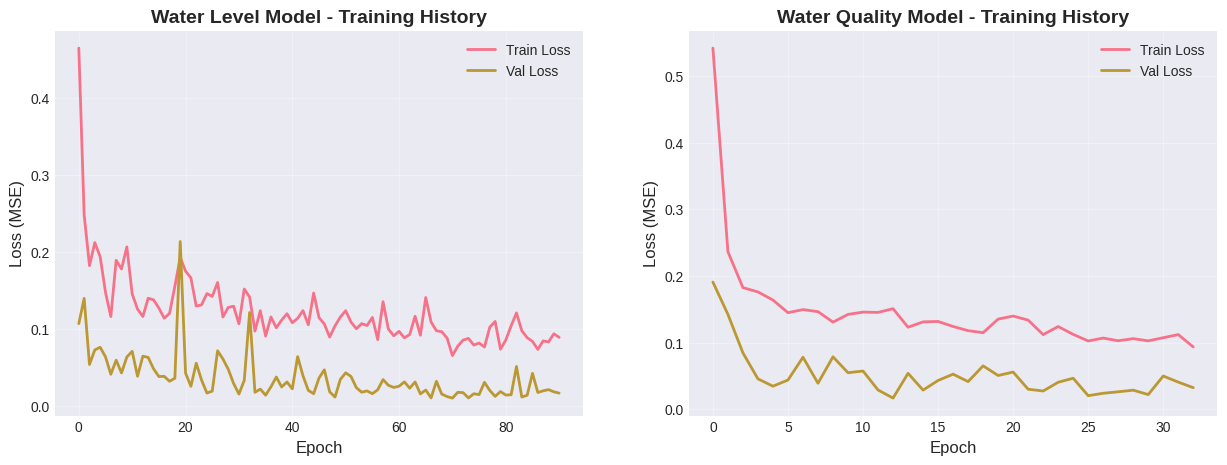

✓ Saved: training_curves.png

3. PLOTTING 2023 PREDICTIONS...


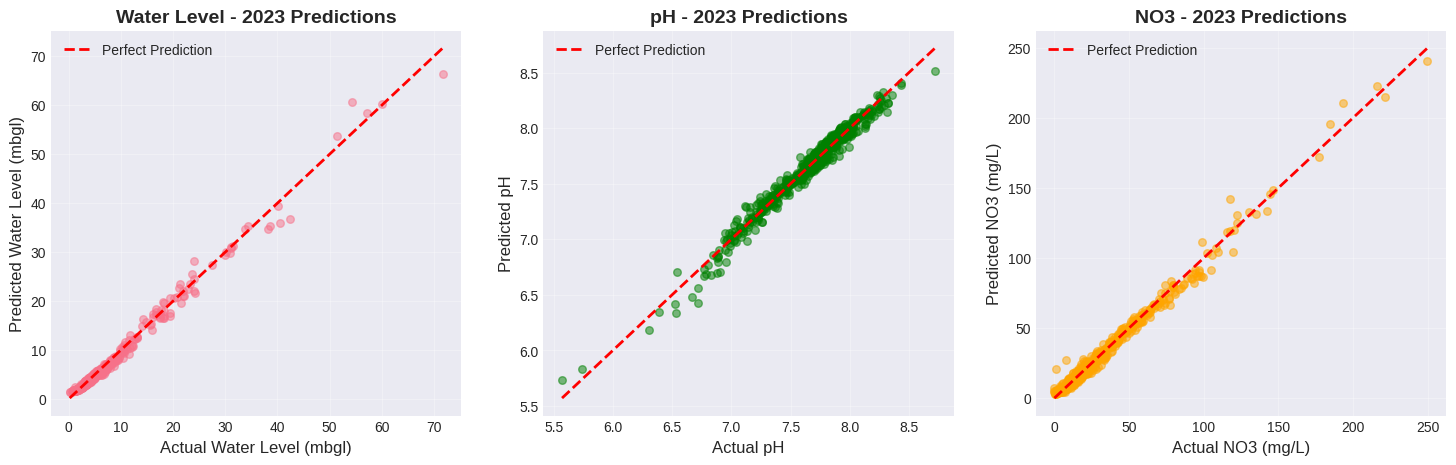

✓ Saved: 2023_predictions_scatter.png

4. PLOTTING RESIDUALS...


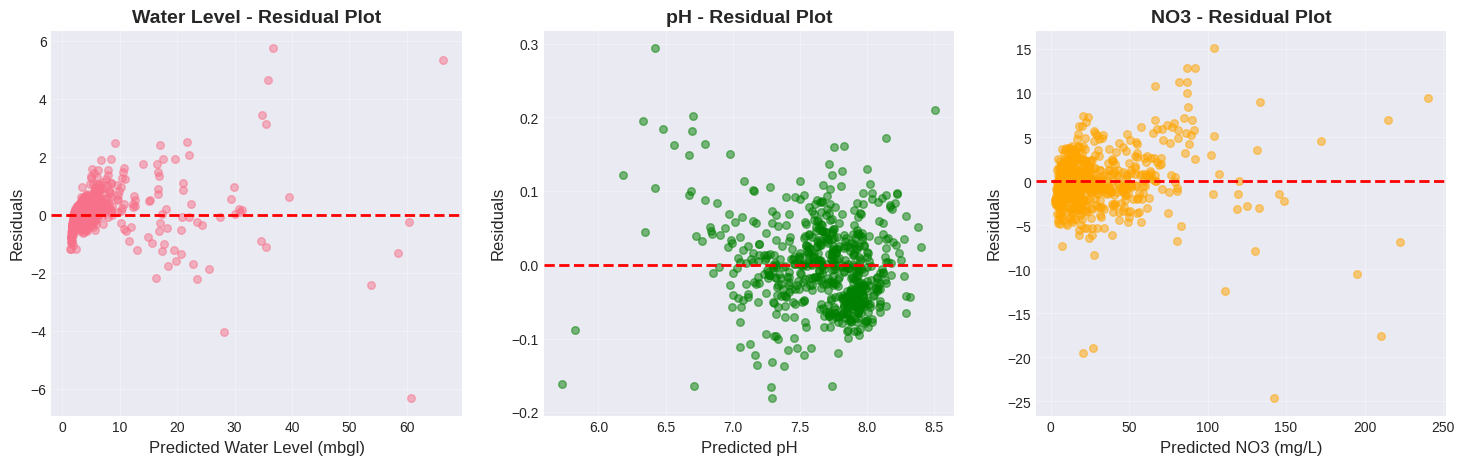

✓ Saved: residual_plots.png

5. PLOTTING TIME SERIES...


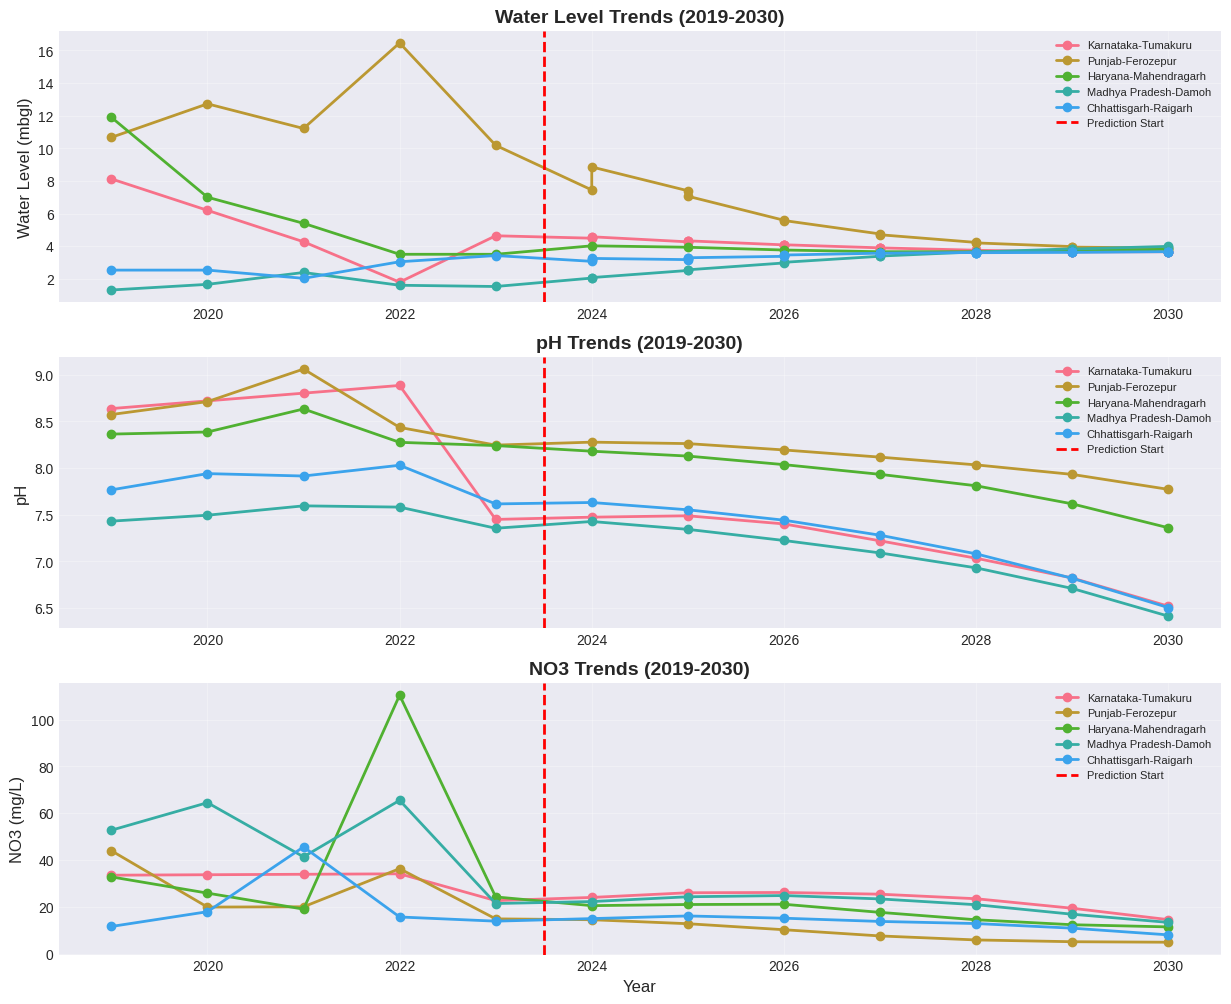

✓ Saved: time_series_predictions.png

6. PLOTTING YEARLY STATISTICS...


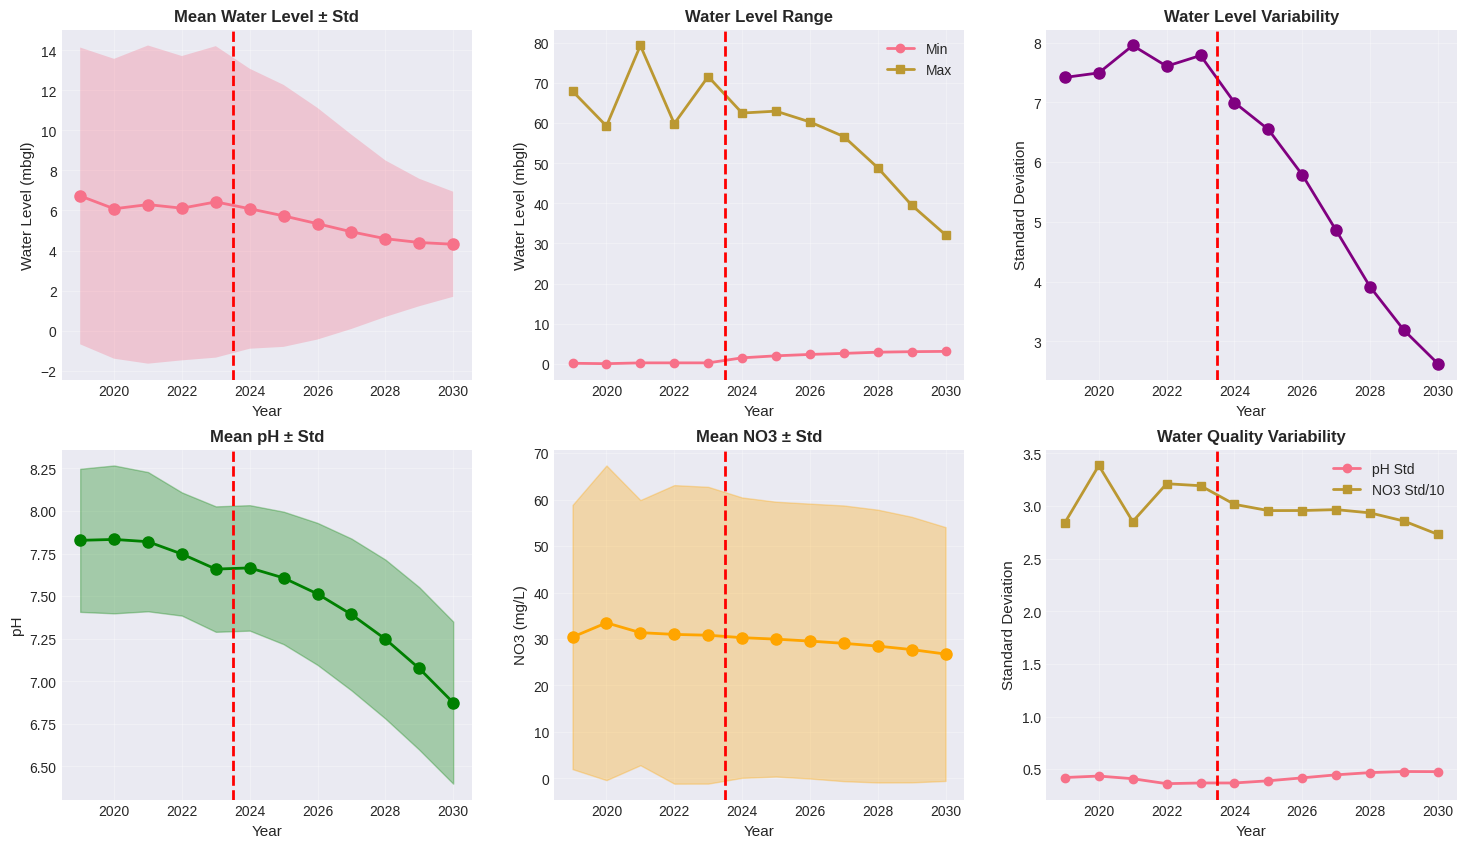

✓ Saved: yearly_statistics.png

7. PLOTTING DISTRIBUTIONS...


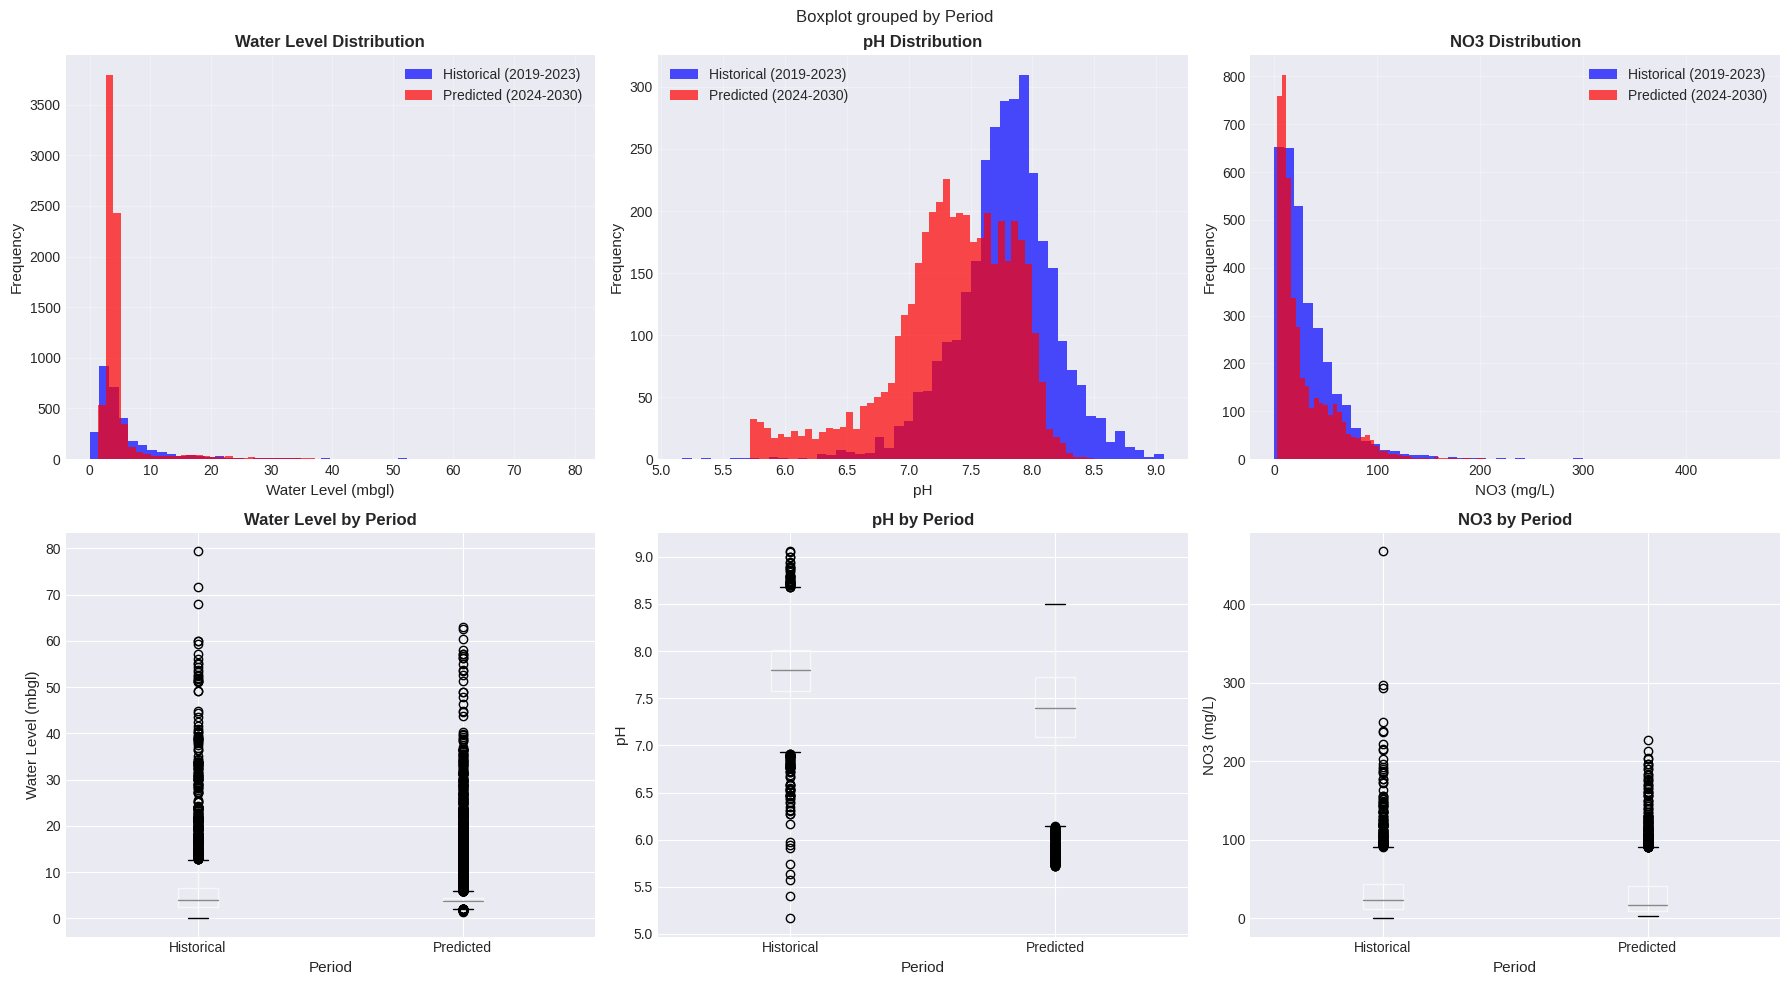

✓ Saved: distribution_plots.png

ALL PLOTS SAVED SUCCESSFULLY!

Generated files:
  1. training_curves.png
  2. 2023_predictions_scatter.png
  3. residual_plots.png
  4. time_series_predictions.png
  5. yearly_statistics.png
  6. distribution_plots.png


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("PLOTTING METRICS AND PREDICTIONS")
print("="*80)

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n1. LOADING DATA...")

# Load configs
wl_config = joblib.load('/kaggle/working/tft_water_level_config.pkl')
wq_config = joblib.load('/kaggle/working/tft_water_quality_config.pkl')

# Load predictions
wl_2023 = pd.read_csv('/kaggle/working/water_level_2023_predictions.csv')
wq_2023 = pd.read_csv('/kaggle/working/water_quality_2023_predictions.csv')

# Load complete predictions
wl_complete = pd.read_csv('/kaggle/working/water_level_predictions_2019_2030.csv')
wq_complete = pd.read_csv('/kaggle/working/water_quality_predictions_2019_2030.csv')

print("✓ Data loaded successfully")

# ============================================================================
# 2. TRAINING LOSS CURVES
# ============================================================================
print("\n2. PLOTTING TRAINING CURVES...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Water Level
axes[0].plot(wl_config['train_losses'], label='Train Loss', linewidth=2)
axes[0].plot(wl_config['val_losses'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Water Level Model - Training History', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Water Quality
axes[1].plot(wq_config['train_losses'], label='Train Loss', linewidth=2)
axes[1].plot(wq_config['val_losses'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss (MSE)', fontsize=12)
axes[1].set_title('Water Quality Model - Training History', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
plt.show()
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: training_curves.png")

# ============================================================================
# 3. 2023 PREDICTIONS - ACTUAL VS PREDICTED
# ============================================================================
print("\n3. PLOTTING 2023 PREDICTIONS...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Water Level
axes[0].scatter(wl_2023['WL_Actual'], wl_2023['WL_Predicted'], alpha=0.5, s=30)
axes[0].plot([wl_2023['WL_Actual'].min(), wl_2023['WL_Actual'].max()],
             [wl_2023['WL_Actual'].min(), wl_2023['WL_Actual'].max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Water Level (mbgl)', fontsize=12)
axes[0].set_ylabel('Predicted Water Level (mbgl)', fontsize=12)
axes[0].set_title('Water Level - 2023 Predictions', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# pH
axes[1].scatter(wq_2023['pH_Actual'], wq_2023['pH_Predicted'], alpha=0.5, s=30, color='green')
axes[1].plot([wq_2023['pH_Actual'].min(), wq_2023['pH_Actual'].max()],
             [wq_2023['pH_Actual'].min(), wq_2023['pH_Actual'].max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual pH', fontsize=12)
axes[1].set_ylabel('Predicted pH', fontsize=12)
axes[1].set_title('pH - 2023 Predictions', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# NO3
axes[2].scatter(wq_2023['NO3_Actual'], wq_2023['NO3_Predicted'], alpha=0.5, s=30, color='orange')
axes[2].plot([wq_2023['NO3_Actual'].min(), wq_2023['NO3_Actual'].max()],
             [wq_2023['NO3_Actual'].min(), wq_2023['NO3_Actual'].max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual NO3 (mg/L)', fontsize=12)
axes[2].set_ylabel('Predicted NO3 (mg/L)', fontsize=12)
axes[2].set_title('NO3 - 2023 Predictions', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
plt.show()
plt.tight_layout()
plt.savefig('/kaggle/working/2023_predictions_scatter.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: 2023_predictions_scatter.png")

# ============================================================================
# 4. RESIDUAL PLOTS FOR 2023
# ============================================================================
print("\n4. PLOTTING RESIDUALS...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Water Level Residuals
wl_residuals = wl_2023['WL_Actual'] - wl_2023['WL_Predicted']
axes[0].scatter(wl_2023['WL_Predicted'], wl_residuals, alpha=0.5, s=30)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Water Level (mbgl)', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Water Level - Residual Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# pH Residuals
pH_residuals = wq_2023['pH_Actual'] - wq_2023['pH_Predicted']
axes[1].scatter(wq_2023['pH_Predicted'], pH_residuals, alpha=0.5, s=30, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted pH', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('pH - Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# NO3 Residuals
NO3_residuals = wq_2023['NO3_Actual'] - wq_2023['NO3_Predicted']
axes[2].scatter(wq_2023['NO3_Predicted'], NO3_residuals, alpha=0.5, s=30, color='orange')
axes[2].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted NO3 (mg/L)', fontsize=12)
axes[2].set_ylabel('Residuals', fontsize=12)
axes[2].set_title('NO3 - Residual Plot', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.show()
plt.tight_layout()
plt.savefig('/kaggle/working/residual_plots.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: residual_plots.png")

# ============================================================================
# 5. TIME SERIES - SAMPLE LOCATIONS (2019-2030)
# ============================================================================
print("\n5. PLOTTING TIME SERIES...")

# Select 5 random sample locations
sample_locations = wl_complete.groupby(['STATE', 'DISTRICT']).size().sample(5, random_state=42).index

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for idx, (state, district) in enumerate(sample_locations):
    wl_sample = wl_complete[
        (wl_complete['STATE'] == state) & 
        (wl_complete['DISTRICT'] == district)
    ].sort_values('Year')
    
    wq_sample = wq_complete[
        (wq_complete['STATE'] == state) & 
        (wq_complete['DISTRICT'] == district)
    ].sort_values('Year')
    
    # Water Level
    axes[0].plot(wl_sample['Year'], wl_sample['WL(mbgl)'], 
                marker='o', label=f"{state[:15]}-{district[:15]}", linewidth=2)
    
    # pH
    axes[1].plot(wq_sample['Year'], wq_sample['pH'], 
                marker='o', label=f"{state[:15]}-{district[:15]}", linewidth=2)
    
    # NO3
    axes[2].plot(wq_sample['Year'], wq_sample['NO3'], 
                marker='o', label=f"{state[:15]}-{district[:15]}", linewidth=2)

# Add vertical line at 2023 (prediction starts)
for ax in axes:
    ax.axvline(x=2023.5, color='red', linestyle='--', linewidth=2, label='Prediction Start')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

axes[0].set_ylabel('Water Level (mbgl)', fontsize=12)
axes[0].set_title('Water Level Trends (2019-2030)', fontsize=14, fontweight='bold')

axes[1].set_ylabel('pH', fontsize=12)
axes[1].set_title('pH Trends (2019-2030)', fontsize=14, fontweight='bold')

axes[2].set_ylabel('NO3 (mg/L)', fontsize=12)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_title('NO3 Trends (2019-2030)', fontsize=14, fontweight='bold')
plt.show()
plt.tight_layout()
plt.savefig('/kaggle/working/time_series_predictions.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: time_series_predictions.png")

# ============================================================================
# 6. YEARLY STATISTICS (2019-2030)
# ============================================================================
print("\n6. PLOTTING YEARLY STATISTICS...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Water Level stats by year
wl_yearly_stats = wl_complete.groupby('Year')['WL(mbgl)'].agg(['mean', 'std', 'min', 'max'])

axes[0, 0].plot(wl_yearly_stats.index, wl_yearly_stats['mean'], marker='o', linewidth=2, markersize=8)
axes[0, 0].fill_between(wl_yearly_stats.index, 
                        wl_yearly_stats['mean'] - wl_yearly_stats['std'],
                        wl_yearly_stats['mean'] + wl_yearly_stats['std'],
                        alpha=0.3)
axes[0, 0].axvline(x=2023.5, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Year', fontsize=11)
axes[0, 0].set_ylabel('Water Level (mbgl)', fontsize=11)
axes[0, 0].set_title('Mean Water Level ± Std', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(wl_yearly_stats.index, wl_yearly_stats['min'], marker='o', label='Min', linewidth=2)
axes[0, 1].plot(wl_yearly_stats.index, wl_yearly_stats['max'], marker='s', label='Max', linewidth=2)
axes[0, 1].axvline(x=2023.5, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Year', fontsize=11)
axes[0, 1].set_ylabel('Water Level (mbgl)', fontsize=11)
axes[0, 1].set_title('Water Level Range', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(wl_yearly_stats.index, wl_yearly_stats['std'], marker='o', linewidth=2, color='purple', markersize=8)
axes[0, 2].axvline(x=2023.5, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel('Year', fontsize=11)
axes[0, 2].set_ylabel('Standard Deviation', fontsize=11)
axes[0, 2].set_title('Water Level Variability', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# pH stats by year
pH_yearly_stats = wq_complete.groupby('Year')['pH'].agg(['mean', 'std', 'min', 'max'])

axes[1, 0].plot(pH_yearly_stats.index, pH_yearly_stats['mean'], marker='o', linewidth=2, color='green', markersize=8)
axes[1, 0].fill_between(pH_yearly_stats.index, 
                        pH_yearly_stats['mean'] - pH_yearly_stats['std'],
                        pH_yearly_stats['mean'] + pH_yearly_stats['std'],
                        alpha=0.3, color='green')
axes[1, 0].axvline(x=2023.5, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Year', fontsize=11)
axes[1, 0].set_ylabel('pH', fontsize=11)
axes[1, 0].set_title('Mean pH ± Std', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# NO3 stats by year
NO3_yearly_stats = wq_complete.groupby('Year')['NO3'].agg(['mean', 'std', 'min', 'max'])

axes[1, 1].plot(NO3_yearly_stats.index, NO3_yearly_stats['mean'], marker='o', linewidth=2, color='orange', markersize=8)
axes[1, 1].fill_between(NO3_yearly_stats.index, 
                        NO3_yearly_stats['mean'] - NO3_yearly_stats['std'],
                        NO3_yearly_stats['mean'] + NO3_yearly_stats['std'],
                        alpha=0.3, color='orange')
axes[1, 1].axvline(x=2023.5, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Year', fontsize=11)
axes[1, 1].set_ylabel('NO3 (mg/L)', fontsize=11)
axes[1, 1].set_title('Mean NO3 ± Std', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# Combined variability
axes[1, 2].plot(pH_yearly_stats.index, pH_yearly_stats['std'], marker='o', label='pH Std', linewidth=2)
axes[1, 2].plot(NO3_yearly_stats.index, NO3_yearly_stats['std']/10, marker='s', label='NO3 Std/10', linewidth=2)
axes[1, 2].axvline(x=2023.5, color='red', linestyle='--', linewidth=2)
axes[1, 2].set_xlabel('Year', fontsize=11)
axes[1, 2].set_ylabel('Standard Deviation', fontsize=11)
axes[1, 2].set_title('Water Quality Variability', fontsize=12, fontweight='bold')
axes[1, 2].legend(fontsize=10)
axes[1, 2].grid(True, alpha=0.3)
plt.show()
plt.tight_layout()
plt.savefig('/kaggle/working/yearly_statistics.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: yearly_statistics.png")

# ============================================================================
# 7. DISTRIBUTION PLOTS
# ============================================================================
print("\n7. PLOTTING DISTRIBUTIONS...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Historical (2019-2023) vs Predicted (2024-2030)
wl_hist = wl_complete[wl_complete['Year'] <= 2023]['WL(mbgl)']
wl_pred = wl_complete[wl_complete['Year'] >= 2024]['WL(mbgl)']

axes[0, 0].hist(wl_hist, bins=50, alpha=0.7, label='Historical (2019-2023)', color='blue')
axes[0, 0].hist(wl_pred, bins=50, alpha=0.7, label='Predicted (2024-2030)', color='red')
axes[0, 0].set_xlabel('Water Level (mbgl)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Water Level Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

pH_hist = wq_complete[wq_complete['Year'] <= 2023]['pH']
pH_pred = wq_complete[wq_complete['Year'] >= 2024]['pH']

axes[0, 1].hist(pH_hist, bins=50, alpha=0.7, label='Historical (2019-2023)', color='blue')
axes[0, 1].hist(pH_pred, bins=50, alpha=0.7, label='Predicted (2024-2030)', color='red')
axes[0, 1].set_xlabel('pH', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('pH Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

NO3_hist = wq_complete[wq_complete['Year'] <= 2023]['NO3']
NO3_pred = wq_complete[wq_complete['Year'] >= 2024]['NO3']

axes[0, 2].hist(NO3_hist, bins=50, alpha=0.7, label='Historical (2019-2023)', color='blue')
axes[0, 2].hist(NO3_pred, bins=50, alpha=0.7, label='Predicted (2024-2030)', color='red')
axes[0, 2].set_xlabel('NO3 (mg/L)', fontsize=11)
axes[0, 2].set_ylabel('Frequency', fontsize=11)
axes[0, 2].set_title('NO3 Distribution', fontsize=12, fontweight='bold')
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# Box plots by year ranges
wl_complete['Period'] = wl_complete['Year'].apply(lambda x: 'Historical' if x <= 2023 else 'Predicted')
wq_complete['Period'] = wq_complete['Year'].apply(lambda x: 'Historical' if x <= 2023 else 'Predicted')

wl_complete.boxplot(column='WL(mbgl)', by='Period', ax=axes[1, 0])
axes[1, 0].set_title('Water Level by Period', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Period', fontsize=11)
axes[1, 0].set_ylabel('Water Level (mbgl)', fontsize=11)
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

wq_complete.boxplot(column='pH', by='Period', ax=axes[1, 1])
axes[1, 1].set_title('pH by Period', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Period', fontsize=11)
axes[1, 1].set_ylabel('pH', fontsize=11)
plt.sca(axes[1, 1])
plt.xticks(rotation=0)

wq_complete.boxplot(column='NO3', by='Period', ax=axes[1, 2])
axes[1, 2].set_title('NO3 by Period', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Period', fontsize=11)
axes[1, 2].set_ylabel('NO3 (mg/L)', fontsize=11)
plt.sca(axes[1, 2])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()
plt.savefig('/kaggle/working/distribution_plots.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: distribution_plots.png")

print("\n" + "="*80)
print("ALL PLOTS SAVED SUCCESSFULLY!")
print("="*80)
print("\nGenerated files:")
print("  1. training_curves.png")
print("  2. 2023_predictions_scatter.png")
print("  3. residual_plots.png")
print("  4. time_series_predictions.png")
print("  5. yearly_statistics.png")
print("  6. distribution_plots.png")

R² SCORE VISUALIZATION

1. LOADING DATA...
✓ Data loaded successfully

2. CALCULATING R² SCORES...

Water Level R²: 0.9902
pH R²: 0.9741
NO3 R²: 0.9884

3. PLOTTING R² SCORES...
✓ Saved: r2_scores.png


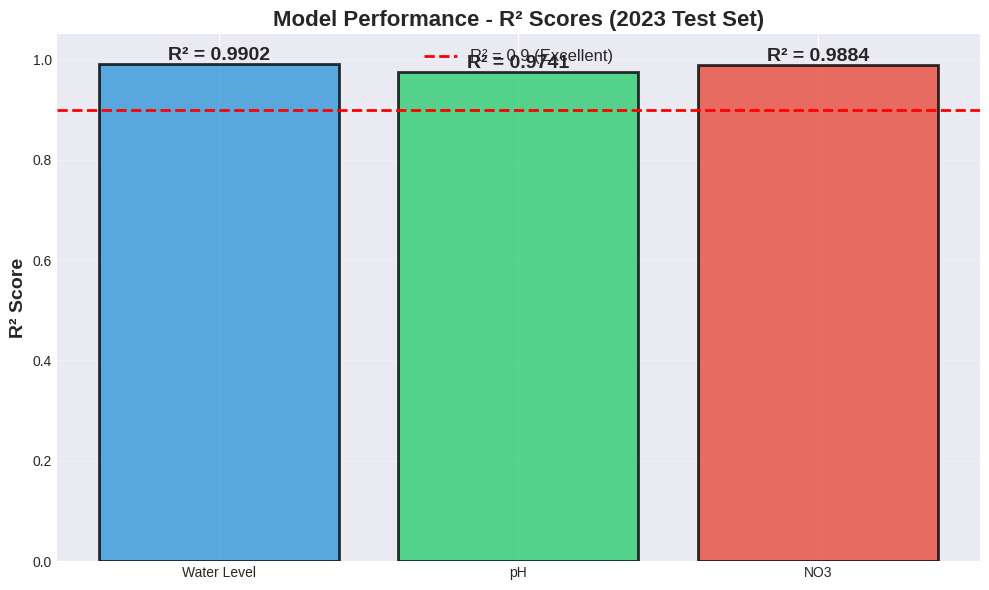


R² SCORE PLOT COMPLETE!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("R² SCORE VISUALIZATION")
print("="*80)

# ============================================================================
# 1. LOAD DATA
# ============================================================================
print("\n1. LOADING DATA...")

# Load 2023 predictions
wl_2023 = pd.read_csv('/kaggle/working/water_level_2023_predictions.csv')
wq_2023 = pd.read_csv('/kaggle/working/water_quality_2023_predictions.csv')

print("✓ Data loaded successfully")

# ============================================================================
# 2. CALCULATE R² SCORES
# ============================================================================
print("\n2. CALCULATING R² SCORES...")

# Water Level R²
wl_r2 = r2_score(wl_2023['WL_Actual'], wl_2023['WL_Predicted'])

# pH R²
pH_r2 = r2_score(wq_2023['pH_Actual'], wq_2023['pH_Predicted'])

# NO3 R²
NO3_r2 = r2_score(wq_2023['NO3_Actual'], wq_2023['NO3_Predicted'])

print(f"\nWater Level R²: {wl_r2:.4f}")
print(f"pH R²: {pH_r2:.4f}")
print(f"NO3 R²: {NO3_r2:.4f}")

# ============================================================================
# 3. PLOT R² SCORES
# ============================================================================
print("\n3. PLOTTING R² SCORES...")

fig, ax = plt.subplots(figsize=(10, 6))

models = ['Water Level', 'pH', 'NO3']
r2_scores = [wl_r2, pH_r2, NO3_r2]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = ax.bar(models, r2_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'R² = {score:.4f}',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add reference line at R² = 0.9
ax.axhline(y=0.9, color='red', linestyle='--', linewidth=2, label='R² = 0.9 (Excellent)')

ax.set_ylabel('R² Score', fontsize=14, fontweight='bold')
ax.set_title('Model Performance - R² Scores (2023 Test Set)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/kaggle/working/r2_scores.png', dpi=300, bbox_inches='tight')
print("✓ Saved: r2_scores.png")
plt.show()

print("\n" + "="*80)
print("R² SCORE PLOT COMPLETE!")
print("="*80)

In [27]:
!zip -r ground_water_updated.zip /kaggle/working/

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/tft_water_level.pth (deflated 8%)
  adding: kaggle/working/water_quality_complete_5years.csv (deflated 76%)
  adding: kaggle/working/training_curves.png (deflated 98%)
  adding: kaggle/working/r2_scores.png (deflated 25%)
  adding: kaggle/working/water_quality_predictions_2019_2030.csv (deflated 69%)
  adding: kaggle/working/water_quality_yearly.csv (deflated 73%)
  adding: kaggle/working/water_quality_predictions_2024_2030.csv (deflated 67%)
  adding: kaggle/working/tft_water_quality.pth (deflated 8%)
  adding: kaggle/working/water_quality_2023_predictions.csv (deflated 59%)
  adding: kaggle/working/water_level_2023_predictions.csv (deflated 61%)
  adding: kaggle/working/time_series_predictions.png (deflated 98%)
  adding: kaggle/working/distribution_plots.png (deflated 98%)
  adding: kaggle/working/water_level_yearly.csv (deflated 80%)
  adding: kaggle/working/tft_water_quality_config.pkl (deflated 48%)
  adding: kaggle/w

In [30]:
from IPython.display import FileLink
FileLink(r'ground_water_updated.zip')

/kaggle/working/ground_water_updated.zip